<a href="https://colab.research.google.com/github/pramitpal/SNN_2D5/blob/main/Copy_of_SNN_2D5_Grouping_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Clone Repo
from google.colab import drive
drive.mount('/content/drive')
!git clone https://github.com/pramitpal/SNN_2D5.git > /dev/null 2>&1
!cp -a /content/SNN_2D5/. /content/
!rm -rf /content/SNN_2D5
# !curl -L -o snn_mapper.py https://raw.githubusercontent.com/pramitpal/SNN_2D5/main/snn_mapper.py > /dev/null 2>&1

Mounted at /content/drive


In [ ]:
#@title Group calculation functions V2
def get_layer_lif_distances(chiplet_mapping_data, layer_num, lif_tiles_needed, lif_start_chiplet,
                            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile=40,
                            intra_cost=1, inter_cost=4):
    lif_end_chiplet = lif_start_chiplet + int(np.ceil(lif_tiles_needed / lif_tiles_per_chiplet)) - 1

    for group in chiplet_mapping_data:
        if layer_num in group['Layer_tile_distribution']:
            layer_tile_dist = group['Layer_tile_distribution'][layer_num]
            break
    else:
        layer_tile_dist = {}

    total_distance = 0
    total_compute_pes = 0

    for compute_chiplet, num_tiles in layer_tile_dist.items():
        num_pes = num_tiles * pe_per_tile
        if lif_start_chiplet <= compute_chiplet <= lif_end_chiplet:
            distance = intra_cost
        else:
            compute_row, compute_col = divmod(compute_chiplet, mesh_cols)
            min_manhattan = float('inf')
            for lif_chiplet in range(lif_start_chiplet, lif_end_chiplet + 1):
                lif_row, lif_col = divmod(lif_chiplet, mesh_cols)
                manhattan = abs(compute_row - lif_row) + abs(compute_col - lif_col)
                min_manhattan = min(min_manhattan, manhattan)
            distance = inter_cost * min_manhattan

        total_distance += num_pes * lif_tiles_needed * distance
        total_compute_pes += num_pes

    if total_compute_pes == 0:
        return 0

    return total_distance / total_compute_pes


def calculate_group_cost(chiplet_mapping_data, start_layer, end_layer, start_placing_in_chiplet,
                         lif_tiles_per_chiplet, MEMS, SRAM_KB_per_tile, operations,
                         mesh_rows, mesh_cols, pe_per_tile=40,
                         intra_cost=1, inter_cost=4, bus_width_bits=32,
                         use_congestion_penalty=False, use_mem_footprint_penalty=True):
    LIF_tiles_needed = int(np.ceil((np.array(MEMS[start_layer - 1:end_layer]) / (1024 * SRAM_KB_per_tile)).max()))

    total_cost = 0
    max_MEMS = max(MEMS) if max(MEMS) > 0 else 1

    for layer in range(start_layer, end_layer + 1):
        for group in chiplet_mapping_data:
            if layer in group['Layer_tile_distribution']:
                num_tiles_in_layer = sum(group['Layer_tile_distribution'][layer].values())
                break
        else:
            num_tiles_in_layer = 1  # fallback

        layer_ops = operations[layer - 1]
        total_pes = num_tiles_in_layer * pe_per_tile
        per_pe_traffic = layer_ops / total_pes if total_pes > 0 else 0

        layer_lif_distance = get_layer_lif_distances(
            chiplet_mapping_data, layer, LIF_tiles_needed, start_placing_in_chiplet,
            lif_tiles_per_chiplet, mesh_rows, mesh_cols, pe_per_tile, intra_cost, inter_cost)

        estimated_traffic_bits = per_pe_traffic * total_pes * (layer_lif_distance ** 2)
        traffic_cycles = estimated_traffic_bits / bus_width_bits

        congestion_penalty = 0
        if use_congestion_penalty:
            congestion_penalty = max(0, traffic_cycles - 1) ** 2

        mem_penalty = 0
        if use_mem_footprint_penalty:
            mem_penalty = MEMS[layer - 1] / max_MEMS

        layer_cost = traffic_cycles * (1 + congestion_penalty) * (1 + mem_penalty)
        total_cost += layer_cost

    return total_cost

In [ ]:
# @title Create Groupings + place LIF tiles functions V4 - Complete Rewrite
import numpy as np
import warnings
from itertools import combinations

#--------------------------------------------------------
# Helper: Convert chiplet ID -> (row, col) coordinates
# Supports serpentine numbering: even rows L->R, odd rows R->L
#--------------------------------------------------------
def get_row_col(chiplet_id, mesh_cols, mesh_rows):
    row, col_base = divmod(chiplet_id, mesh_cols)
    if row % 2 == 1:  # Odd row: reverse column mapping
        col = mesh_cols - 1 - col_base
    else:  # Even row: standard
        col = col_base
    return row, col

#--------------------------------------------------------
# Helper: Convert (row, col) -> chiplet ID
#--------------------------------------------------------
def get_chiplet_id(row, col, mesh_cols, mesh_rows):
    if not (0 <= row < mesh_rows and 0 <= col < mesh_cols):
        return None
    base = row * mesh_cols
    if row % 2 == 0:  # Even row: standard
        return base + col
    else:  # Odd row: reverse column
        return base + (mesh_cols - 1 - col)

#--------------------------------------------------------
# Get all chiplets within a given Manhattan distance
#--------------------------------------------------------
def get_mesh_neighbors(chiplet_id, mesh_rows, mesh_cols, max_distance=2):
    row, col = get_row_col(chiplet_id, mesh_cols, mesh_rows)
    neighbors = {d: [] for d in range(max_distance + 1)}
    total_chiplets = mesh_rows * mesh_cols
    for cid in range(total_chiplets):
        r, c = get_row_col(cid, mesh_cols, mesh_rows)
        dist = abs(r - row) + abs(c - col)
        if dist <= max_distance:
            neighbors[dist].append(cid)
    return {d: v for d, v in neighbors.items() if v}

#--------------------------------------------------------
# Identify possible contiguous mesh shapes
#--------------------------------------------------------
def find_mesh_regions(start, count, rows, cols):
    start_r, start_c = get_row_col(start, cols, rows)
    total = rows * cols

    def valid(chips):
        return all(0 <= x < total for x in chips) and len(set(chips)) == count

    shapes = []

    # Horizontal region
    horiz = []
    can_fit_h = True
    for i in range(count):
        cc = start_c + i
        if cc >= cols:
            can_fit_h = False
            break
        chip_id = get_chiplet_id(start_r, cc, cols, rows)
        if chip_id is None:
            can_fit_h = False
            break
        horiz.append(chip_id)
    if can_fit_h and valid(horiz):
        shapes.append(horiz)

    # Vertical region
    vert = []
    can_fit_v = True
    for i in range(count):
        rr = start_r + i
        if rr >= rows:
            can_fit_v = False
            break
        chip_id = get_chiplet_id(rr, start_c, cols, rows)
        if chip_id is None:
            can_fit_v = False
            break
        vert.append(chip_id)
    if can_fit_v and valid(vert):
        shapes.append(vert)

    # L-shapes for count=3
    if count == 3:
        l1_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None
        ]
        l1 = [x for x in l1_ids if x is not None]
        if len(l1) == 3 and valid(l1):
            shapes.append(l1)

        l2_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        l2 = [x for x in l2_ids if x is not None]
        if len(l2) == 3 and valid(l2):
            shapes.append(l2)

    # 2x2 square for count=4
    elif count == 4:
        sq_ids = [
            get_chiplet_id(start_r, start_c, cols, rows),
            get_chiplet_id(start_r, start_c + 1, cols, rows) if start_c + 1 < cols else None,
            get_chiplet_id(start_r + 1, start_c, cols, rows) if start_r + 1 < rows else None,
            get_chiplet_id(start_r + 1, start_c + 1, cols, rows) if start_r + 1 < rows and start_c + 1 < cols else None
        ]
        sq = [x for x in sq_ids if x is not None]
        if len(sq) == 4 and valid(sq):
            shapes.append(sq)

    return [s for s in shapes if valid(s)]

#--------------------------------------------------------
# Analyze crossbar usage for chiplets within layer range
#--------------------------------------------------------
def analyze_crossbar_usage(mapping, start_layer, end_layer, lif_alloc):
    chiplet_usage = {}
    for layer in range(start_layer, end_layer + 1):
        for cid, info in enumerate(mapping):
            if layer in info['Layers_filled']:
                idx = info['Layers_filled'].index(layer)
                used = info['Crossbars_filled_respective_layer'][idx]
                chiplet_usage.setdefault(cid, {})[layer] = used

    total_crossbars = {cid: sum(v.values()) for cid, v in chiplet_usage.items()}
    remaining = {cid: LIF_T - lif_alloc.get(cid, 0) for cid in range(len(mapping))}
    return chiplet_usage, total_crossbars, remaining

#--------------------------------------------------------
# Calculate LIF tiles needed for a layer range
#--------------------------------------------------------
def calculate_lif_tiles_needed(start_layer, end_layer, mems_array, sram_kb_per_tile):
    """Calculate max LIF tiles needed across layer range"""
    tiles_needed = int(np.ceil(
        (np.array(mems_array[start_layer - 1:end_layer]) / (1024 * sram_kb_per_tile)).max()
    ))
    return tiles_needed

#--------------------------------------------------------
# Distribute LIF tiles - STRICT VERSION
# Returns empty list if cannot allocate ALL tiles
#--------------------------------------------------------
def distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity_map, debug=False):
    """
    Strictly allocate ALL tiles or return empty list.
    """
    if debug:
        print(f"  [DEBUG] Attempting to allocate {tiles_needed} tiles")
        print(f"  [DEBUG] Available chiplets: {sorted(available_chiplets)}")
        print(f"  [DEBUG] Capacities: {[(c, capacity_map.get(c, 0)) for c in sorted(available_chiplets)]}")

    # Check if enough total capacity
    total_capacity = sum(capacity_map.get(c, 0) for c in available_chiplets)
    if total_capacity < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Total capacity {total_capacity} < needed {tiles_needed}")
        return []

    dist = []
    remaining = tiles_needed

    # Sort by descending capacity
    sorted_chiplets = sorted(available_chiplets, key=lambda c: capacity_map.get(c, 0), reverse=True)

    for cid in sorted_chiplets:
        if remaining <= 0:
            break
        avail = capacity_map.get(cid, 0)
        if avail <= 0:
            continue
        alloc = min(avail, remaining)
        dist.append((cid, alloc))
        remaining -= alloc
        if debug:
            print(f"  [DEBUG] Allocated {alloc} tiles to chiplet {cid}, remaining: {remaining}")

    # Verify complete allocation
    total_allocated = sum(t for _, t in dist)
    if total_allocated < tiles_needed:
        if debug:
            print(f"  [DEBUG] FAILED: Only allocated {total_allocated}/{tiles_needed} tiles")
        return []

    if debug:
        print(f"  [DEBUG] SUCCESS: Allocated all {tiles_needed} tiles across {len(dist)} chiplets")
    return dist

#--------------------------------------------------------
# Compute group cost
#--------------------------------------------------------
def calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage, rows, cols, ops, intra_cost=1, inter_cost=4):
    total_cost = 0
    for layer in range(start, end + 1):
        if layer - 1 >= len(ops):
            continue
        layer_ops = ops[layer - 1]
        chiplets = [(cid, cb.get(layer, 0)) for cid, cb in usage.items() if layer in cb]
        if not chiplets:
            continue
        total_cb = sum(cb for _, cb in chiplets)
        if total_cb == 0:
            continue

        for comp, cb in chiplets:
            if total_cb == 0 or cb == 0:
                continue
            weight = cb / total_cb
            r1, c1 = get_row_col(comp, cols, rows)
            min_dist = min(abs(r1 - r2) + abs(c1 - c2) for lif in region
                           for r2, c2 in [get_row_col(lif, cols, rows)])
            cost_val = intra_cost if min_dist == 0 else inter_cost * min_dist
            total_cost += layer_ops * cost_val * weight
    return total_cost

#--------------------------------------------------------
# Find optimal LIF placement - STRICT VERSION
#--------------------------------------------------------
def find_optimal_lif_placement_strict(mapping, start, end, tiles_needed, tiles_per_ch, rows, cols,
                                     available_chiplets, lif_alloc, inter_cost=4, debug=False):
    """
    Find optimal placement ensuring ALL tiles are allocated.
    Returns (distribution, cost) or ([], inf) if impossible.
    """
    if debug:
        print(f"\n[DEBUG] ===== Placement for layers {start}-{end} =====")
        print(f"[DEBUG] Tiles needed: {tiles_needed}")
        print(f"[DEBUG] Available chiplets: {len(available_chiplets)}")

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No available chiplets!")
        return [], float('inf')

    if tiles_needed <= 0:
        if debug:
            print(f"[DEBUG] No tiles needed, returning empty distribution")
        return [], 0

    # Calculate remaining capacity for each chiplet
    capacity = {c: LIF_T - lif_alloc.get(c, 0) for c in available_chiplets}

    # Filter out chiplets with no capacity
    capacity = {c: cap for c, cap in capacity.items() if cap > 0}
    available_chiplets = set(capacity.keys())

    if not available_chiplets:
        if debug:
            print(f"[DEBUG] No chiplets with remaining capacity!")
        return [], float('inf')

    total_capacity = sum(capacity.values())
    if debug:
        print(f"[DEBUG] Total available capacity: {total_capacity}")

    if total_capacity < tiles_needed:
        if debug:
            print(f"[DEBUG] Insufficient total capacity: {total_capacity} < {tiles_needed}")
        return [], float('inf')

    # Analyze crossbar usage
    usage, total_cb, _ = analyze_crossbar_usage(mapping, start, end, lif_alloc)

    # If no crossbar data, use simple allocation
    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar data, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Filter to only available chiplets with crossbar activity
    total_cb = {k: v for k, v in total_cb.items() if k in available_chiplets}

    if not total_cb:
        if debug:
            print(f"[DEBUG] No crossbar activity in available chiplets, using simple allocation")
        dist = distribute_lif_tiles_strict(available_chiplets, tiles_needed, capacity, debug)
        if not dist:
            return [], float('inf')
        return dist, 0

    # Find main chiplet with highest activity
    main_chip = max(total_cb, key=total_cb.get)
    neighbors = get_mesh_neighbors(main_chip, rows, cols)

    # Build priority list
    priority = [main_chip]
    others = sorted([c for c in total_cb if c != main_chip],
                    key=lambda c: total_cb[c], reverse=True)
    priority.extend(others)
    for dist in [1, 2]:
        priority.extend([c for c in neighbors.get(dist, []) if c in available_chiplets and c not in priority])

    # Estimate chiplets needed
    chiplets_needed = max(1, int(np.ceil(tiles_needed / tiles_per_ch)))

    # Find candidate regions
    candidate_regions = []
    avail_set = set(available_chiplets)

    for start_chip in priority:
        for size in range(chiplets_needed, min(chiplets_needed + 3, len(available_chiplets) + 1)):
            for region in find_mesh_regions(start_chip, size, rows, cols):
                if avail_set.issuperset(region):
                    region_capacity = sum(capacity.get(c, 0) for c in region)
                    if region_capacity >= tiles_needed:
                        if sorted(region) not in [sorted(r) for r in candidate_regions]:
                            candidate_regions.append(region)

    # Fallback: create region from highest capacity chiplets
    if not candidate_regions:
        if debug:
            print(f"[DEBUG] No valid contiguous regions, using capacity-based fallback")
        region = []
        accumulated = 0
        for cid in sorted(available_chiplets, key=lambda c: capacity.get(c, 0), reverse=True):
            region.append(cid)
            accumulated += capacity.get(cid, 0)
            if accumulated >= tiles_needed:
                break
        if accumulated >= tiles_needed:
            candidate_regions.append(region)

    if not candidate_regions:
        if debug:
            print(f"[DEBUG] Could not form any valid region")
        return [], float('inf')

    # Evaluate all candidate regions
    best_dist, best_cost = None, float('inf')

    for region in candidate_regions:
        # Try to allocate tiles in this region
        dist = distribute_lif_tiles_strict(region, tiles_needed, capacity, debug=False)
        if not dist:
            continue

        # Calculate cost
        cost = calculate_group_cost_crossbar_weighted(mapping, start, end, region, usage,
                                                     rows, cols, mapper.TOPS, inter_cost=inter_cost)

        if cost < best_cost:
            best_cost = cost
            best_dist = dist

    if best_dist is None:
        if debug:
            print(f"[DEBUG] No valid allocation found in any region")
        return [], float('inf')

    if debug:
        print(f"[DEBUG] Found allocation with cost {best_cost}: {best_dist}")

    return best_dist, best_cost

#--------------------------------------------------------
# Main grouping function - REWRITTEN WITH COVERAGE CHECK
#--------------------------------------------------------
def find_optimal_groupings_mesh_aware(total_layers, mesh_rows, mesh_cols,
                                     threshold_multiplier=2.0,
                                     placement_strategy='exclusive',
                                     allow_reuse=False,
                                     inter_cost=4,
                                    individual=True,
                                     debug=False):
    """
    Create layer groupings ensuring:
    1. Every group has complete LIF tile allocation
    2. All layers from 1 to total_layers are covered
    3. Groups with incomplete allocation are discarded
    4. If not all layers can be covered, return empty list
    """
    if debug:
        print(f"\n{'='*80}")
        print(f"Starting grouping: {total_layers} layers, {mesh_rows}x{mesh_cols} mesh")
        print(f"Strategy: {placement_strategy}, Threshold multiplier: {threshold_multiplier}")
        print(f"{'='*80}\n")

    # Validate mesh capacity
    total_chiplets = mesh_rows * mesh_cols
    required_chiplets = len(mapper.chiplet_data)

    if required_chiplets > total_chiplets:
        print(f"ERROR: Mapping requires {required_chiplets} chiplets, mesh has {total_chiplets}")
        return []

    all_groups = []
    available = set(range(total_chiplets))
    lif_alloc = {i: 0 for i in range(total_chiplets)}
    start_layer = 1
    failed_allocation = False

    while start_layer <= total_layers:
        if debug:
            print(f"\n[DEBUG] ----- Processing from layer {start_layer} -----")
            print(f"[DEBUG] Available chiplets: {len(available)}")
            total_remaining = sum(LIF_T - lif_alloc.get(c, 0) for c in available)
            print(f"[DEBUG] Total remaining LIF capacity: {total_remaining}")

        # Check if we have any capacity left
        if not available and placement_strategy == 'exclusive':
            if debug:
                print(f"[DEBUG] No available chiplets, cannot process layers {start_layer}-{total_layers}")
            print(f"ERROR: Cannot allocate layers {start_layer}-{total_layers} - no chiplets available")
            failed_allocation = True
            break

        # Calculate costs for incremental groupings
        costs = []
        tiles_list = []
        marginals = []

        for end_layer in range(start_layer, total_layers + 1):
            tiles_needed = calculate_lif_tiles_needed(start_layer, end_layer, mapper.MEMS, SRAM_KB_per_tile)
            tiles_list.append(tiles_needed)

            # Calculate cost using a dummy chiplet
            dummy = min(available) if available else 0
            cost = calculate_group_cost(mapper.chiplet_data, start_layer, end_layer, dummy, LIF_T,
                                       mapper.MEMS, SRAM_KB_per_tile, mapper.TOPS,
                                       mesh_rows, mesh_cols, intra_cost=1, inter_cost=inter_cost)
            costs.append(cost)

            if len(costs) > 1:
                marginals.append(costs[-1] - costs[-2])

        # Case 1: Only one layer left (base case)
        if start_layer == total_layers:
            if debug:
                print(f"[DEBUG] Final single layer {start_layer}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[0],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[0],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                # Update allocations
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate final layer {start_layer}")
                failed_allocation = True
            break

        # Case 2: Find break point using marginal costs
        valid_marginals = [m for m in marginals if np.isfinite(m)]

        if not valid_marginals:
            # All costs are infinite - try to allocate everything as one group
            if debug:
                print(f"[DEBUG] All marginals infinite, trying single group for {start_layer}-{total_layers}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[-1],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[-1],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate remaining layers {start_layer}-{total_layers}")
                failed_allocation = True
            break
        if individual:
          threshold =0
        else:
          threshold = np.mean(valid_marginals) + threshold_multiplier * np.std(valid_marginals)
        break_found = False

        if debug:
            print(f"[DEBUG] Marginal cost threshold: {threshold:.2f}")

        # Look for threshold break
        for i, mc in enumerate(marginals):
            if np.isinf(mc):
                continue

            if mc > threshold:
                br_layer = start_layer + i
                if debug:
                    print(f"[DEBUG] Break found at layer {br_layer} (marginal cost: {mc:.2f})")

                dist, opt_cost = find_optimal_lif_placement_strict(
                    mapper.chiplet_data, start_layer, br_layer, tiles_list[i],
                    LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

                if dist:
                    all_groups.append({
                        'start_layer': start_layer,
                        'end_layer': br_layer,
                        'lif_tiles': tiles_list[i],
                        'lif_distribution': dist,
                        'cost': opt_cost
                    })
                    for c, t in dist:
                        lif_alloc[c] += t
                        if placement_strategy == 'exclusive' and not allow_reuse:
                            if lif_alloc[c] >= LIF_T:
                                available.discard(c)
                    start_layer = br_layer + 1
                    break_found = True
                else:
                    print(f"ERROR: Failed to allocate group {start_layer}-{br_layer}")
                    failed_allocation = True
                    break_found = True
                break

        if failed_allocation:
            break

        # No break found - make one final group
        if not break_found:
            if debug:
                print(f"[DEBUG] No break found, creating final group {start_layer}-{total_layers}")

            dist, opt_cost = find_optimal_lif_placement_strict(
                mapper.chiplet_data, start_layer, total_layers, tiles_list[-1],
                LIF_T, mesh_rows, mesh_cols, available, lif_alloc, inter_cost=inter_cost, debug=debug)

            if dist:
                all_groups.append({
                    'start_layer': start_layer,
                    'end_layer': total_layers,
                    'lif_tiles': tiles_list[-1],
                    'lif_distribution': dist,
                    'cost': opt_cost
                })
                for c, t in dist:
                    lif_alloc[c] += t
                    if placement_strategy == 'exclusive' and not allow_reuse:
                        if lif_alloc[c] >= LIF_T:
                            available.discard(c)
            else:
                print(f"ERROR: Cannot allocate final group {start_layer}-{total_layers}")
                failed_allocation = True
            break

    # CRITICAL CHECK: Verify all layers are covered
    covered_layers = set()
    for g in all_groups:
        covered_layers.update(range(g['start_layer'], g['end_layer'] + 1))

    missing_layers = set(range(1, total_layers + 1)) - covered_layers

    if missing_layers or failed_allocation:
        print(f"\n{'='*80}")
        print(f"GROUPING FAILED - NOT ALL LAYERS COVERED")
        print(f"{'='*80}")
        if missing_layers:
            print(f"Missing layers: {sorted(missing_layers)}")
        print(f"Only covered layers 1-{max(covered_layers) if covered_layers else 0} out of {total_layers}")
        print(f"Discarding incomplete grouping and returning empty list.")
        print(f"{'='*80}\n")
        return []

    # Final validation
    if debug:
        print(f"\n{'='*80}")
        print(f"Grouping SUCCESS: {len(all_groups)} groups created")
        print(f"All {total_layers} layers covered")
        print(f"{'='*80}\n")

    # Validate each group
    for i, g in enumerate(all_groups):
        allocated = sum(t for _, t in g['lif_distribution'])
        if allocated < g['lif_tiles']:
            print(f"WARNING: Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - INCOMPLETE")
        elif debug:
            print(f"[DEBUG] Group {i} (layers {g['start_layer']}-{g['end_layer']}): "
                  f"allocated {allocated}/{g['lif_tiles']} tiles - OK")

    return all_groups

#--------------------------------------------------------
# Format output
#--------------------------------------------------------
def format_output(groups):
    return [[list(range(g['start_layer'], g['end_layer'] + 1)), g['lif_distribution']] for g in groups]

In [ ]:
#@title Visualize groupings + LIF placements as mesh function v2
def visualize_groups(all_groups, chiplet_mapping_data, mesh_rows, mesh_cols, LIF_T=16, invert_yaxis=True, max_lines=4, auto_display=False, figsize=(12,10), fig_fontsize=8, legend_fontsize=9):
    """
    Visualize layer groupings and LIF allocation in chiplet mesh format.
    Enhanced to prevent text spilling and duplicate displays.

    Args:
        all_groups (list): List of dicts with 'start_layer', 'end_layer', 'lif_distribution' (list of (chiplet, tiles)).
        chiplet_mapping_data (list): List of dicts, indexed by chiplet ID, each with 'Layers_filled' (list of ints).
        mesh_rows (int), mesh_cols (int): Mesh dimensions.
        LIF_T (int, optional): Total LIF tiles per chiplet. Defaults to 16.
        invert_yaxis (bool, optional): If True, place row 0 at top. Defaults to True.
        max_lines (int, optional): Max lines in annotations before truncating. Defaults to 4.
        auto_display (bool, optional): If True, call plt.show() (for scripts). In Jupyter, set False for inline auto-display. Defaults to False.
        figsize (tuple, optional): Figure size (width, height). Defaults to (12,10).
        fig_fontsize (int, optional): Base fontsize for chiplet internal texts (C0, layers, LIF info). Adaptive scaling applied relative to this base. Defaults to 8.
        legend_fontsize (int, optional): Fontsize for legend text. Defaults to 9.

    Returns:
        matplotlib.figure.Figure: The figure object (for saving, e.g., fig.savefig('mesh.png')).
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    # Close all existing figures to prevent duplicates
    plt.close('all')

    total_chiplets = mesh_rows * mesh_cols

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Colors for groups
    num_groups = len(all_groups)
    colors = plt.cm.tab10(np.linspace(0, 1, num_groups)) if num_groups > 0 else []

    # Get physical layers per chiplet (with safety)
    physical_layers = {}
    for chiplet_id in range(total_chiplets):
        if chiplet_id < len(chiplet_mapping_data):
            physical_layers[chiplet_id] = chiplet_mapping_data[chiplet_id].get('Layers_filled', [])
        else:
            physical_layers[chiplet_id] = []

    # Get LIF allocation per chiplet (aggregate across groups)
    chiplet_lif_by_group = {i: {} for i in range(total_chiplets)}
    for g_idx, group in enumerate(all_groups):
        for chiplet, tiles in group.get('lif_distribution', []):
            if 0 <= chiplet < total_chiplets:
                chiplet_lif_by_group[chiplet][g_idx] = float(tiles)

    # Draw mesh with serpentine chiplet ID mapping
    for row in range(mesh_rows):
        for col in range(mesh_cols):
            # Serpentine mapping: odd rows go right-to-left
            if row % 2 == 0:
                chiplet_id = row * mesh_cols + col
                display_col = col
            else:
                chiplet_id = row * mesh_cols + (mesh_cols - 1 - col)
                display_col = col

            # Determine color and edge
            groups_in_chiplet = list(chiplet_lif_by_group[chiplet_id].keys())
            has_layers = bool(physical_layers[chiplet_id])
            has_lif = bool(groups_in_chiplet)

            if len(groups_in_chiplet) > 1:
                color = 'orange'
                edge = 'red'
                lw = 3
            elif has_lif:
                color = colors[groups_in_chiplet[0]]
                edge = 'black'
                lw = 2
            elif has_layers:
                color = 'lightblue'
                edge = 'black'
                lw = 1.5
            else:
                color = 'lightgray'
                edge = 'black'
                lw = 1

            # Rectangle (slightly smaller for padding)
            rect_width, rect_height = 0.92, 0.92
            rect = plt.Rectangle((display_col + (1-rect_width)/2, row + (1-rect_height)/2),
                                rect_width, rect_height,
                                facecolor=color, edgecolor=edge, linewidth=lw, alpha=0.7)
            ax.add_patch(rect)

            # Build abbreviated text lines
            lines = [f"C{chiplet_id}"]

            # Abbreviated Physical layers
            layers = sorted(physical_layers[chiplet_id])
            if layers:
                if len(layers) <= 3:
                    layer_str = ','.join([f"L{l}" for l in layers])
                else:
                    num_layers = len(layers)
                    min_l, max_l = min(layers), max(layers)
                    layer_str = f"L{min_l}-{max_l}({num_layers})"
                lines.append(f"{layer_str}")

            # Summarized LIF allocation
            total_lif = 0.0
            if chiplet_lif_by_group[chiplet_id]:
                group_details = []
                for g_idx, tiles in sorted(chiplet_lif_by_group[chiplet_id].items()):
                    total_lif += tiles
                    group_details.append(f"G{g_idx+1}:{tiles:.1f}t")

                if len(group_details) <= 2:
                    for detail in group_details:
                        lines.append(detail)
                else:
                    lines.append(f"{group_details[0]}")
                    lines.append(f"+{len(group_details)-1} more")

                # Total LIF if multiple groups
                if len(group_details) > 1:
                    lines.append(f"Σ:{total_lif:.1f}t")

            # Truncate to max_lines
            if len(lines) > max_lines:
                lines = lines[:max_lines-1] + ["..."]

            # Calculate adaptive fontsize based on content, relative to fig_fontsize base
            num_lines = len(lines)
            max_chars = max(len(line) for line in lines)

            base = fig_fontsize
            if num_lines <= 2 and max_chars <= 8:
                fontsize = base + 2
            elif num_lines <= 3 and max_chars <= 12:
                fontsize = base + 1
            elif num_lines <= 4 and max_chars <= 15:
                fontsize = base
            else:
                fontsize = max(4, base - 1)

            # Add text with constrained bbox
            text_str = '\n'.join(lines)
            ax.text(display_col + 0.5, row + 0.5, text_str,
                    ha='center', va='center', fontsize=fontsize, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.15", facecolor='white', alpha=0.85,
                              edgecolor='none'),
                    wrap=True, clip_on=True)

    # Axes setup (fixed font sizes for external elements)
    ax.set_xlim(0, mesh_cols)
    ax.set_ylim(0, mesh_rows)
    ax.set_aspect('equal')
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('Row', fontsize=12)
    ax.set_title('Chiplet Mesh: Layer Groups & LIF Allocation', fontsize=14, fontweight='bold')
    ax.set_xticks(range(mesh_cols))
    ax.set_yticks(range(mesh_rows))
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, color='white', linewidth=0.5, alpha=0.3)
    if invert_yaxis:
        ax.invert_yaxis()

    # Legend - show ALL groups including those without LIF
    legend_elements = []
    for i, group in enumerate(all_groups):
        dist = group.get('lif_distribution', [])
        start_layer = group['start_layer']
        end_layer = group['end_layer']

        if dist:
            # Groups with LIF allocation
            label = f"G{i+1}: Layers {start_layer}-{end_layer}"
            legend_elements.append(
                mpatches.Patch(facecolor=colors[i] if num_groups > 0 else 'gray',
                              edgecolor='black', alpha=0.7, label=label)
            )
        else:
            # Groups without LIF allocation (like your 35-112 case)
            label = f"G{i+1}: Layers {start_layer}-{end_layer} (No LIF)"
            legend_elements.append(
                mpatches.Patch(facecolor='white', edgecolor='gray',
                              linestyle='--', linewidth=1.5, alpha=0.6, label=label)
            )

    # Add status indicators
    if any(len(chiplet_lif_by_group[i]) > 1 for i in range(total_chiplets)):
        legend_elements.append(
            mpatches.Patch(facecolor='orange', edgecolor='red', linewidth=3, alpha=0.7,
                          label="Shared by multiple groups")
        )
    legend_elements.append(
        mpatches.Patch(facecolor='lightblue', edgecolor='black', alpha=0.7,
                      label="Compute-only (no LIF)")
    )

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=legend_fontsize)

    plt.tight_layout()

    if auto_display:
        plt.show()

    return fig

In [ ]:
#@title add_LIF tiles to chiplet mapping function
import copy
def add_lif_tiles(chiplet_mapping, groupings, NT, LIF_T, NPE, mesh_rows, mesh_cols):
    chiplets = copy.deepcopy(chiplet_mapping)
    MAX_CHIPLETS = mesh_rows * mesh_cols
    need = max([cid for g in groupings for cid, _ in g['lif_distribution']], default=-1) + 1
    assert need <= MAX_CHIPLETS, "lif_distribution references a chiplet beyond mesh size."

    while len(chiplets) < need:
        chiplets.append({
            'Layers_filled': [],
            'Crossbars_filled_respective_layer': [],
            'Crossbars_remaining_respective_layer': [],
            'Layer_tile_distribution': {},
            'Empty_crossbars': (NT - LIF_T) * NPE
        })

    next_tile = {}
    lif_id = 0
    for g in groupings:
        for chiplet_id, num_tiles in g['lif_distribution']:
            ltd = chiplets[chiplet_id].setdefault('Layer_tile_distribution', {})
            start = next_tile.get(chiplet_id, NT - LIF_T)
            ltd[f"LIF{lif_id}"] = {i: NPE for i in range(start, start + num_tiles)}
            next_tile[chiplet_id] = start + num_tiles
        lif_id += 1

    return chiplets

In [ ]:
#@title get layer input + output function
import math
import numpy as np

def get_layer_traffic(
    layer_id,
    chiplet_data,
    groupings,
    weights,
    tunable_params,
    xbars,
    X, Vmem_res, Timestep, NoC_buswidth,
    lif_tiles_per_layer,
    SRAM_KB_per_tile,
    acc_enabled=False
):
    """
    Returns a dict:
      {
        "output": [ [src, dst, packets, src_chiplet, dst_chiplet], ... ],
        "input" : [ [src, dst, packets, src_chiplet, dst_chiplet], ... ]
      }

    Output (unchanged):
      - Tile -> (ACC{g})? -> LIF tiles (capacity-aware, fill-first).
      - Single-shot in bits; scaled to packets at end.

    Input (broadcast update):
      - Recompute prev layer's actual LIF writes (in bits).
      - For each destination tile in this layer, pull a FULL prev_OFM in bits:
          tile_quota_bits = IFM_H_prev * IFM_W_prev * OC_prev * Vmem_res
      - Split that quota across prev LIF tiles PROPORTIONALLY to how layer (L-1) wrote them.
      - Do NOT consume LIF supply across tiles (broadcast read).
      - Scale to packets at the end.
    """

    # --------------------------- helpers (bits, no scaling) ---------------------------
    def _group_index_for(layer):
        for gi, g in enumerate(groupings):
            if g['start_layer'] <= layer <= g['end_layer']:
                return gi
        return None

    def _lif_tiles_for_group(gidx):
        name = f"LIF{gidx}"
        tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            lif_map = chiplet.get('Layer_tile_distribution', {}).get(name, {})
            for t_id in sorted(lif_map.keys()):
                tiles.append((c_id, t_id))
        return name, tiles

    def _traffic_bits_params(li):
        IFM_H, IFM_W = weights[li][0], weights[li][1]
        OC        = weights[li][5]
        total_ofm = IFM_H * IFM_W * OC
        total_xb  = int(xbars[li])
        denom     = (X * max(1, OC))
        per_tp    = max(1, tunable_params[li])
        cb_per_col= max(1, int(math.ceil(per_tp / denom)))
        num_cols  = max(1, int(math.ceil(max(1, total_xb) / cb_per_col)))
        ofm_per_c = total_ofm / 1
        base_bits = ofm_per_c * max(1, Vmem_res)  # single-shot bits per tile under your current model
        return base_bits

    # Compute OUTPUT edges in bits for a given layer and aggregate per-LIF writes (bits)
    def _compute_output_bits_for_layer(layer, acc_mode):
        gidx = _group_index_for(layer)
        if gidx is None:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        lif_name, lif_all = _lif_tiles_for_group(gidx)
        if not lif_all:
            return [[f"T?_{layer}", "LIF_NOT_FOUND", 0, "NOT_FOUND", "NOT_FOUND"]], {}

        li = layer - 1
        need = max(1, min(int(lif_tiles_per_layer[li]), len(lif_all)))
        lif_used = lif_all[:need]
        lif_cap_bits = int(SRAM_KB_per_tile) * 1024 * 8

        base_bits = _traffic_bits_params(li)
        results_bits = []
        lif_written_bits = {(c,t): 0.0 for (c,t) in lif_used}

        if acc_mode:
            # single ACC per group on first LIF chiplet
            acc_name = f"ACC{gidx}"
            acc_chip = lif_used[0][0]
            total_into_acc = 0.0

            # Tiles -> ACC
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    src = f"T{tile_id}"
                    results_bits.append([src, acc_name, base_bits, c_id, acc_chip])
                    total_into_acc += base_bits

            # ACC -> LIF (fill-first)
            remaining = total_into_acc
            for (dst_c, lif_tid) in lif_used:
                if remaining <= 0:
                    break
                space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                if space <= 0:
                    continue
                assign = min(remaining, space)
                lif_written_bits[(dst_c, lif_tid)] += assign
                results_bits.append([acc_name, f"{lif_name}_{lif_tid}", assign, acc_chip, dst_c])
                remaining -= assign
            return results_bits, lif_written_bits

        else:
            # direct Tile -> LIF (fill-first per tile)
            for c_id, chiplet in enumerate(chiplet_data):
                ltd = chiplet.get('Layer_tile_distribution', {})
                if layer not in ltd:
                    continue
                for tile_id, _cb in ltd[layer].items():
                    remaining = base_bits
                    for (dst_c, lif_tid) in lif_used:
                        if remaining <= 0:
                            break
                        space = lif_cap_bits - lif_written_bits[(dst_c, lif_tid)]
                        if space <= 0:
                            continue
                        assign = min(remaining, space)
                        lif_written_bits[(dst_c, lif_tid)] += assign
                        results_bits.append([f"T{tile_id}", f"{lif_name}_{lif_tid}", assign, c_id, dst_c])
                        remaining -= assign
            return results_bits, lif_written_bits

    # ----------------------------------------------------------------------
    # PART 1: OUTPUT for this layer (bits)
    # ----------------------------------------------------------------------
    results_output_bits, _lif_written_cur = _compute_output_bits_for_layer(layer_id, acc_enabled)

    # ----------------------------------------------------------------------
    # PART 2: INPUT for this layer (BROADCAST from prev LIF tiles)
    # ----------------------------------------------------------------------
    results_input_bits = []
    if layer_id > 1:
        prev_layer = layer_id - 1

        # Previous layer's actual LIF writes (in bits)
        _prev_out_bits, prev_lif_written_bits = _compute_output_bits_for_layer(prev_layer, acc_enabled)

        # Build deterministic list of prev LIF tiles that actually have data
        supply_list = [((c,t), bits) for (c,t), bits in prev_lif_written_bits.items() if bits > 0]
        supply_list.sort(key=lambda x: (x[0][0], x[0][1]))  # by (chiplet, tile_id)

        total_prev_written_bits = sum(bits for _, bits in supply_list)

        # Per-tile QUOTA in bits: full prev OFM per tile
        pj = prev_layer - 1
        prev_IFM_H, prev_IFM_W, prev_OC = weights[pj][0], weights[pj][1], weights[pj][5]
        tile_quota_bits = float(prev_IFM_H) * float(prev_IFM_W) * float(prev_OC) * float(max(1, Vmem_res))

        # Destination tiles of current layer (deterministic order)
        dest_tiles = []
        for c_id, chiplet in enumerate(chiplet_data):
            ltd = chiplet.get('Layer_tile_distribution', {})
            if layer_id in ltd:
                for t_id in sorted(ltd[layer_id].keys()):
                    dest_tiles.append((c_id, t_id))

        # If there is no prev data or no destinations, skip
        if total_prev_written_bits > 0 and dest_tiles:
            # Precompute proportional weights of prev LIF tiles
            # w_i = bits_i / total_prev_written_bits
            weights_list = []
            for (c,t), bits in supply_list:
                w = bits / float(total_prev_written_bits)
                weights_list.append(((c,t), w))

            # For each destination tile, allocate the SAME quota following those proportions
            prev_gidx = _group_index_for(prev_layer)
            for (dst_c, dst_t) in dest_tiles:
                # First pass: floor allocation
                alloc = []
                sum_floor = 0.0
                for (src_ct, w) in weights_list:
                    amt = w * tile_quota_bits
                    amt_floor = math.floor(amt)
                    alloc.append([src_ct, amt_floor])
                    sum_floor += amt_floor
                # Residual to reach exactly tile_quota_bits
                residual = int(max(0, math.ceil(tile_quota_bits - sum_floor)))
                # Distribute the residual (largest fractional parts first)
                fracs = [ (i, (weights_list[i][1] * tile_quota_bits) - alloc[i][1]) for i in range(len(alloc)) ]
                fracs.sort(key=lambda x: x[1], reverse=True)
                i = 0
                while residual > 0 and i < len(fracs):
                    idx = fracs[i][0]
                    alloc[idx][1] += 1
                    residual -= 1
                    i += 1

                # Emit per-LIF edges for this destination tile
                for (src_ct, amt_bits) in alloc:
                    if amt_bits <= 0:
                        continue
                    src_c, src_t = src_ct
                    results_input_bits.append([f"LIF{prev_gidx}_{src_t}", f"T{dst_t}", amt_bits, src_c, dst_c])

    # ----------------------------------------------------------------------
    # SCALE BOTH DIRECTIONS: packets = ceil(bits * Timestep / NoC_buswidth)
    # ----------------------------------------------------------------------
    def _scale_to_packets(edges_bits):
        ts = max(1, int(Timestep))
        bw = max(1, int(NoC_buswidth))
        out = []
        for s, d, bits, sc, dc in edges_bits:
            packets = int(math.ceil((bits * ts) / bw))
            out.append([s, d, packets, sc, dc])
        return out

    return {
        "output": _scale_to_packets(results_output_bits),
        "input":  _scale_to_packets(results_input_bits)
    }

In [ ]:
#@title create NOI traffic matrix function
import numpy as np
import pandas as pd

def create_system_matrix_from_edges(all_edge_lists, count_diagonal=False,mesh_rows=4, mesh_cols=4,num_chiplets=None):
    """
    all_edge_lists: list of lists of edges; each edge is [src, dst, amount, src_chiplet, dst_chiplet]
                    (exactly like your traffic_dict["output"] / ["input"] entries)
    mesh_rows:      optional; number of rows in the mesh topology (if provided with mesh_cols, sets num_chiplets = mesh_rows * mesh_cols)
    mesh_cols:      optional; number of columns in the mesh topology
    num_chiplets:   optional; if None and mesh_rows/mesh_cols not both provided, we'll infer as max(seen chiplet id)+1
    count_diagonal: include intra-chiplet traffic (sc == dc) if True
    """
    # Determine chiplet count
    if mesh_rows is not None and mesh_cols is not None:
        num_chiplets = int(mesh_rows) * int(mesh_cols)
    elif num_chiplets is None:
        max_id = 0
        for sub in (all_edge_lists or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1
    else:
        num_chiplets = int(num_chiplets)

    N = max(1, num_chiplets)
    M = np.zeros((N, N), dtype=int)

    for sub in (all_edge_lists or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            _, _, traffic, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue
            if sc < 0 or sc >= N or dc < 0 or dc >= N:
                continue  # Skip invalid indices
            if count_diagonal or sc != dc:
                M[sc, dc] += int(traffic)

    # Generate names based on mesh if provided, else default
    if mesh_rows is not None and mesh_cols is not None:
        names = [f"R{r}C{c}" for r in range(int(mesh_rows)) for c in range(int(mesh_cols))]
    else:
        names = [f"C{i}" for i in range(N)]

    return M, pd.DataFrame(M, index=names, columns=names)

In [ ]:
#@title create NOC traffic matrix function
import numpy as np
import pandas as pd
import re

def create_tile_matrix_for_chiplet(
    results_list,
    target_chiplet: int,
    NT: int,
    include_chiplets: bool = False,
    num_chiplets: int = None
):
    """
    Build a matrix for one chiplet:
      - Rows/cols include tiles T0..T(NT-1)
      - ACC nodes are excluded
      - LIF nodes on the target chiplet are mapped to their tile id: 'LIFg_k' -> 'Tk'
      - Nodes on other chiplets collapse to 'C<id>' if include_chiplets=True

    Parameters
    ----------
    results_list : list[list[list]]
        Collection of edge lists. Each edge: [src, dst, amount, src_chiplet, dst_chiplet]
    target_chiplet : int
        Chiplet for which we are building the matrix.
    NT : int
        Number of tiles on a chiplet (max tile id count). We label T0..T(NT-1).
    include_chiplets : bool
        If True, include other chiplets as C<i> aggregate nodes (excluding target).
    num_chiplets : int or None
        If provided, used to enumerate other chiplets. If None, inferred from edges.

    Returns
    -------
    matrix : np.ndarray (int)
    df : pd.DataFrame
    """

    # infer num_chiplets if not provided
    if num_chiplets is None:
        max_id = target_chiplet
        for sub in (results_list or []):
            if not sub:
                continue
            for e in sub:
                if len(e) >= 5 and isinstance(e[3], int) and isinstance(e[4], int):
                    max_id = max(max_id, e[3], e[4])
        num_chiplets = max_id + 1

    # Labels: tiles on target chiplet
    tile_labels = [f"T{i}" for i in range(NT)]

    # Other chiplets (aggregate)
    other_chiplet_labels = [f"C{i}" for i in range(num_chiplets) if i != target_chiplet] if include_chiplets else []

    all_labels = tile_labels + other_chiplet_labels
    idx = {l: i for i, l in enumerate(all_labels)}
    M = np.zeros((len(all_labels), len(all_labels)), dtype=int)

    lif_pat = re.compile(r"^LIF\d+_(\d+)$")
    t_pat   = re.compile(r"^T(\d+)$")

    def map_node(node, chip_id):
        """Map a node+chiplet to a label in all_labels or None (to drop)."""
        # ACC nodes are excluded
        if isinstance(node, str) and node.startswith("ACC"):
            return None

        # Numeric node means it’s a tile id
        if isinstance(node, int):
            if chip_id == target_chiplet:
                # keep as T<id> if within NT, else drop (outside tile range)
                return f"T{node}" if 0 <= node < NT else None
            else:
                return f"C{chip_id}" if include_chiplets else None

        if isinstance(node, str):
            # Tiles as strings: "T<id>"
            m = t_pat.match(node)
            if m:
                tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    return f"T{tile_id}" if 0 <= tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # LIF nodes: "LIFg_<tileid>" → map to T<tileid> on *target* chiplet
            m = lif_pat.match(node)
            if m:
                lif_tile_id = int(m.group(1))
                if chip_id == target_chiplet:
                    # treat the LIF tile as the physical tile Tk
                    return f"T{lif_tile_id}" if 0 <= lif_tile_id < NT else None
                else:
                    return f"C{chip_id}" if include_chiplets else None

            # Unknown strings: drop
            return None

        # Unknown type: drop
        return None

    for sub in (results_list or []):
        if not sub:
            continue
        for e in sub:
            if len(e) < 5:
                continue
            src, dst, amt, sc, dc = e[:5]
            if not (isinstance(sc, int) and isinstance(dc, int)):
                continue

            s_lbl = map_node(src, sc)
            d_lbl = map_node(dst, dc)
            if s_lbl is None or d_lbl is None:
                continue
            if s_lbl not in idx or d_lbl not in idx:
                continue

            M[idx[s_lbl], idx[d_lbl]] += int(amt)

    return M, pd.DataFrame(M, index=all_labels, columns=all_labels)

In [ ]:
#@title Calculate traffic for given grouping function
def calculate_traffic(grouping, chip_cfg, mesh_rows=4,mesh_cols=4,NoI_buswidth=128, NoC_buswidth=16,Timestep=5,):
    """Calculate inter and intra-chiplet traffic for a given grouping."""
    # Build all traffic for this grouping
    all_traffic = []
    for layer_id in range(1, len(mapper.weights) + 1):
        traffic_dict = get_layer_traffic(
            layer_id=layer_id, chiplet_data=chip_cfg, groupings=grouping,
            weights=mapper.weights, tunable_params=mapper.tunable_params,
            xbars=mapper.xbars, X=mapper.X, Vmem_res=mapper.Vmem_res,
            Timestep=Timestep, NoC_buswidth=1,
            lif_tiles_per_layer=np.ceil(np.array(mapper.MEMS)/(SRAM_KB_per_tile*1024)).astype(int),
            SRAM_KB_per_tile=SRAM_KB_per_tile, acc_enabled=False
        )
        all_traffic.extend([traffic_dict["output"], traffic_dict["input"]])
    # print(all_traffic)
    # Inter-chiplet traffic - divide by NoI_buswidth and ceil
    _, M_sys_df = create_system_matrix_from_edges(all_traffic, mesh_rows=mesh_rows, mesh_cols=mesh_cols,count_diagonal=True)
    M_sys_df = np.ceil(M_sys_df / NoI_buswidth).astype(int)
    total_inter = M_sys_df.values.sum() - np.diag(M_sys_df.values).sum()

    # Intra-chiplet traffic - divide by NoC_buswidth and ceil
    chiplet_dfs = []  # List to collect per-chiplet matrices
    total_intra = 0
    for c in range(len(chip_cfg)):
        M_chip_df = np.ceil(create_tile_matrix_for_chiplet(all_traffic, c, NT, include_chiplets=False)[1] / NoC_buswidth).astype(int)
        # display(M_chip_df)
        chiplet_dfs.append(M_chip_df)  # Store the matrix
        total_intra += M_chip_df.values.sum() - np.diag(M_chip_df.values).sum()

    return int(total_inter), int(total_intra), M_sys_df, chiplet_dfs

In [ ]:
#@title Enhanced Pareto Front function (Optional Plot + Robust Error Handling)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, Optional, Tuple, Union

def pareto_plot(df: pd.DataFrame, x_col: str = "LIF_MEM(KB)", y_col: str = "LatencyScore(ms)",
                method: str = "equal_weightage", w_x: float = 0.5, w_y: float = 0.5,
                annotate_all: bool = False, max_annotate: int = 20,
                yaxis: Optional[Tuple[float, float]] = None, xaxis: Optional[Tuple[float, float]] = None,
                autoscale: bool = True, filter_col: Optional[str] = "Num Groups",
                filter_val: Union[int, float] = 0, top_n: int = 3,
                highlight_top_n: bool = True,
                scale_scatter: float = 0.8, plot: bool = True) -> Optional[Dict]:
    """
    Compute and visualize a 2D Pareto front from a DataFrame, selecting the "best" (from Pareto, returned but not plotted unless plot=True)
    and top-N from ALL points (ranked by distance to ideal - "minimum area"; optional highlights).

    Top-N: Ranked from ALL points (not just Pareto) by normalized distance to ideal (xmin, ymin) -
    can include off-front points for broader "minimum area" coverage.
    Best: Computed from Pareto but NOT visualized (no label/marker for best unless plot=True and customized).

    Args:
        ... (existing args)
        plot: bool = True - If False, computes Pareto/best/top_n WITHOUT plotting or showing figure. Useful for batch computation.

    Returns:
        Dict with 'pareto_front', 'best_point', 'top_n_points', 'n', 'method' (and 'fig' if plot=True).
        Returns None on errors (e.g., empty data).
    """
    # (Validation/filter/NaN handling - enhanced for robustness)
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Error: Required columns missing: need '{x_col}' and '{y_col}'")
        return None
    if method not in ["equal_weightage", "knee"]:
        print(f"Warning: Invalid method '{method}'; defaulting to 'equal_weightage'.")
        method = "equal_weightage"

    d = df.copy()
    if filter_col is not None and filter_col in d.columns:
        d = d[d[filter_col] != filter_val]
    if d.empty or len(d) < 2:
        print("Warning: No valid groups (or <2 points) to analyze after filtering.")
        return None

    finite_mask = np.isfinite(d[[x_col, y_col]]).all(axis=1)
    d = d[finite_mask].copy()
    if len(d) < 2:
        print("Warning: Insufficient finite points after cleaning.")
        return None

    # Pareto front computation (robust to small datasets)
    sorted_d = d.sort_values(x_col, ignore_index=False)
    pts = sorted_d[[x_col, y_col]].copy()

    pareto_mask = pd.Series(False, index=d.index, dtype=bool)
    current_min_y = np.inf
    for orig_idx in pts.index:
        if np.isnan(pts.loc[orig_idx, y_col]):  # Skip NaN y for safety
            continue
        y_val = pts.loc[orig_idx, y_col]
        if y_val < current_min_y:
            pareto_mask.loc[orig_idx] = True
            current_min_y = y_val

    pf = d[pareto_mask].copy().sort_values(x_col, ignore_index=False)

    if len(pf) == 0:
        print("Warning: Pareto front empty. Falling back to global mins.")
        min_x_idx = d[x_col].idxmin()
        min_y_idx = d[y_col].idxmin()
        if pd.isna(min_x_idx) or pd.isna(min_y_idx):
            print("Error: No valid min points for fallback.")
            return None
        pf = d.loc[[min_x_idx, min_y_idx]].drop_duplicates().copy()
        if len(pf) == 0:
            print("Error: Fallback Pareto failed (empty).")
            return None

    # Ideal for normalization (avoid zero-range errors)
    xmin, ymin = d[x_col].min(), d[y_col].min()
    xmax, ymax = d[x_col].max(), d[y_col].max()
    x_range = xmax - xmin + 1e-9  # Guard against zero range
    y_range = ymax - ymin + 1e-9

    # Compute distance ON ALL POINTS (for top_n ranking - "minimum area")
    total_w = w_x + w_y
    if total_w == 0:
        print("Error: Weights cannot both be zero. Defaulting to equal (0.5, 0.5).")
        w_x, w_y = 0.5, 0.5
        total_w = 1.0
    w_x_norm, w_y_norm = w_x / total_w, w_y / total_w
    d_with_dist = d.assign(
        x_norm=(d[x_col] - xmin) / x_range,
        y_norm=(d[y_col] - ymin) / y_range,
        distance=np.sqrt((w_x_norm * (d[x_col] - xmin) / x_range)**2 +
                         (w_y_norm * (d[y_col] - ymin) / y_range)**2)
    )

    # Top-N: From ALL points, sorted by ascending distance (closest to ideal first)
    top_n_points = d_with_dist.sort_values('distance', ignore_index=False).head(top_n).copy()
    actual_n = len(top_n_points)

    # Best selection: From Pareto only (using distance for equal_weightage, knee for elbow)
    pf_with_dist = pf.assign(
        x_norm=(pf[x_col] - xmin) / x_range,
        y_norm=(pf[y_col] - ymin) / y_range,
        distance=np.sqrt((w_x_norm * (pf[x_col] - xmin) / x_range)**2 +
                         (w_y_norm * (pf[y_col] - ymin) / y_range)**2)
    )
    if method == "equal_weightage":
        best_idx = pf_with_dist['distance'].idxmin()
    else:  # "knee" - robust to small pf
        if len(pf_with_dist) < 2:
            best_idx = pf_with_dist.index[0]
            print("Warning: Knee method with <2 Pareto points - using first as best.")
        else:
            X, Y = pf_with_dist[x_col], pf_with_dist[y_col]
            x1, y1 = X.iloc[0], Y.iloc[0]
            x2, y2 = X.iloc[-1], Y.iloc[-1]
            denom = np.hypot(y2 - y1, x2 - x1 + 1e-12)
            if denom == 0:
                best_idx = pf_with_dist.index[0]  # Degenerate line
            else:
                dline = np.abs((y2 - y1) * X - (x2 - x1) * Y + x2 * y1 - y2 * x1) / denom
                knee_idx = dline.idxmax()
                candidates = pf_with_dist[dline == dline.max()].sort_values('distance')
                best_idx = candidates.index[0]

    # Ensure best_idx exists in d
    if best_idx not in d.index:
        print(f"Warning: Best index {best_idx} not in data - falling back to first Pareto.")
        best_idx = pf.index[0]
    best = d.loc[best_idx].copy()  # Full original row

    fig = None
    if plot:
        # Plot: NO BEST VISUALIZATION (no special scatter/label for best)
        fig, ax = plt.subplots(figsize=(10, 6))

        # All points: Purple (includes potential top_n)
        ax.scatter(d[x_col], d[y_col], alpha=0.4, color='purple',
                   s=30 * scale_scatter, label="All Points")

        if len(pf) > 1:
            ax.plot(pf[x_col], pf[y_col], "r--", linewidth=2, label="Pareto Front")

        # Pareto points: Blue (front only)
        ax.scatter(pf[x_col], pf[y_col], color='tab:blue', s=60 * scale_scatter,
                   alpha=0.8, edgecolor='navy', linewidth=1)

        # Conditional highlight for top_n from ALL (can be off-front) - ONLY if highlight_top_n=True
        if highlight_top_n and actual_n > 0:
            colors_top = ['gold' if i==0 else plt.cm.Oranges(0.8 - i*0.2) for i in range(actual_n)]
            sizes_top = [120, 100, 90, 80, 70][:actual_n]
            for i, orig_idx in enumerate(top_n_points.index):
                row = top_n_points.loc[orig_idx]
                ax.scatter(row[x_col], row[y_col], s=sizes_top[i] * scale_scatter,
                           facecolor=colors_top[i],
                           edgecolor='darkred' if i==0 else 'darkorange',
                           linewidth=4 if i==0 else 2, alpha=0.9, zorder=5,
                           label=f"Top-{i+1} (min area)" if i<3 else None)

        # Annotations: On all or Pareto, but skip if no group_ID (avoid KeyError)
        targets = d if annotate_all else pf
        num_to_annotate = min(len(targets), max_annotate)
        for i, orig_idx in enumerate(targets.index[:num_to_annotate]):
            r = targets.loc[orig_idx]
            label = r.get("group_ID", f"Idx{orig_idx}")  # Fallback label if no group_ID
            ax.annotate(label, (r[x_col], r[y_col]),
                        xytext=(5 if r[x_col] < d[x_col].median() else -15, 5),
                        textcoords="offset points", fontsize=9, fontweight="bold",
                        color='black', ha='left')

        # Axes setup (robust)
        ax.set_xlabel(f"{x_col}", fontsize=12, fontweight="bold")
        ax.set_ylabel(f"{y_col}", fontsize=12, fontweight="bold")
        if not autoscale:
            if yaxis: ax.set_ylim(yaxis)
            if xaxis: ax.set_xlim(xaxis)

        ax.grid(True, which='major', axis='y', alpha=0.7, linestyle='--', color='gray')
        ax.grid(True, which='major', axis='x', alpha=0.6, linestyle=':', color='gray')

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('gray')
            spine.set_linewidth(1.5)

        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=6))

        ax.set_title(f"Pareto Front: {y_col} vs. {x_col} ({method} selection)",
                     fontsize=14, fontweight="bold", pad=15)
        ax.legend(loc='best', fontsize=10, frameon=True, fancybox=True)
        plt.tight_layout(pad=2.0)
        plt.show()
    else:
        print("Computed Pareto/best/top_n without plotting (plot=False).")

    # Summary (optional print - commented to reduce noise; uncomment if needed)
    # best_id = best.get('group_ID', str(best.name))
    # print(f"Best point from Pareto (method='{method}'): Group {best_id}, "
    #       f"{y_col}={best[y_col]:.3f}, {x_col}={best[x_col]:.0f}")
    # print(f"Top-{actual_n} from ALL points (min area to ideal): Ranked by distance.")

    # Return: Clean - drop temp columns safely, include fig only if plotted
    pf_clean = pf.drop(columns=['x_norm', 'y_norm', 'distance'], errors='ignore')
    top_n_clean = top_n_points.drop(columns=['x_norm', 'y_norm', 'distance'], errors='ignore')
    result = {
        'pareto_front': pf_clean,
        'best_point': best,
        'top_n_points': top_n_clean,
        'n': actual_n, 'method': method
    }
    if plot:
        result['fig'] = fig

    return result

In [ ]:
#@title Latency Prediction function
import numpy as np
def combined_score_noc_noi(noc_packets,noi_packets,bus_noc= 16,bus_noi= 128,tmm_noc= 0.1,tmm_noi= 0.6,Fclk_noc= 4.0,Fclk_noi = 1.0):
    D_eff_noc=0.1
    D_eff_noi=1.15
    # Per-packet serialization in ns (uses S_const; 1.0 = 'unit packet')
    ser_noc_ns = 1 / (bus_noc * Fclk_noc)
    ser_noi_ns = 1 / (bus_noi * Fclk_noi)

    scores = []
    for n_noc, n_noi in zip(noc_packets, noi_packets):
        L_noc_ns = ser_noc_ns + D_eff_noc * tmm_noc
        L_noi_ns = ser_noi_ns + D_eff_noi * tmm_noi
        total_ns = n_noc * L_noc_ns + n_noi * L_noi_ns
        scores.append(total_ns)
    return np.array(scores)

In [ ]:
#@title Plot Layer groupings function
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import numpy as np

def plot_layer_groupings(groups, figsize=(20, 3), save_path=None, title='Horizontal Visualization of Layer Groupings with Chiplet Assignments'):
    """
    Creates a horizontal visualization of layer groupings with chiplet assignments.

    Parameters:
    - groups: List of dicts, where each dict has 'start_layer', 'end_layer', 'lif_distribution', and optionally 'cost'.
    - figsize: Tuple for figure size (width, height).
    - save_path: If provided (str), saves the plot to this file path; otherwise, shows the plot.
    - title: Custom title for the plot.

    Returns:
    - fig: The matplotlib figure object (for further customization if needed).
    """
    # Create figure and axis (horizontal layout, wider for better text spacing)
    fig, ax = plt.subplots(figsize=figsize)

    # Define unique colors for each group (cycling through a colormap for distinction)
    colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))  # Use Set3 colormap for soft, distinct colors

    # Single row at y=0 for simplicity (horizontal flow)
    bar_height = 0.6
    y_base = 0.2

    # Draw each group as a horizontal rectangle (bar)
    rectangles = []
    for i, group in enumerate(groups):
        start = group['start_layer']
        end = group['end_layer']
        width = end - start + 1  # Layer span as width
        x_pos = start - 0.5  # Slight offset to align with tick centers

        # Color and shading (solid fill with light transparency for "shading" effect)
        color = colors[i]
        rect = Rectangle((x_pos, y_base), width, bar_height,
                         facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.8)  # Slightly higher alpha and thicker edges
        ax.add_patch(rect)
        rectangles.append(rect)

        # Chiplet info from lif_distribution (assuming first elem is chiplet ID, second is count/tiles)
        dist_str = ','.join([f'{t[0]} ({t[1]})' for t in group['lif_distribution']])

        # Annotate above the bar (centered), with better visualization:
        # - Use bbox for white background with padding for readability
        # - Smaller font, bold for key info
        # - Multiline with adjusted vertical spacing
        ax.text((start + end) / 2, y_base + bar_height + 0.15, f'{start}-{end}',
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))
        ax.text((start + end) / 2, y_base + bar_height + 0.5, f'C:{dist_str}',
                ha='center', va='bottom', fontsize=9, style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.9, edgecolor='gray'))

    # Set x-axis: layers from 1 to max(end_layer), assuming contiguous up to 168
    max_layer = max(g['end_layer'] for g in groups)
    ax.set_xlim(0.5, max_layer + 0.5)
    tick_step = max(10, (max_layer // 16) + 1)  # Dynamic step for ticks, e.g., every ~10 layers
    ax.set_xticks(range(1, max_layer + 1, tick_step))  # Every N layers for readability
    ax.set_xticklabels(range(1, max_layer + 1, tick_step), fontsize=10)
    ax.set_xlabel('Layer Number', fontsize=12, fontweight='bold')
    ax.set_title(title,
                 fontsize=14, fontweight='bold', y=0.9)  # Position title slightly below

    # Y-axis minimal (no ticks, as focus is horizontal)
    ax.set_ylim(-0.2, 1.2 + bar_height)  # Adjusted ylim to fit texts + bars, dynamic
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)

    # Light grid on x-axis for layer reference
    ax.grid(True, axis='x', alpha=0.3, linestyle='--')

    # Tight layout to prevent text clipping
    plt.tight_layout()

    # Show or save
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close(fig)  # Close after saving to free memory
    else:
        plt.show()

    return fig

In [ ]:
#@title plot Grouping traffic function
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

def plot_grouping_traffic_delay(summary_df, NoC_buswidth, NoI_buswidth):
    """
    Plot NoC/NoI traffic (bars) and Normalized Contention Score (line) for groupings in the summary_df.

    Assumes summary_df has columns: 'group_ID', 'NoI (pkts)', 'NoC (pkts)', 'Expected_delay(ms)'.
    The contention score is normalized to [0,1] where 0 is best (lowest delay) and 1 is worst (highest delay).
    """
    # Extract data
    labels_arr = summary_df['group_ID'].values
    inter_totals = summary_df['NoI (pkts)'].values  # Already in M pkts? (adjust if raw)
    intra_totals = summary_df['NoC (pkts)'].values  # Already in M pkts? (adjust if raw)
    delayed_ms = summary_df['Expected_delay(ms)'].values  # Already in ms

    # Compute plotted traffic values (as in original, e.g., perhaps scaling to bits or equivalent)
    inter_plot_raw = np.array(inter_totals) * NoI_buswidth / 1
    intra_plot_raw = np.array(intra_totals) * NoC_buswidth / 1
    max_plot_raw = np.max([np.max(inter_plot_raw), np.max(intra_plot_raw)])

    # Dynamically scale traffic to keep y-axis max <= 100
    if max_plot_raw <= 100:
        scale_factor = 1
        unit = 'pkts'
        inter_plot = inter_plot_raw
        intra_plot = intra_plot_raw
    elif max_plot_raw <= 100 * 1e6:
        scale_factor = 1e6
        unit = 'M pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
    elif max_plot_raw <= 100 * 1e8:
        scale_factor = 1e8
        unit = '100M pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
    else:
        # Fallback: scale to keep max=100 (for very large values)
        scale_factor = max_plot_raw / 100
        unit = f'{scale_factor:.1e} pkts'
        inter_plot = inter_plot_raw / scale_factor
        intra_plot = intra_plot_raw / scale_factor
        print(f"Warning: Traffic values very large; scaled to max=100 with unit '{unit}'")

    # Normalize contention score: [0,1] where 0 = best (min delay), 1 = worst (max delay), lower better
    if np.max(delayed_ms) > np.min(delayed_ms):  # Avoid division by zero
        normalized_contention = (delayed_ms - np.min(delayed_ms)) / (np.max(delayed_ms) - np.min(delayed_ms))
    else:
        normalized_contention = np.zeros_like(delayed_ms)  # All equal, score=0

    # Setup plot
    x = np.arange(len(labels_arr))
    w = 0.25
    fig, ax1 = plt.subplots(figsize=(9, 4.5))  # Slightly wider figsize to accommodate right label

    # Left y-axis: Scaled Traffic (bars) - formatter for scaled units
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))  # Adjust decimals as needed
    ax1.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax1.set_ylabel(f'Traffic Volume (in {unit})', fontweight='bold')
    ax1.set_xlabel('Different Groupings', fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Bars (now scaled)
    ax1.bar(x - w/2, inter_plot, width=w, label='NoI traffic', color='tab:blue', alpha=0.8)
    ax1.bar(x + w/2, intra_plot, width=w, label='NoC traffic', color='tab:orange', alpha=0.8)

    # Set y-lim to ensure max <=100 (with some headroom)
    ax1.set_ylim(0, min(100, np.max([np.max(inter_plot), np.max(intra_plot)]) * 1.1))

    # Grid on ax1
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--', color='gray')
    ax1.grid(True, axis='x', alpha=0.2, linestyle=':', color='lightgray')

    # Right y-axis: Normalized Contention Score (line) - [0,1], lower better
    ax2 = ax1.twinx()
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # Shortened and non-green label to prevent overflow
    ax2.set_ylabel('Norm. Contention Score\n(lower better)', fontweight='bold')  # Shortened + newline for better fit
    ax2.plot(x, normalized_contention, color='tab:green', marker='s', markeredgecolor='black',
             linewidth=2, markersize=6, label='Norm. Contention Score')
    ax2.tick_params(axis='y', colors='black')  # Black ticks and numbers (no green)
    ax2.set_ylim(-0.1, 1.1)  # Fixed [0,1] range
    ax2.grid(False)

    # Synchronize x-axis
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels_arr, rotation=45, ha='right')

    # Merge legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
               bbox_to_anchor=(0.5, -0.29), ncol=3, fontsize=9)

    # Styling
    ax1.set_title('NoC/NoI Traffic & Normalized Contention Score across Groupings', fontweight='bold', pad=20)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    fig.tight_layout(pad=2.5)  # Adjusted pad to give more space for right label
    plt.show()

In [ ]:
#@title Scale Traffic matrices
import numpy as np
import pandas as pd

def scale_traffic_matrices(system_matrix, chiplet_matrices, minimum_traffic=5):
    """
    Scale traffic matrices so minimum non-zero value becomes minimum_traffic.
    Designed for a single grouping: one system matrix + list of chiplet matrices.

    Args:
        system_matrix: System-wide traffic matrix (numpy array or pandas DataFrame)
        chiplet_matrices: List of per-chiplet traffic matrices (numpy arrays or DataFrames)
        minimum_traffic: Target value for minimum non-zero traffic (default: 5)

    Returns:
        Tuple of (chiplet_scaled_matrices, chiplet_scaling_factors,
                  system_scaled_matrix, system_scaling_factor)
        - chiplet_scaled_matrices: List of scaled pandas DataFrames (one per chiplet)
        - chiplet_scaling_factors: List of floats (one per chiplet)
        - system_scaled_matrix: Scaled pandas DataFrame (system-wide)
        - system_scaling_factor: Float (for system matrix)
    """
    def get_scaled_data(matrices, minimum_traffic=5):
        """
        Helper: Scale a single matrix or list of matrices.
        Inputs can be numpy arrays or DataFrames; outputs are pandas DataFrames.
        """
        scale_factors = []
        scaled_matrices = []

        # Store if input was originally a list (to decide unwrapping later)
        was_list = isinstance(matrices, list)
        if not was_list:
            matrices = [matrices]  # Wrap single as list for uniform handling

        for mat in matrices:
            # Convert to numpy if DataFrame
            if isinstance(mat, pd.DataFrame):
                mat = mat.values

            mat = mat.astype(float)  # Ensure float for computations

            # Check if the matrix contains at least one non-zero value
            if np.any(mat != 0):
                # Find the minimum non-zero value
                min_nonzero = np.min(mat[mat != 0])
                if np.isnan(min_nonzero) or min_nonzero == 0:
                    # Rare edge: All zeros after filter
                    scale_factor = 1.0
                    scaled_mat = mat.astype(int)
                else:
                    scale_factor = min_nonzero / minimum_traffic
                    scaled_mat = np.ceil(mat / scale_factor).astype(int)
            else:
                # All zeros: No scaling
                scale_factor = 1.0
                scaled_mat = mat.astype(int)

            # Convert to DataFrame before storing
            scaled_df = pd.DataFrame(scaled_mat)
            scale_factors.append(scale_factor)
            scaled_matrices.append(scaled_df)

        # Unwrap if input was single (return scalar factor/DF instead of list)
        if not was_list and len(scale_factors) == 1:
            return scale_factors[0], scaled_matrices[0]
        return scale_factors, scaled_matrices

    # Scale chiplet matrices (expects list; no unwrap)
    chiplet_scaling_factors, chiplet_scaled_matrices = get_scaled_data(chiplet_matrices, minimum_traffic)

    # Scale system matrix (expects single; unwraps to scalar)
    system_scaling_factor, system_scaled_matrix = get_scaled_data(system_matrix, minimum_traffic)

    return (chiplet_scaled_matrices, chiplet_scaling_factors,
            system_scaled_matrix, system_scaling_factor)

In [ ]:
#@title Mesh Topology and Trace File Generator

import numpy as np
import pandas as pd


def validate_and_flatten_mesh_layout(mesh_layout):
    """Validate mesh layout and flatten to list of node IDs in row-major order."""
    if not mesh_layout or not isinstance(mesh_layout[0], (list, np.ndarray)):
        raise ValueError("mesh_layout must be a 2D list/array (non-empty).")

    rows = len(mesh_layout)
    if rows == 0:
        raise ValueError("mesh_layout has 0 rows.")

    cols = len(mesh_layout[0])
    if cols == 0:
        raise ValueError("mesh_layout has 0 columns in first row.")

    # Check rectangular
    node_ids = []
    seen = set()
    for row in mesh_layout:
        if len(row) != cols:
            raise ValueError("mesh_layout must be rectangular (all rows same length).")
        for node_id in row:
            if not isinstance(node_id, int):
                raise ValueError(f"All elements in mesh_layout must be integers (got {node_id}).")
            if node_id in seen:
                raise ValueError(f"Duplicate node ID {node_id} in mesh_layout.")
            seen.add(node_id)
            node_ids.append(node_id)

    return rows, cols, node_ids  # rows, cols for grid; node_ids flattened in row-major


def generate_router_node_mapping(node_ids):
    """Generate router to node mapping configuration using explicit node IDs."""
    output_lines = []
    for router_id in node_ids:  # Use actual node/router IDs
        line = f"router {router_id} node {router_id}"
        output_lines.append(line)
    return output_lines


def generate_mesh_booksim_config(mesh_layout, latency=1):
    """Generate mesh topology configuration from explicit mesh_layout."""
    rows, cols, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_routers = len(node_ids)

    output_lines = []
    pos_to_id = {}  # (row, col) -> node_id mapping
    for r in range(rows):
        for c in range(cols):
            node_id = mesh_layout[r][c]
            pos_to_id[(r, c)] = node_id

    for r in range(rows):
        for c in range(cols):
            router_id = pos_to_id[(r, c)]
            line = f"router {router_id}"
            neighbors = []

            # Horizontal: East (right)
            if c < cols - 1:
                east_id = pos_to_id[(r, c + 1)]
                neighbors.append((east_id, latency))

            # Horizontal: West (left)
            if c > 0:
                west_id = pos_to_id[(r, c - 1)]
                neighbors.append((west_id, latency))

            # Vertical: South (down)
            if r < rows - 1:
                south_id = pos_to_id[(r + 1, c)]
                neighbors.append((south_id, latency))

            # Vertical: North (up)
            if r > 0:
                north_id = pos_to_id[(r - 1, c)]
                neighbors.append((north_id, latency))

            # Add all neighbors to the line
            for neighbor_id, lat in neighbors:
                line += f" router {neighbor_id} {lat}"

            output_lines.append(line)

    return output_lines


def generate_packet_schedule(traffic_df, mesh_layout, time=0):
    """Generate packet schedule from traffic DataFrame (labels used directly as node IDs)."""
    output_lines = []

    _, _, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)

    # Ensure traffic_df is a DataFrame (handle numpy)
    if isinstance(traffic_df, np.ndarray):
        # Default to sequential labels if no index/columns
        default_labels = list(range(num_nodes))
        traffic_df = pd.DataFrame(traffic_df, index=default_labels, columns=default_labels)

    # Get labels (assume they are ints matching node_ids)
    src_labels = list(traffic_df.index)
    dst_labels = list(traffic_df.columns)

    # Validate labels are ints and align with node_ids
    all_df_ids = set(int(l) for l in src_labels + dst_labels if isinstance(l, (int, float)))
    all_layout_ids = set(node_ids)
    if all_df_ids - all_layout_ids:
        print(f"Warning: Traffic DF has IDs not in layout: {all_df_ids - all_layout_ids}")
    if all_layout_ids - all_df_ids:
        print(f"Warning: Layout has IDs not in traffic DF: {all_layout_ids - all_df_ids}")

    for src_label in src_labels:
        for dst_label in dst_labels:
            packets = int(traffic_df.loc[src_label, dst_label])  # Ensure int
            if packets <= 0:
                continue
            source_node = int(src_label)  # Direct use as ID
            destination_node = int(dst_label)  # Direct use as ID

            for i in range(packets):
                line = f"{source_node} {destination_node} {time}"
                time += 1
                output_lines.append(line)

    return output_lines, time  # Return lines and final time for chaining if needed


def save_to_file(filename, content, ext=''):
    """Save content to file."""
    with open(filename + ext, 'w') as f:
        f.write('\n'.join(content))
        f.write('\n')


def generate_booksim_files(mesh_layout, traffic_df, topology_filename='anynet_file', trace_filename='trace_file'):
    """
    Main function to generate mesh topology (anynet) and trace files from mesh_layout and traffic_df.

    Parameters:
    -----------
    mesh_layout : list of lists (or np.array)
        2D grid of node IDs (ints like 0,1,2,3), e.g., [[0,2], [3,1]] for permuted positions
    traffic_df : pandas.DataFrame or np.array
        Traffic matrix: rows=src ID (0,1,2,...), cols=dst ID (0,1,2,...), values=packets
    topology_filename : str, optional
        Filename for anynet topology (default: 'anynet_file')
    trace_filename : str, optional
        Filename for trace (default: 'trace_file')

    Returns:
    --------
    tuple : (topology_lines, trace_lines)
        Lists of configuration lines generated
    """
    # Validate inputs
    _, _, node_ids = validate_and_flatten_mesh_layout(mesh_layout)
    num_nodes = len(node_ids)

    if isinstance(traffic_df, np.ndarray):
        if traffic_df.shape != (num_nodes, num_nodes):
            raise ValueError(f"traffic_df (numpy) must be {num_nodes} x {num_nodes} to match {num_nodes} nodes in mesh_layout. Got {traffic_df.shape}.")
    else:
        if len(traffic_df) != num_nodes or len(traffic_df.columns) != num_nodes:
            raise ValueError(f"traffic_df must be {num_nodes} x {num_nodes} to match {num_nodes} nodes in mesh_layout. Got rows={len(traffic_df)}, cols={len(traffic_df.columns)}.")

    # Generate topology configuration
    router_node_lines = generate_router_node_mapping(node_ids)
    topology_lines = (router_node_lines +
                      generate_mesh_booksim_config(mesh_layout))

    # Save topology file
    save_to_file(topology_filename, topology_lines)
    # print(f"Topology file saved to: {topology_filename}")

    # Generate trace file
    trace_lines, _ = generate_packet_schedule(traffic_df, mesh_layout)

    # Save trace file
    save_to_file(trace_filename, trace_lines, '.txt')
    # print(f"Trace file saved to: {trace_filename}.txt")

    return topology_lines, trace_lines

def filter_routers_by_threshold(out, n):
    """
    Remove routers with ID > n and all their associated links.

    Args:
        out: List of strings containing router-node mappings and router connections
        n: Maximum router ID to keep (routers with ID > n are removed)

    Returns:
        Filtered list with routers > n and their connections removed
    """
    filtered_out = []

    for line in out:
        if line.startswith('router') and 'node' in line:
            # Parse: 'router 0 node 0'
            parts = line.split()
            router_id = int(parts[1])

            if router_id <= n:
                filtered_out.append(line)

        elif line.startswith('router') and 'router' in line[7:]:
            # Parse: 'router 0 router 1 1 router 3 1'
            parts = line.split()
            source_router = int(parts[1])

            # Skip if source router is > n
            if source_router > n:
                continue

            # Reconstruct the line with only valid connections
            new_line_parts = ['router', str(source_router)]

            i = 2
            while i < len(parts):
                if parts[i] == 'router':
                    target_router = int(parts[i+1])
                    weight = parts[i+2]

                    # Only add connection if target router <= n
                    if target_router <= n:
                        new_line_parts.extend(['router', str(target_router), weight])
                    i += 3
                else:
                    i += 1

            # Only add the line if there are actual connections
            if len(new_line_parts) > 2:
                filtered_out.append(' '.join(new_line_parts))

    return filtered_out

In [ ]:
#@title Helper Functions for Booksim
##############
def extract_latency_from_booksim_output(filename):
    import re
    """Extract completion time from BookSim output using regex."""
    with open(filename, 'r') as f:
        content = f.read()
        match = re.search(r'- Completion Time:\s+(\d+)', content)
        if match:
            return int(match.group(1))
    return None
def extract_total_power_from_booksim_output(filename):
    """Extract 'Total Power' from a BookSim power summary text file (no regex)."""
    with open(filename, 'r') as f:
        for line in f:
            if "Total Power" in line:
                # take the substring after the first colon
                if ":" in line:
                    value_str = line.split(":", 1)[1].strip().split()[0]
                    try:
                        return float(value_str)
                    except ValueError:
                        pass
    return None
##############
def run_booksim_NoI(communication_matrix,mesh_layout,n=-1):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])

    topology, trace = generate_booksim_files(\
            mesh_layout=mesh_layout, traffic_df=communication_matrix,\
            topology_filename='system_level_anynet_file', trace_filename='trace_file')

    if n>=0:
      with open('system_level_anynet_file', 'r') as f:
        file_content = [line.strip() for line in f.readlines() if line.strip()]  #
      filtered = filter_routers_by_threshold(file_content, n)
      save_to_file('system_level_anynet_file', filtered)

    result = subprocess.run(
        ['./run_system_level.sh'],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    # subprocess.run(['./cleanup.sh'])
    print(result.stdout.strip())
    NoI_latency = extract_latency_from_booksim_output('out_system_level.txt')
    NoI_power = extract_total_power_from_booksim_output('out_system_level.txt')
    return NoI_latency,NoI_power

##############
def run_booksim_NoC(tile_matrices,mesh_layouts):
    import subprocess
    _=subprocess.run(['chmod', '+x', 'booksim', 'run_system_level.sh','run_chiplet_level.sh', 'cleanup.sh'])
    NoC_latency = []
    NoC_power = []
    num_chiplets = len(tile_matrices)

    for chiplet_id in range(num_chiplets):
        # Generate files
        topology, trace = generate_booksim_files(mesh_layout=mesh_layouts[chiplet_id],
            traffic_df=tile_matrices[chiplet_id],
            topology_filename='chiplet_level_anynet_file',
            trace_filename='trace_file'
        )

        # Run simulation
        result = subprocess.run(
            ['./run_chiplet_level.sh', str(chiplet_id)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )

        NoC_latency.append(extract_latency_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        NoC_power.append(extract_total_power_from_booksim_output(f'out_chiplet_{chiplet_id}.txt'))
        print(result.stdout.strip())

        # Cleanup
        # subprocess.run(['./cleanup.sh'])

    return NoC_latency,NoC_power
##############

In [ ]:
#@title edit channel width in config files
def update_param_booksim(filename,param, new_value):
    """Update channel_width in the config file."""
    with open(filename, 'r') as f:
        lines = f.readlines()

    with open(filename, 'w') as f:
        for line in lines:
            if line.strip().startswith(param):
                f.write(f'{param}  = {new_value};\n')
            else:
                f.write(line)

In [ ]:
#@title calc cycle time function
def calc_cycle_time(frequency_ghz, wire_length_um, wire_delay_per_mm_ns, logic_delay_ns=0.0):
    # Base clock period (ns)
    clock_period_ns = 1 / (frequency_ghz * 1e9) * 1e9  # convert seconds to ns

    # Wire delay
    wire_length_mm = wire_length_um / 1000
    wire_delay_ns = wire_delay_per_mm_ns * wire_length_mm

    # Total cycle time
    total_cycle_time_ns = logic_delay_ns + wire_delay_ns

    # If total delay < base cycle, keep the base clock period
    if total_cycle_time_ns < clock_period_ns:
        total_cycle_time_ns = clock_period_ns
    else:
        total_cycle_time_ns = total_cycle_time_ns

    return total_cycle_time_ns

In [ ]:
#@title Define your CNN architecture
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
weights_vgg16 = [
    (224, 224, 3, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 128, 1, 1),  # pool here
    (112, 112, 128, 3, 3, 128, 0, 1),
    (112, 112, 128, 3, 3, 256, 1, 1),  # pool here
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 512, 1, 1),  # pool here
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 1, 1),  # pool here
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 1, 1),  # pool here
    (1, 1, 25088, 1, 1, 1000, 0, 1)
]
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
weights_alexnet = [
    (224, 224, 3, 11, 11, 96, 1, 4),   # conv1 + pool
    (27, 27, 96, 5, 5, 256, 1, 1),     # conv2 + pool
    (13, 13, 256, 3, 3, 384, 0, 1),    # conv3
    (13, 13, 384, 3, 3, 384, 0, 1),    # conv4
    (13, 13, 384, 3, 3, 256, 1, 1),    # conv5 + pool
    (6, 6, 256, 6, 6, 4096, 0, 1),     # fc6 (converted to conv)
    (1, 1, 4096, 1, 1, 4096, 0, 1),    # fc7
    (1, 1, 4096, 1, 1, 1000, 0, 1)     # fc8 (ImageNet classes)
]

# VGG19 weights for a 224x224 input image
weights_vgg19 = [
    # Block 1
    (224, 224, 3, 3, 3, 64, 0, 1),
    (224, 224, 64, 3, 3, 64, 1, 1),      # pool here -> 112x112
    # Block 2
    (112, 112, 64, 3, 3, 128, 0, 1),
    (112, 112, 128, 3, 3, 128, 1, 1),    # pool here -> 56x56
    # Block 3 (4 conv layers)
    (56, 56, 128, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),
    (56, 56, 256, 3, 3, 256, 0, 1),      # Extra layer for VGG19
    (56, 56, 256, 3, 3, 256, 1, 1),      # pool here -> 28x28
    # Block 4 (4 conv layers)
    (28, 28, 256, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),
    (28, 28, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (28, 28, 512, 3, 3, 512, 1, 1),      # pool here -> 14x14
    # Block 5 (4 conv layers)
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),
    (14, 14, 512, 3, 3, 512, 0, 1),      # Extra layer for VGG19
    (14, 14, 512, 3, 3, 512, 1, 1),      # pool here -> 7x7
    # Final classification layer
    (1, 1, 25088, 1, 1, 1000, 0, 1)
]
weights_resnet50 = [
    # ---- Stage 0: Stem ----
    (224, 224, 3,   7, 7,   64,   0, 2),   # Conv7x7, stride 2
    (112, 112, 64,  3, 3,   64,   1, 2),   # MaxPool 3x3, stride 2

    # ---- Stage 1: conv2_x (3 blocks) ----
    (56, 56, 64,   1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    (56, 56, 256,  1, 1,   64,   0, 1),
    (56, 56, 64,   3, 3,   64,   0, 1),
    (56, 56, 64,   1, 1,   256,  0, 1),

    # ---- Stage 2: conv3_x (4 blocks, downsample at start) ----
    (56, 56, 256,  1, 1,   128,  0, 2),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    (28, 28, 512,  1, 1,   128,  0, 1),
    (28, 28, 128,  3, 3,   128,  0, 1),
    (28, 28, 128,  1, 1,   512,  0, 1),

    # ---- Stage 3: conv4_x (6 blocks, downsample at start) ----
    (28, 28, 512,  1, 1,   256,  0, 2),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    (14, 14, 1024, 1, 1,   256,  0, 1),
    (14, 14, 256,  3, 3,   256,  0, 1),
    (14, 14, 256,  1, 1,   1024, 0, 1),

    # ---- Stage 4: conv5_x (3 blocks, downsample at start) ----
    (14, 14, 1024, 1, 1,   512,  0, 2),
    (7,  7,  512,  3, 3,   512,  0, 1),
    (7,  7,  512,  1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    (7, 7, 2048,  1, 1,   512,  0, 1),
    (7, 7, 512,   3, 3,   512,  0, 1),
    (7, 7, 512,   1, 1,   2048, 0, 1),

    # ---- Stage 5: AvgPool + FC ----
    (7, 7, 2048, 7, 7,   2048,  1, 1),   # AvgPool
    (1, 1, 2048, 1, 1,   1000,  0, 1),   # Fully connected
]
# Format: (IFM_H, IFM_W, IFM_C, K_H, K_W, K_N, Pool, Stride)
weights_densenet121 = [
    # Initial Convolution + Pooling
    (224,224,3,7,7,64,1,2),      # Initial conv: 224x224x3 -> 112x112x64
    (112,112,64,3,3,64,1,2),     # MaxPool: 112x112x64 -> 56x56x64

    # Dense Block 1 (6 layers)
    (56,56,64,1,1,128,0,1),
    (56,56,128,3,3,32+64,0,1),
    (56,56,32+64,1,1,128,0,1),
    (56,56,128,3,3,32+96,0,1),
    (56,56,32+96,1,1,128,0,1),
    (56,56,128,3,3,32+128,0,1),
    (56,56,32+128,1,1,128,0,1),
    (56,56,128,3,3,32+160,0,1),
    (56,56,32+160,1,1,128,0,1),
    (56,56,128,3,3,32+192,0,1),
    (56,56,32+192,1,1,128,0,1),
    (56,56,128,3,3,32+224,0,1),

    # Transition Layer 1
    (56,56,256,1,1,128,0,1),     # 1x1 conv: 256->128
    (56,56,128,2,2,128,1,2),     # AvgPool: 56x56x128 -> 28x28x128

    # Dense Block 2 (12 layers)
    (28,28,128,1,1,128,0,1),
    (28,28,128,3,3,32+128,0,1),
    (28,28,32+128,1,1,128,0,1),
    (28,28,128,3,3,32+160,0,1),
    (28,28,32+160,1,1,128,0,1),
    (28,28,128,3,3,32+192,0,1),
    (28,28,32+192,1,1,128,0,1),
    (28,28,128,3,3,32+224,0,1),
    (28,28,32+224,1,1,128,0,1),
    (28,28,128,3,3,32+256,0,1),
    (28,28,32+256,1,1,128,0,1),
    (28,28,128,3,3,32+288,0,1),
    (28,28,32+288,1,1,128,0,1),
    (28,28,128,3,3,32+320,0,1),
    (28,28,32+320,1,1,128,0,1),
    (28,28,128,3,3,32+352,0,1),
    (28,28,32+352,1,1,128,0,1),
    (28,28,128,3,3,32+384,0,1),
    (28,28,32+384,1,1,128,0,1),
    (28,28,128,3,3,32+416,0,1),
    (28,28,32+416,1,1,128,0,1),
    (28,28,128,3,3,32+448,0,1),
    (28,28,32+448,1,1,128,0,1),
    (28,28,128,3,3,32+480,0,1),

    # Transition Layer 2
    (28,28,512,1,1,256,0,1),     # 1x1 conv: 512->256
    (28,28,256,2,2,256,1,2),     # AvgPool: 28x28x256 -> 14x14x256

    # Dense Block 3 (24 layers)
    (14,14,256,1,1,128,0,1),
    (14,14,128,3,3,32+256,0,1),
    (14,14,32+256,1,1,128,0,1),
    (14,14,128,3,3,32+288,0,1),
    (14,14,32+288,1,1,128,0,1),
    (14,14,128,3,3,32+320,0,1),
    (14,14,32+320,1,1,128,0,1),
    (14,14,128,3,3,32+352,0,1),
    (14,14,32+352,1,1,128,0,1),
    (14,14,128,3,3,32+384,0,1),
    (14,14,32+384,1,1,128,0,1),
    (14,14,128,3,3,32+416,0,1),
    (14,14,32+416,1,1,128,0,1),
    (14,14,128,3,3,32+448,0,1),
    (14,14,32+448,1,1,128,0,1),
    (14,14,128,3,3,32+480,0,1),
    (14,14,32+480,1,1,128,0,1),
    (14,14,128,3,3,32+512,0,1),
    (14,14,32+512,1,1,128,0,1),
    (14,14,128,3,3,32+544,0,1),
    (14,14,32+544,1,1,128,0,1),
    (14,14,128,3,3,32+576,0,1),
    (14,14,32+576,1,1,128,0,1),
    (14,14,128,3,3,32+608,0,1),
    (14,14,32+608,1,1,128,0,1),
    (14,14,128,3,3,32+640,0,1),
    (14,14,32+640,1,1,128,0,1),
    (14,14,128,3,3,32+672,0,1),
    (14,14,32+672,1,1,128,0,1),
    (14,14,128,3,3,32+704,0,1),
    (14,14,32+704,1,1,128,0,1),
    (14,14,128,3,3,32+736,0,1),
    (14,14,32+736,1,1,128,0,1),
    (14,14,128,3,3,32+768,0,1),
    (14,14,32+768,1,1,128,0,1),
    (14,14,128,3,3,32+800,0,1),
    (14,14,32+800,1,1,128,0,1),
    (14,14,128,3,3,32+832,0,1),
    (14,14,32+832,1,1,128,0,1),
    (14,14,128,3,3,32+864,0,1),
    (14,14,32+864,1,1,128,0,1),
    (14,14,128,3,3,32+896,0,1),
    (14,14,32+896,1,1,128,0,1),
    (14,14,128,3,3,32+928,0,1),
    (14,14,32+928,1,1,128,0,1),
    (14,14,128,3,3,32+960,0,1),
    (14,14,32+960,1,1,128,0,1),
    (14,14,128,3,3,32+992,0,1),

    # Transition Layer 3
    (14,14,1024,1,1,512,0,1),    # 1x1 conv: 1024->512
    (14,14,512,2,2,512,1,2),     # AvgPool: 14x14x512 -> 7x7x512

    # Dense Block 4 (16 layers)
    (7,7,512,1,1,128,0,1),
    (7,7,128,3,3,32+512,0,1),
    (7,7,32+512,1,1,128,0,1),
    (7,7,128,3,3,32+544,0,1),
    (7,7,32+544,1,1,128,0,1),
    (7,7,128,3,3,32+576,0,1),
    (7,7,32+576,1,1,128,0,1),
    (7,7,128,3,3,32+608,0,1),
    (7,7,32+608,1,1,128,0,1),
    (7,7,128,3,3,32+640,0,1),
    (7,7,32+640,1,1,128,0,1),
    (7,7,128,3,3,32+672,0,1),
    (7,7,32+672,1,1,128,0,1),
    (7,7,128,3,3,32+704,0,1),
    (7,7,32+704,1,1,128,0,1),
    (7,7,128,3,3,32+736,0,1),
    (7,7,32+736,1,1,128,0,1),
    (7,7,128,3,3,32+768,0,1),
    (7,7,32+768,1,1,128,0,1),
    (7,7,128,3,3,32+800,0,1),
    (7,7,32+800,1,1,128,0,1),
    (7,7,128,3,3,32+832,0,1),
    (7,7,32+832,1,1,128,0,1),
    (7,7,128,3,3,32+864,0,1),
    (7,7,32+864,1,1,128,0,1),
    (7,7,128,3,3,32+896,0,1),
    (7,7,32+896,1,1,128,0,1),
    (7,7,128,3,3,32+928,0,1),
    (7,7,32+928,1,1,128,0,1),
    (7,7,128,3,3,32+960,0,1),
    (7,7,32+960,1,1,128,0,1),
    (7,7,128,3,3,32+992,0,1),

    # Final Layers
    (7,7,1024,7,7,1024,0,1),    # Global Average Pooling
    (1,1,1024,1,1,1000,0,1),    # Classification Layer (1000 classes)
]


In [ ]:
#@title define a Transformer architecture https://www.datacamp.com/tutorial/how-transformers-work
N=197
# N=32

weights_transformer_decoder = [

    # -------------------------------------------------------------
    # 1. W_QKV : Combined Query, Key, Value projection
    # -------------------------------------------------------------
    # Input:  X -> shape [N × 768]
    # Weights: W_QKV -> [768 × (768×3)]
    # Output: QKV -> [N × (768×3)]
    # Three projections (Q, K, V) merged into one large matrix multiply
    (768, N, 768, 1, 1, 768*3, -1, 1),

    # -------------------------------------------------------------
    # 2. W_O : Output projection
    # -------------------------------------------------------------
    # Input:  Attention output -> [N × 768]
    # Weights: W_O -> [768 × 768]
    # Output: [N × 768]
    # Merges all heads and projects back to model dimension
    (N, 768, 768, 1, 1, 768, -1, 1),

    # -------------------------------------------------------------
    # 3. MLP1 : Feed-forward expansion
    # -------------------------------------------------------------
    # Input:  Attention output -> [N × 768]
    # Weights: MLP1 -> [768 × (768×4)]
    # Output: [N × (768×4)]
    # Expands hidden size (FFN first linear)
    (768, N, 768, 1, 1, 768*4, -1, 1),

    # -------------------------------------------------------------
    # 4. MLP2 : Feed-forward contraction
    # -------------------------------------------------------------
    # Input:  MLP1 output -> [N × (768×4)]
    # Weights: MLP2 -> [(768×4) × 768]
    # Output: [N × 768]
    # Contracts back to model dimension (FFN second linear)
    (768*4, N, 768*4, 1, 1, 768, -1, 1)
]


weights_GPT_3=[weights_transformer_decoder*28][0]

In [ ]:
# @title yan-overlap score to predict latencies (with chiplet-sum support)
import numpy as np
from itertools import combinations

def yan_overlap_scores_normalized(
    all_M_sys_dfs,
    lif_t_idx,
    sample_cap=None,
    mode="max",
    all_M_chiplet_dfs=None
):
    """
    Yan-style path-overlap scores for ALL groups at lif_t_idx, normalized to [0,1].

    NEW:
      - If all_M_chiplet_dfs is provided, computes each group's chiplet-level Yan
        scores (for all its chiplet matrices) and SUMS them: raw_chip[name].
      - Also computes total = system_raw + chiplet_sum_raw per group.

    Returns (dict):
      {
        # System-level only (backward-compatible)
        "norm":            {name: norm_sys[name], ...},               # lower is better
        # Extra detail (raw)
        "raw_sys":         {name: raw_sys[name], ...},
        "raw_chip_sum":    {name: raw_chip[name], ...},               # 0.0 if not provided
        "raw_total":       {name: raw_sys[name] + raw_chip[name], ...},

        # Extra normalized views (parallel to 'mode')
        "norm_sys":        {name: norm_sys[name], ...},
        "norm_chip_sum":   {name: norm_chip[name], ...},
        "norm_total":      {name: norm_total[name], ...},

        # Ordering helpers
        "order_by_norm_sys":      [names asc by norm_sys],
        "order_by_norm_chip_sum": [names asc by norm_chip],
        "order_by_norm_total":    [names asc by norm_total],
      }

    Normalization ('mode'):
      - "max":    v / max(vs)              (maps the worst to 1.0)
      - "minmax": (v - min) / (max - min)  (maps the best to 0.0)
    """

    # ---------- helpers ----------
    def _infer_N(T):
        T = np.asarray(T)
        n = T.shape[0]
        N = int(round(n ** 0.5))
        return N if (N * N == n) else None

    def _route_xy(a, b, N):
        if a == b: return []
        ra, ca = divmod(a, N)
        rb, cb = divmod(b, N)
        path = []
        cur = a
        # X first
        if ca != cb:
            step_c = 1 if cb > ca else -1
            for c in range(ca, cb, step_c):
                u = cur; v = ra*N + (c + step_c)
                path.append((u, v)); cur = v
        # then Y
        if ra != rb:
            step_r = 1 if rb > ra else -1
            for r in range(ra, rb, step_r):
                u = cur; v = (r + step_r)*N + cb
                path.append((u, v)); cur = v
        return path

    def _flows_from_matrix(T):
        T = np.asarray(T, float)
        N = _infer_N(T)
        flows = []
        for s in range(N*N):
            for d in range(N*N):
                w = T[s, d]
                if s == d or w <= 0:
                    continue
                path = _route_xy(s, d, N)
                if not path:
                    continue
                flows.append({
                    "w": float(w),
                    "edgeset": frozenset(path),
                    "plen": len(path),
                })
        return flows

    def _yan_score(T):
        flows = _flows_from_matrix(T)
        n = len(flows)
        if n <= 1:
            return 0.0
        score = 0.0
        pair_iter = combinations(range(n), 2)
        if sample_cap is not None:
            pair_iter = (p for _, p in zip(range(sample_cap), pair_iter))
        for i, j in pair_iter:
            fi, fj = flows[i], flows[j]
            Lmin = fi["plen"] if fi["plen"] < fj["plen"] else fj["plen"]
            if Lmin == 0:
                continue
            inter = len(fi["edgeset"].intersection(fj["edgeset"]))
            if inter == 0:
                continue
            ofg = inter / Lmin
            score += fi["w"] * fj["w"] * ofg
        return float(score)

    def _normalize(raw_dict, mode):
        # Returns a parallel dict with normalized values in [0,1]
        names_ = list(raw_dict.keys())
        vals = np.array([raw_dict[k] for k in names_], dtype=float)
        if vals.size == 0:
            return {k: 0.0 for k in names_}
        vmax = float(vals.max())
        vmin = float(vals.min())
        rng = vmax - vmin
        out = {}
        if mode == "minmax":
            if rng == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = (raw_dict[k] - vmin) / rng
        else:  # "max"
            if vmax == 0.0:
                out = {k: 0.0 for k in names_}
            else:
                for k in names_:
                    out[k] = raw_dict[k] / vmax
        return out

    def _iter_chiplet_mats(obj):
        """
        Accepts per-group chiplet matrices in several forms:
          - list/tuple of (N,N) arrays
          - np.ndarray with shape (K, N, N) -> iterate axis=0
          - single (N,N) array
        Yields each (N,N) matrix.
        """
        if obj is None:
            return
        arr = np.asarray(obj, dtype=float)
        if arr.ndim == 2:
            yield arr
        elif arr.ndim == 3:
            for k in range(arr.shape[0]):
                yield arr[k]
        else:
            # If it's a Python list/tuple of arrays, iterate directly
            if isinstance(obj, (list, tuple)):
                for m in obj:
                    yield np.asarray(m, dtype=float)

    # ---------- system-level scores ----------
    groups_dict = all_M_sys_dfs[lif_t_idx]
    names = list(groups_dict.keys())

    raw_sys = {}
    for name in names:
        T = np.asarray(groups_dict[name], float)
        raw_sys[name] = _yan_score(T)

    # ---------- chiplet-sum scores (optional) ----------
    raw_chip = {name: 0.0 for name in names}
    if all_M_chiplet_dfs is not None:
        chip_dict = all_M_chiplet_dfs[lif_t_idx]
        for name in names:
            s = 0.0
            mats = chip_dict.get(name, None)
            if mats is not None:
                for M in _iter_chiplet_mats(mats):
                    s += _yan_score(M)
            raw_chip[name] = s

    # ---------- totals ----------
    raw_total = {name: raw_sys[name] + raw_chip[name] for name in names}

    # ---------- normalize (system-only, chiplet-only, total) ----------
    norm_sys   = _normalize(raw_sys, mode)
    norm_chip  = _normalize(raw_chip, mode)
    norm_total = _normalize(raw_total, mode)

    # Backward-compatible key 'norm' = system-only normalization
    out = {
        "norm":               dict(norm_sys),

        # "raw_sys":            dict(raw_sys),
        # "raw_chip_sum":       dict(raw_chip),
        # "raw_total":          dict(raw_total),

        # "norm_sys":           dict(norm_sys),
        # "norm_chip_sum":      dict(norm_chip),
        # "norm_total":         dict(norm_total),

        # "order_by_norm_sys":        sorted(names, key=lambda n: norm_sys[n]),
        # "order_by_norm_chip_sum":   sorted(names, key=lambda n: norm_chip[n]),
        # "order_by_norm_total":      sorted(names, key=lambda n: norm_total[n]),
    }
    return out

In [ ]:
#@title find top_k_minima function to run booksim
import numpy as np
import pandas as pd

def top_k_minima(
    df: pd.DataFrame,
    k: int,
    metric: str = "Expected_delay(ms)",
    order_by: str | None = "Num Groups",
    allow_plateaus: bool = True,
    mode: str = "hybrid",   # "neighbor" | "bucket" | "hybrid"
) -> list:
    """
    Return up to k group_IDs that are minima of `metric`:
      - neighbor: local minima vs immediate neighbors in sweep order
      - bucket: argmin per `order_by` bucket (ties included)
      - hybrid: union of neighbor + bucket, then take the k smallest by metric
    """
    # establish sweep order and store it on the full frame
    if order_by is not None:
        df_ = df.sort_values(by=[order_by]).reset_index(drop=True)
    else:
        df_ = df.reset_index(drop=True)
    df_["__sweep_order__"] = np.arange(len(df_))  # <-- key fix

    # neighbor minima
    neigh_ids = set()
    if mode in ("neighbor", "hybrid"):
        x = df_[metric].to_numpy(float)
        n = len(x)
        for i in range(n):
            neighbors = []
            if i - 1 >= 0: neighbors.append(x[i-1])
            if i + 1 < n:  neighbors.append(x[i+1])
            if not neighbors:
                neigh_ids.add(df_.loc[i, "group_ID"]); continue
            neighbors = np.array(neighbors, float)
            if allow_plateaus:
                if np.all(x[i] <= neighbors) and np.any(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])
            else:
                if np.all(x[i] < neighbors):
                    neigh_ids.add(df_.loc[i, "group_ID"])

    # bucket minima (ties included)
    bucket_ids = set()
    if mode in ("bucket", "hybrid"):
        if order_by is None:
            min_val = df_[metric].min()
            bucket_ids.update(df_.loc[df_[metric] == min_val, "group_ID"].tolist())
        else:
            mins_per_bucket = df_.groupby(order_by)[metric].transform("min")
            bucket_mask = df_[metric].to_numpy() == mins_per_bucket.to_numpy()
            bucket_ids.update(df_.loc[bucket_mask, "group_ID"].tolist())
            # if you want exactly one per bucket instead, use:
            # idxs = df_.groupby(order_by)[metric].idxmin()
            # bucket_ids.update(df_.loc[idxs, "group_ID"].tolist())

    # pick candidates per mode
    if mode == "neighbor":
        cand_ids = neigh_ids
    elif mode == "bucket":
        cand_ids = bucket_ids
    else:
        cand_ids = neigh_ids | bucket_ids

    if not cand_ids:
        return []

    cand_df = df_[df_["group_ID"].isin(cand_ids)][["group_ID", metric, "__sweep_order__"]].copy()
    cand_df = cand_df.sort_values(by=[metric, "__sweep_order__"]).head(k)
    return cand_df["group_ID"].tolist()

In [ ]:
#@title Split traffic matrix into top percentile and rest
import numpy as np
import pandas as pd

def split_top_rest(df: pd.DataFrame,
                   percent: float = 0.90,
                   method: str = "mass",
                   positive_only: bool = False):

    arr = df.to_numpy(dtype=float)
    p = percent / 100.0 if percent > 1 else percent
    p = min(max(p, 0.0), 1.0)  # clamp

    if method == "mass":
        flat = arr.ravel()
        order = np.argsort(flat)[::-1]  # descending
        sorted_vals = flat[order]

        if positive_only:
            total = sorted_vals[sorted_vals > 0].sum()
        else:
            total = sorted_vals.sum()

        top_mask_flat = np.zeros_like(flat, dtype=bool)
        if total != 0:
            # cumulative sum over all entries; choose k covering p * total
            cumsum = np.cumsum(sorted_vals)
            target = p * total
            k = np.searchsorted(cumsum, target, side="left") + 1
            top_mask_flat[order[:k]] = True

        top_mask = top_mask_flat.reshape(arr.shape)
    else:
        raise ValueError("method must be 'mass' or 'percentile'.")

    top_df  = pd.DataFrame(np.where(top_mask,  arr, 0), index=df.index, columns=df.columns)
    rest_df = pd.DataFrame(np.where(~top_mask, arr, 0), index=df.index, columns=df.columns)
    return top_df.astype(int), rest_df.astype(int)

In [ ]:
#@title Plot different Case comparison
import matplotlib.pyplot as plt
import numpy as np

def plot_config_comparison(noc_latency, noi_latency, lif_mem, num_groups, cases,
                           sum_lif_mem_ungrouped, width=0.2,
                           noc_color='red', noi_color='blue', lif_color='green',
                           alpha=0.7, title='Latency and LIF Memory Across Configuration Cases'):
    """
    Plots a comparison of NoC/NoI latencies (stacked bars) and LIF memory (separate bars)
    across configuration cases.

    Parameters:
    - noc_latency (list): NoC latency values for each case [ms].
    - noi_latency (list): NoI latency values for each case [ms].
    - lif_mem (list): LIF memory values for each case [KB].
    - num_groups (list): Number of groups for annotation (integers or NaN).
    - cases (list): List of case names for x-axis labels (e.g., ['Global LIF', ...]).
    - sum_lif_mem_ungrouped (float): Value for the max LIF memory horizontal line.
    - width (float, optional): Bar width (default 0.2).
    - noc_color (str, optional): Color for NoC bars (default 'red').
    - noi_color (str, optional): Color for NoI bars (default 'blue').
    - lif_color (str, optional): Color for LIF memory bars (default 'green').
    - alpha (float, optional): Transparency for LIF bars (default 0.7).
    - title (str, optional): Plot title (default as shown).

    Returns:
    - fig, ax1: The figure and primary axis for further customization (if needed).
    """
    if len(cases) != len(noc_latency) or len(cases) != len(noi_latency) or len(cases) != len(lif_mem):
        raise ValueError("Input lists (noc_latency, noi_latency, lif_mem, num_groups) must all have the same length as cases.")

    # Create figure and axis
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Set x positions
    x = np.arange(len(cases))

    # Create stacked bars on left y-axis (NoC + NoI)
    bar1 = ax1.bar(x - width/2, noc_latency, width, label='NoC', color=noc_color)
    bar2 = ax1.bar(x - width/2, noi_latency, width, bottom=noc_latency, label='NoI', color=noi_color)

    # Annotate with number of groups (skip NaN cases; adjust offset if needed)
    for i, groups in enumerate(num_groups):
        height = noc_latency[i] + noi_latency[i]
        if not np.isnan(groups):
            ax1.text(x[i] - width/2, height - 0.03,
                     f'Grps:{int(groups)}',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Customize left y-axis
    ax1.set_xlabel('Configuration Cases', fontsize=12)
    ax1.set_ylabel('Latency (ms)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(cases)
    ax1.grid(axis='y', alpha=0.3)

    # Create second y-axis for LIF memory bars
    ax2 = ax1.twinx()
    lif_bars = ax2.bar(x + width/2, lif_mem, width, color=lif_color, alpha=alpha, label='LIF Memory')  # Offset to avoid overlap

    # Add horizontal dotted line for max LIF memory
    ax2.axhline(y=sum_lif_mem_ungrouped, color='red', linestyle='--',
                linewidth=2, label=f'Max LIF Memory ({sum_lif_mem_ungrouped} KB)')

    ax2.set_ylabel('LIF Memory (KB)', fontsize=12, color=lif_color)
    ax2.tick_params(axis='y', labelcolor=lif_color)

    # Combine legends and place outside
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
               bbox_to_anchor=(1.15, 1), frameon=True)

    ax1.set_title(title, fontsize=14)

    plt.tight_layout()

    # Optionally show the plot; comment out if you want to return fig/ax without displaying
    plt.show()

    return fig, ax1

In [ ]:
#@title Function for building four corner case
def build_four_corner_chiplet_array(
    mesh_rows,
    mesh_cols,
    compute_chiplets,     # list[dict] from mapper_global.chiplet_data
    LIF_chiplet,          # dict
    EMPTY,                # dict (already contains your NT*NPE Empty_crossbars etc.)
    tiles_per_lif,        # int
    weights               # mapper_global.weights (for start/end layer)
):
    """
    Returns:
      cc         : list[dict] length <= mesh_rows*mesh_cols (trailing empties trimmed)
      global_grp : [{'start_layer', 'end_layer', 'lif_tiles', 'lif_distribution', 'cost'}]
    """
    import copy

    num_cells = mesh_rows * mesh_cols

    # Helpers
    def is_empty(ch):
        return (not ch.get('Layer_tile_distribution')) and (not ch.get('Layers_filled'))
    def is_lif(ch):
        ltd = ch.get('Layer_tile_distribution', {})
        # robust LIF detection for nested dicts
        for k, v in ltd.items():
            if isinstance(k, str) and k.startswith('LIF'):
                return True
            if isinstance(v, dict):
                for subk in v.keys():
                    if isinstance(subk, str) and subk.startswith('LIF'):
                        return True
        return False

    # Safety copy of computes
    comp_src = [copy.deepcopy(x) for x in compute_chiplets]
    num_comp = len(comp_src)

    # Start with EMPTY mesh
    cc = [copy.deepcopy(EMPTY) for _ in range(num_cells)]

    # Reserve & place top-corner LIFs
    top_left  = 0
    top_right = mesh_cols - 1
    lif_reserved = {top_left, top_right}
    cc[top_left]  = copy.deepcopy(LIF_chiplet)
    cc[top_right] = copy.deepcopy(LIF_chiplet)

    # Stream-place ALL compute chiplets row-major, skipping reserved LIF cells
    ptr = 0
    for r in range(mesh_rows):
        for c in range(mesh_cols):
            idx = r * mesh_cols + c
            if idx in lif_reserved:
                continue
            if ptr < num_comp:
                cc[idx] = copy.deepcopy(comp_src[ptr])
                ptr += 1

    if ptr != num_comp:
        raise ValueError(
            f"Not enough capacity: placed {ptr}/{num_comp} compute chiplets "
            f"with top-corner LIFs reserved."
        )

    # Identify which rows actually contain compute
    compute_rows = []
    for r in range(mesh_rows):
        row_has_compute = any(
            (not is_empty(cc[r*mesh_cols + c])) and (not is_lif(cc[r*mesh_cols + c]))
            for c in range(mesh_cols)
        )
        if row_has_compute:
            compute_rows.append(r)

    # Decide where the bottom LIF pair should go:
    # - Special case: ONLY row 0 has compute -> place on row 1 (if it exists)
    # - Otherwise: place on the last row that has compute
    if compute_rows == [0] and mesh_rows >= 2:
        bottom_row = 1
    else:
        bottom_row = compute_rows[-1] if compute_rows else 0

    # Pin bottom LIFs to corners of chosen row; relocate any displaced compute
    bottom_left  = bottom_row * mesh_cols
    bottom_right = bottom_left + (mesh_cols - 1)
    to_relocate = []
    for idx in (bottom_left, bottom_right):
        if not is_lif(cc[idx]):
            if not is_empty(cc[idx]):
                to_relocate.append(copy.deepcopy(cc[idx]))
            cc[idx] = copy.deepcopy(LIF_chiplet)

    lif_reserved.update({bottom_left, bottom_right})

    # Relocate any displaced compute (if we overwrote corners)
    if to_relocate:
        rel_ptr = 0
        for r in range(mesh_rows):
            for c in range(mesh_cols):
                idx = r * mesh_cols + c
                if idx in lif_reserved:
                    continue
                if is_empty(cc[idx]):
                    cc[idx] = to_relocate[rel_ptr]
                    rel_ptr += 1
                    if rel_ptr == len(to_relocate):
                        break
            if rel_ptr == len(to_relocate):
                break
        if rel_ptr != len(to_relocate):
            raise RuntimeError("Relocation failed: not enough free non-LIF slots.")

    # Validate all compute present
    placed_compute = sum((not is_empty(ch)) and (not is_lif(ch)) for ch in cc)
    if placed_compute != num_comp:
        raise AssertionError(
            f"Validation failed: compute placed = {placed_compute}, expected = {num_comp}"
        )

    # Build global group from actual LIF positions
    corner_ids = sorted({top_left, top_right, bottom_left, bottom_right})
    global_grp = [{
        'start_layer': 1,
        'end_layer': len(weights),
        'lif_tiles': tiles_per_lif * len(corner_ids),
        'lif_distribution': [(cid, tiles_per_lif) for cid in corner_ids],
        'cost': 0.0,
    }]

    # Trim trailing EMPTY chiplets from the end of cc
    while cc and is_empty(cc[-1]):
        cc.pop()

    return cc, global_grp


In [ ]:
#@title Swap-only optimizer with guaranteed local-min check and optional SA continuation.
# NOW supports:
#   - Passing a NoC traffic matrix as a pandas DataFrame or numpy array.
#   - Passing an initial mesh layout (grid) as parameters.
#
# The code auto-detects N from the traffic matrix (must be square, N = side^2).
# The initial layout can be:
#   * None: start from row-major (0..N-1).
#   * A 2D list/array of shape (side, side) with node IDs:
#       - Either 0-based IDs (0..N-1) or 1-based IDs (1..N), auto-detected.
# The mapping convention is: P[node_id] -> (row, col)
#
# Returns 'is_local_min' and 'violating_pair' for the BEST placement found.

import numpy as np
import itertools
import math
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------- Utilities & Validation --------------------------

def _to_numpy_traffic(F_in):
    """Accept pd.DataFrame or np.ndarray. Return float np.ndarray with zero diag."""
    if isinstance(F_in, pd.DataFrame):
        F = F_in.values.astype(float, copy=True)
    elif isinstance(F_in, np.ndarray):
        F = F_in.astype(float, copy=True)
    else:
        raise TypeError("noc_traffic must be a pandas.DataFrame or numpy.ndarray.")
    if F.ndim != 2 or F.shape[0] != F.shape[1]:
        raise ValueError("noc_traffic must be a square matrix.")
    np.fill_diagonal(F, 0.0)
    return F

def _infer_side_from_F(F):
    n = F.shape[0]
    side = int(round(np.sqrt(n)))
    if side * side != n:
        raise ValueError(f"Traffic matrix size {n} is not a perfect square (side^2).")
    return side, n

def _normalize_initial_grid(initial_grid, side, n):
    """
    Accepts a 2D grid of shape (side, side) containing node IDs.
    Supports 0-based [0..n-1] or 1-based [1..n] IDs; detects automatically.
    Returns a dict P: {node_id(0-based) -> (r,c)}.
    """
    arr = np.array(initial_grid)
    if arr.shape != (side, side):
        raise ValueError(f"initial_layout must be a {side}x{side} grid.")

    values = arr.flatten()
    vmin, vmax = values.min(), values.max()
    is_one_based = (vmin == 1 and vmax == n)
    is_zero_based = (vmin == 0 and vmax == n - 1)
    if not (is_one_based or is_zero_based):
        raise ValueError("initial_layout must contain a permutation of node IDs "
                         f"either 0..{n-1} or 1..{n}.")

    if is_one_based:
        values = values - 1
        arr = arr - 1

    if set(values.tolist()) != set(range(n)):
        raise ValueError("initial_layout must contain each node exactly once.")

    P = {}
    for r in range(side):
        for c in range(side):
            node = int(arr[r, c])
            P[node] = (r, c)
    return P

def _row_major_initial(side, n):
    """Row-major initial placement dict: node i at coords (i//side, i%side)."""
    return {i: (i // side, i % side) for i in range(n)}

# -------------------------- Geometry & Cost --------------------------

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def total_cost(F, P):
    """
    Compute total communication cost given traffic matrix F and placement P.

    Args:
        F: Traffic matrix (pandas DataFrame or 2D array/list)
        P: Placement dict mapping node_id -> (row, col)

    Returns:
        Total cost (sum of traffic * Manhattan distance)
    """
    cost = 0.0
    n = len(P)

    # Convert F to numpy array if it's a DataFrame
    if isinstance(F, pd.DataFrame):
        F_array = F.values
    else:
        F_array = F

    for i in range(n):
        ri, ci = P[i]
        for j in range(n):
            if i == j:
                continue
            rj, cj = P[j]
            traffic = F_array[i][j]
            if traffic > 0:
                dist = abs(ri - rj) + abs(ci - cj)
                cost += traffic * dist

    return cost

def node_stress(F, P, i):
    n = F.shape[0]
    Pi = P[i]
    s = 0.0
    for k in range(n):
        if k == i:
            continue
        s += (F[i, k] + F[k, i]) * manhattan(Pi, P[k])
    return s

def delta_swap(F, P, a, b):
    """Change in cost if we swap nodes a and b."""
    Pa, Pb = P[a], P[b]
    d = 0.0
    n = F.shape[0]
    for k in range(n):
        if k == a or k == b:
            continue
        Pk = P[k]
        da_old = manhattan(Pa, Pk)
        db_old = manhattan(Pb, Pk)
        da_new = manhattan(Pb, Pk)  # a -> Pb
        db_new = manhattan(Pa, Pk)  # b -> Pa
        d += (F[a, k] + F[k, a]) * (da_new - da_old)
        d += (F[b, k] + F[k, b]) * (db_new - db_old)
    return d

# ----------------------- Candidate Generation -----------------------

def candidate_pairs(F, P, K=6, side=None):
    """Build a focused set of promising swap pairs."""
    n = F.shape[0]
    if side is None:
        side, _ = _infer_side_from_F(F)

    deg = F.sum(axis=0) + F.sum(axis=1)
    stresses = np.array([node_stress(F, P, i) for i in range(n)])
    top_stress = set(stresses.argsort()[::-1][:K])
    top_deg = set(deg.argsort()[::-1][:K])

    # Border nodes (r or c on perimeter)
    border_nodes = set()
    for i in range(n):
        r, c = P[i]
        if r in (0, side-1) or c in (0, side-1):
            border_nodes.add(i)

    # Adjacent grid neighbors (often high-impact swaps)
    coord2node = {P[i]: i for i in range(n)}
    adj_pairs = set()
    dirs = ((1,0),(-1,0),(0,1),(0,-1))
    for (r, c), node in coord2node.items():
        for dr, dc in dirs:
            nr, nc = r + dr, c + dc
            if 0 <= nr < side and 0 <= nc < side:
                adj_pairs.add(tuple(sorted((node, coord2node[(nr, nc)]))))

    pool = list(top_stress | top_deg | border_nodes)
    pairs_from_pool = set(tuple(sorted(p)) for p in itertools.combinations(pool, 2))
    return list(pairs_from_pool | adj_pairs)

# --------------- Verification: True Swap-Local Minimum ---------------

def find_best_improving_pair_all(F, P):
    """Scan ALL pairs; return (a,b,delta) with most negative delta, or (None,None,0.0)."""
    n = F.shape[0]
    best_ab = (None, None)
    best_d = 0.0
    for a in range(n):
        for b in range(a+1, n):
            d = delta_swap(F, P, a, b)
            if d < best_d:
                best_d = d
                best_ab = (a, b)
    return best_ab[0], best_ab[1], best_d

# ---------------------------- Optimizer -----------------------------

def optimize_swap_only(
    noc_traffic,
    initial_layout=None,           # None or 2D grid (side x side) of node IDs (0- or 1-based)
    max_iters=2000,
    K=6,
    stop_at_min=True,
    enforce_true_local_min=True,   # fall back to scan all pairs if candidates fail
    T0=None,
    alpha=0.995,
    Tmin=1e-6,
    rng_seed=0,
    verbose=False
):
    """
    Run the swap-only optimizer on the given traffic matrix and initial layout.

    Args:
      noc_traffic: pandas.DataFrame (NxN) or np.ndarray (NxN).
      initial_layout: None or 2D list/array of shape (side, side) with node IDs (0..N-1 or 1..N).
      Other args: same behavior as before.

    Returns:
      dict with keys:
        - F (np.ndarray), P (best placement), best_cost, last_P, last_cost, history,
          is_local_min, violating_pair, iters, side, n
    """
    F = _to_numpy_traffic(noc_traffic)
    side, n = _infer_side_from_F(F)

    # initial placement
    if initial_layout is None:
        P = _row_major_initial(side, n)
    else:
        P = _normalize_initial_grid(initial_layout, side, n)

    rng = np.random.default_rng(rng_seed)

    cost = total_cost(F, P)
    history = [cost]

    # initial temperature heuristic
    if T0 is None:
        pairs0 = candidate_pairs(F, P, K=K, side=side)
        sample = min(20, len(pairs0)) if pairs0 else 0
        if sample > 0:
            picks = rng.choice(pairs0, size=sample, replace=False)
            deltas = [abs(delta_swap(F, P, a, b)) for a, b in picks]
            T = np.median(deltas) if deltas else 1.0
        else:
            T = 1.0
    else:
        T = T0

    best_cost = cost
    best_P = P.copy()
    last_P = P.copy()
    last_cost = cost

    for it in range(1, max_iters + 1):
        pairs = candidate_pairs(F, P, K=K, side=side)

        # --- 1) Greedy on candidates
        cand_best_pair = None
        cand_best_delta = 0.0
        for a, b in pairs:
            d = delta_swap(F, P, a, b)
            if d < cand_best_delta:
                cand_best_delta = d
                cand_best_pair = (a, b)

        if cand_best_pair is not None:
            a, b = cand_best_pair
            P[a], P[b] = P[b], P[a]
            cost += cand_best_delta
            history.append(cost)
            last_P = P.copy()
            last_cost = cost
            if cost < best_cost:
                best_cost = cost
                best_P = P.copy()
            if verbose:
                print(f"[{it}] Greedy swap ({a},{b}) Δ={cand_best_delta:.1f} -> {cost:.1f}")
            continue  # next iteration

        # --- 2) No improving candidate swap
        if enforce_true_local_min:
            # FALLBACK: scan ALL pairs to ensure no missed improvement
            a_all, b_all, d_all = find_best_improving_pair_all(F, P)
            if a_all is not None:  # found a real improvement outside candidates
                P[a_all], P[b_all] = P[b_all], P[a_all]
                cost += d_all
                history.append(cost)
                last_P = P.copy()
                last_cost = cost
                if cost < best_cost:
                    best_cost = cost
                    best_P = P.copy()
                if verbose:
                    print(f"[{it}] Fallback ALL-PAIR swap ({a_all},{b_all}) Δ={d_all:.1f} -> {cost:.1f}")
                continue  # keep descending greedily

        # --- 3) Truly no improving swap exists (over all pairs if enforced)
        if stop_at_min or T <= Tmin:
            history.append(cost)
            last_P = P.copy()
            last_cost = cost
            break

        # --- 4) SA continuation: pick a random candidate and maybe accept
        if not pairs:
            pairs = [(a,b) for a in range(n) for b in range(a+1,n)]
        a, b = pairs[rng.integers(0, len(pairs))]
        d = delta_swap(F, P, a, b)
        accept = (d <= 0) or (rng.random() < math.exp(-d / max(T, 1e-12)))
        if accept:
            P[a], P[b] = P[b], P[a]
            cost += d
            last_P = P.copy()
            last_cost = cost
            if verbose:
                print(f"[{it}] SA swap ({a},{b}) Δ={d:.1f} at T={T:.3g} -> {cost:.1f}")
        history.append(cost)
        T *= alpha
        if cost < best_cost:
            best_cost = cost
            best_P = P.copy()

    # ----------------- Final verification before returning -----------------
    # Verify local optimality of the BEST placement found (best_P).
    a_bad, b_bad, d_bad = find_best_improving_pair_all(F, best_P)
    is_local_min = (a_bad is None)
    violating_pair = None if is_local_min else (a_bad, b_bad)

    return {
        "F": F,
        "P": best_P,               # best placement seen (dict: node -> (r,c))
        "best_cost": best_cost,    # its cost
        "last_P": last_P,          # placement at loop end
        "last_cost": last_cost,    # cost at loop end
        "history": history,
        "is_local_min": is_local_min,
        "violating_pair": violating_pair,  # None if local min; else (a,b)
        "iters": len(history)-1,
        "side": side,
        "n": n
    }

# ------------------------------ Helpers for Display ------------------------------

def print_grid(P, side, one_based=False, print_grid=True):
    """
    Create a 2D grid from a placement dict P (node -> (r,c)).

    Args:
        P: Dictionary mapping node_id -> (row, col)
        side: Grid dimension (side x side)
        one_based: If True, display node IDs starting from 1 instead of 0
        print_grid: If True, print the grid to console

    Returns:
        2D list representing the grid layout
    """
    grid_ids = [[None for _ in range(side)] for __ in range(side)]

    for node, (r, c) in P.items():
        display_id = node + 1 if one_based else node
        grid_ids[r][c] = display_id

    if print_grid:
        for r in range(side):
            print(" | ".join(f"{grid_ids[r][c]:>2}" for c in range(side)))

    return grid_ids
# ---------------------------------- Demo ----------------------------------



In [ ]:
#@title Define parameters
from snn_mapper import SNNMapper
# Model mapping
model_dict = {
    'vgg19': weights_vgg19,
    'resnet50': weights_resnet50,
    'alexnet': weights_alexnet,
    'densenet121':weights_densenet121
    # Add more models as needed
}
# Core simulation parameters
NPE = 40  # Number of Processing Elements
NT = 16   # Number of Time steps
xbar_size = 128  # Size of the crossbar (XBAR)
SRAM_KB_per_tile = 72  # SRAM capacity per tile in KB
XBAR_bits_per_cell = 1  # Bits per cell in XBAR
Vmem_res = 8  # Vmem resolution (bits?)
Timestep = 5  # Time step value
NoC_buswidth = 16  # NoC bus width
NoI_buswidth = 128  # NoI bus width
MODEL_NAME = 'densenet121'  # or 'alexnet', etc.
network = model_dict[MODEL_NAME]  # Network configuration (e.g., AlexNet weights)

# LIF (Leaky Integrate-and-Fire) neuron parameters
LIF_T_list = list(range(1, NT))  # List of LIF_T values to loop over (scalar)
# LIF_T_list = [4]  # Alternative: fixed single value

optimize_tile_placement = True  # Flag to enable tile placement optimization
drop_mappings = False
if drop_mappings:
    to_drop = ['Chiplet_mapping', 'Groupings']
else:
    to_drop = []
# Traffic analysis thresholds
top_NoI_percent = 0.99  # Top percentage for NoI traffic
top_NoC_percent = 0.99  # Top percentage for NoC traffic
min_traffic_packets = 5  # Minimum number of traffic packets

# Performance and energy parameters
TOPS = 27  # Tera Operations Per Second
ENERGY_PER_MAC_pj = 0.3  # Energy per Multiply-Accumulate operation in pJ
Chiplet_dim = 2  # Chiplet dimension 4 sqmm =2x2

# Wire delay and frequency parameters
NoC_wire_delay_per_mm_ns = 0.1  # NoC wire delay per mm in ns
NoI_wire_delay_per_mm_ns = 0.6  # NoI wire delay per mm in ns
NoC_wire_length = 0.14  # NoC wire length (units?)
NoI_wire_length = 1.15  # NoI wire length (units?)
NoC_Freq = 4e9  # NoC frequency in Hz
NoI_Freq = 1e9  # NoI frequency in Hz

# Conditional SRAM time step based on network configuration
if network[0][6] == -1:
    SRAM_T = 1  # SRAM time step if condition met
else:
    SRAM_T = 0  # SRAM time step otherwise

# Threshold multipliers for neuron simulation
threshold_multipliers = np.linspace(-10, 10, 100)  # Linearly spaced values from -10 to 10
# threshold_multipliers = [0]  # Alternative: fixed single value

# --- SELECTION SECTION ---
# Controls plotting and selection of best points
plot_best_points = True  # True: automatically select best points; False: use custom indexes
custom_indexes = [0, 1, 0, 2, 1]  # Custom indexes for selection (edit if plot_best_points=False)
top_n = 3  # Number of top results to consider
########################
mapper_temp = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT, X=xbar_size, P=100,Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,allow_break_columns=True, include_chiplets=False)
_, mapper_temp.xbars, _, _, _, mapper_temp.MEMS = mapper_temp._calc_tunable_params()
mesh_lower=np.ceil(np.sqrt(np.ceil((np.ceil(np.array(mapper_temp.xbars).sum()/NPE)+np.ceil(np.array(mapper_temp.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max())/NT))).astype(int)
mesh_upper=np.ceil(np.sqrt(np.ceil((np.ceil(np.array(mapper_temp.xbars).sum()/NPE)+np.ceil(np.array(mapper_temp.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum())/NT))).astype(int)
# del mapper_temp
#######################
mesh_sizes = list(range(mesh_lower, mesh_upper+1))
print(f"Mesh sizes: {mesh_sizes}")
print(f"Number of Chiplets needed: {np.ceil(np.array(mapper_temp.xbars).sum()/(NPE*NT)).astype(int)}")


Mesh sizes: [4, 5, 6]
Number of Chiplets needed: 10



################################################################################
# PROCESSING MESH SIZE: 4x4
################################################################################


Running for LIF_T = 1
11
ERROR: Failed to allocate group 1-1

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-0 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=1. Skipping t

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,10112594,41455882,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,10112594,41455882,0.983714,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


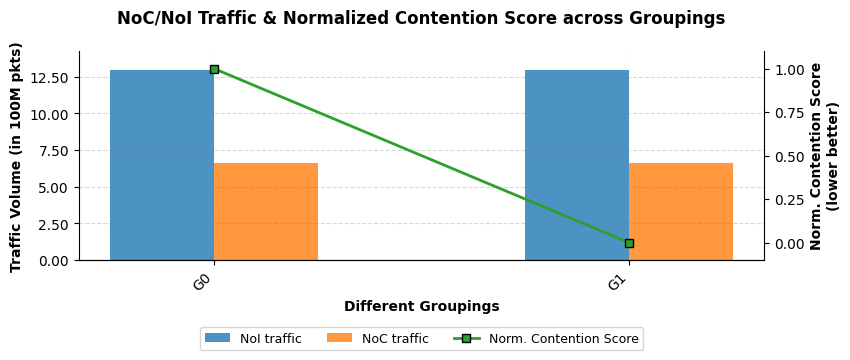


Top 2 Selected Points for LIF_T=3 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G1,10112594,41455882,0.983714,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G0,10112594,41455882,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 4
13
ERROR: Failed to allocate group 4-4

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-3 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=4. Skipping this multiplier.
ERROR: Failed to allocate group 4-4

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,9157480,49096798,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,9333267,47690502,0.511063,3672,3,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,9521427,46185222,0.385314,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,9521427,46185222,0.340145,4032,5,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,9521427,46185222,0.324218,4248,6,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9395988,47188742,0.393389,4464,7,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


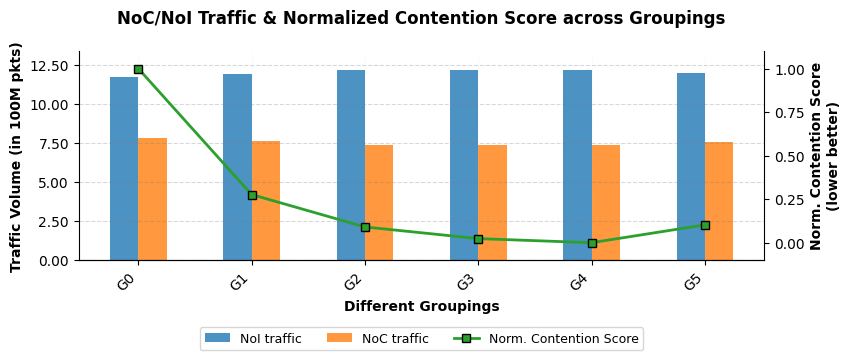


Top 3 Selected Points for LIF_T=4 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G4,9521427,46185222,0.324218,4248,6,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G3,9521427,46185222,0.340145,4032,5,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,9521427,46185222,0.385314,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 5
14
ERROR: Failed to allocate group 7-7

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-6 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=5. Skipping this multiplier.
ERROR: Failed to allocate group 7-7

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8529592,54119900,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8529592,54119900,0.985298,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8733961,52484946,0.365497,3888,4,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8733961,52484946,0.446238,4032,5,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,9132339,49297925,0.450340,4248,6,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9273459,48168965,0.403944,4464,7,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9273459,48168965,0.420326,4680,8,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,9132339,49297925,0.406652,5256,12,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


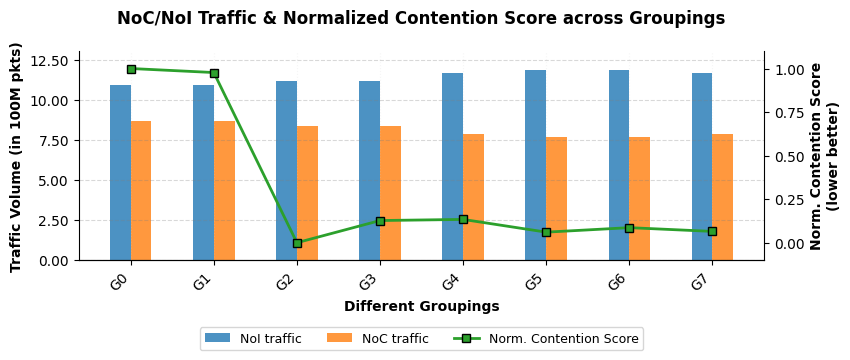


Top 3 Selected Points for LIF_T=5 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G2,8733961,52484946,0.365497,3888,4,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G5,9273459,48168965,0.403944,4464,7,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G7,9132339,49297925,0.406652,5256,12,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 6
16
ERROR: Failed to allocate group 9-9

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-8 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 9-9

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8388626,55247622,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8349426,55561222,0.445493,3672,3,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,9073746,49766659,0.570172,4464,5,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,9073746,49766659,0.587314,4824,6,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8937506,50856579,0.435426,5040,7,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8937506,50856579,0.405008,5616,10,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9073746,49766659,0.424960,6048,12,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,9050706,49950979,0.406128,6696,15,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8937507,50856579,0.359876,6840,16,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


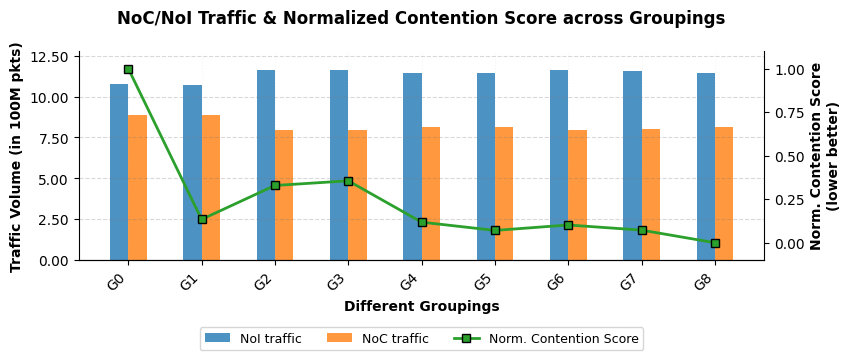


Top 3 Selected Points for LIF_T=6 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G8,8937507,50856579,0.359876,6840,16,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G5,8937506,50856579,0.405008,5616,10,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G7,9050706,49950979,0.406128,6696,15,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 7
18
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-10.0 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-9.595959595959595 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-9.393939393939394 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-9.191919191919192 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multiplier=-8.98989898989899 at LIF_T=7. Skipping this multiplier.
ERROR: Mapping requires 18 chiplets, mesh has 16
No valid groupings generated for multip

,Mesh_Size,Case,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,num_chiplets,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ,Groupings,Chiplet_mapping
0,4x4,Global LIF,44.0,NaN,3168.0,44.0,1.0,11.0,44.0,0.000000,11.342987,11.342987,0.372406,54.923992,24.131937,4.842110,11.715394,79.055929,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,4x4,4-Corner Global LIF,11.0,NaN,3168.0,44.0,1.0,14.0,56.0,0.000000,10.957821,10.957821,0.372406,38.765703,24.131937,3.537720,11.330227,62.897640,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [], 'Crossbars_filled_respe..."
2,4x4,Individual LIF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4x4,DISTIL,3.0,G1,3240.0,45.0,2.0,16.0,64.0,0.610267,0.221212,0.831479,0.372406,57.722451,24.131937,5.013745,1.203885,81.854388,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,4x4,DISTIL,3.0,G0,3168.0,44.0,1.0,15.0,60.0,0.610267,0.221212,0.831479,0.372406,56.725832,24.131937,4.927179,1.203885,80.857769,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,4x4,DISTIL,4.0,G4,4248.0,59.0,6.0,16.0,64.0,0.674104,0.221534,0.895638,0.372406,61.792704,24.131937,5.330369,1.268044,85.924642,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,4x4,DISTIL,4.0,G3,4032.0,56.0,5.0,15.0,60.0,0.674104,0.220881,0.894985,0.372406,61.188680,24.131937,5.292963,1.267391,85.320617,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,4x4,DISTIL,4.0,G2,3888.0,54.0,4.0,15.0,60.0,0.674104,0.219169,0.893272,0.372406,61.749830,24.131937,5.380783,1.265679,85.881767,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,4x4,DISTIL,5.0,G2,3888.0,54.0,4.0,14.0,56.0,0.762737,0.222464,0.985201,0.372406,58.520466,24.131937,4.990211,1.357607,82.652404,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,4x4,DISTIL,5.0,G5,4464.0,62.0,7.0,15.0,60.0,0.695836,0.220881,0.916717,0.372406,61.408944,24.131937,5.302049,1.289124,85.540881,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



################################################################################
# PROCESSING MESH SIZE: 5x5
################################################################################


Running for LIF_T = 1
11
ERROR: Failed to allocate group 1-1

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-0 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=1. Skipping t

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,11292112,32019763,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,11292112,32019763,0.998271,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


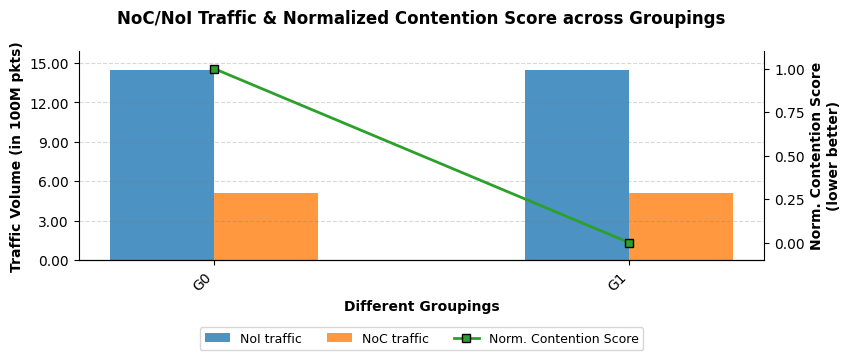


Top 2 Selected Points for LIF_T=2 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G1,11292112,32019763,0.998271,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G0,11292112,32019763,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 3
12
ERROR: Failed to allocate group 6-6

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-5 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=3. Skipping this multiplier.
ERROR: Failed to allocate group 6-6

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,10112594,41455882,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,10112594,41455882,0.988648,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,13364403,15441410,0.962260,4032,3,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,13637620,13255680,0.797714,4968,5,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


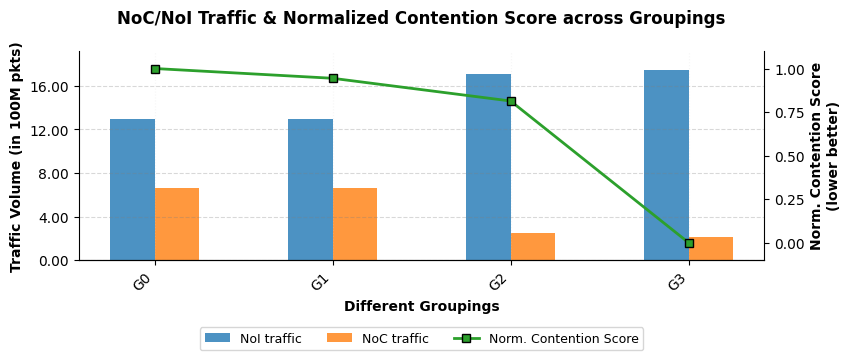


Top 3 Selected Points for LIF_T=3 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G3,13637620,13255680,0.797714,4968,5,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G2,13364403,15441410,0.962260,4032,3,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G1,10112594,41455882,0.988648,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 4
13
ERROR: Failed to allocate group 10-10

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-9 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=4. Skipping this multiplier.
ERROR: Failed to allocate group 10-10

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,9157480,49096798,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,9333267,47690502,0.422096,3672,3,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,9473449,46569042,0.306479,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,9473449,46569042,0.377845,4248,6,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,9473449,46569042,0.316849,4680,8,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9521427,46185222,0.316983,5400,13,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9521429,46185222,0.333156,6696,22,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


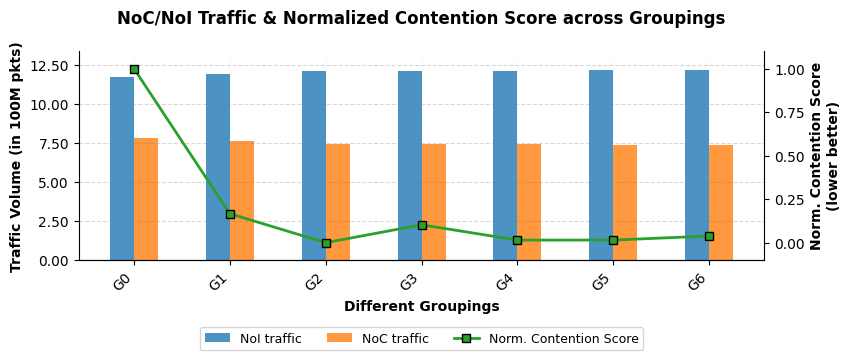


Top 3 Selected Points for LIF_T=4 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G2,9473449,46569042,0.306479,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G4,9473449,46569042,0.316849,4680,8,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G5,9521427,46185222,0.316983,5400,13,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 5
14
ERROR: Failed to allocate group 13-13

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-12 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=5. Skipping this multiplier.
ERROR: Failed to allocate group 13-13

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8529592,54119900,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8529592,54119900,0.982713,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8506019,54308486,0.337215,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8813299,51850246,0.252533,4320,5,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8954419,50721286,0.258837,4536,6,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9273459,48168965,0.314121,4896,7,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9273459,48168965,0.298997,5256,9,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,9273459,48168965,0.288577,5472,10,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,9273459,48168965,0.357734,5904,12,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,9273459,48168965,0.307914,6120,14,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


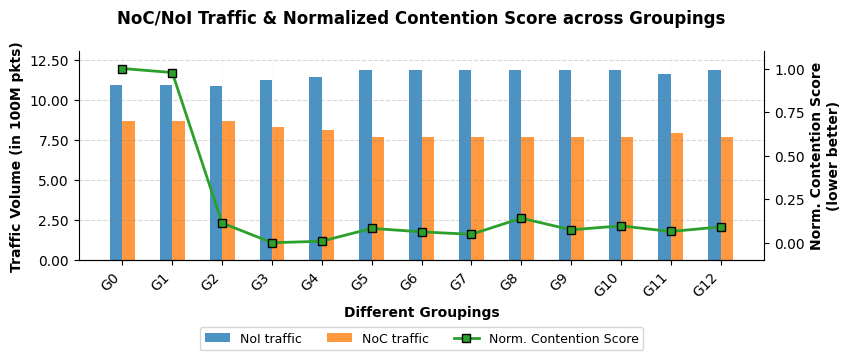


Top 3 Selected Points for LIF_T=5 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G3,8813299,51850246,0.252533,4320,5,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G4,8954419,50721286,0.258837,4536,6,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G7,9273459,48168965,0.288577,5472,10,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 6
16
ERROR: Failed to allocate group 16-16

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-15 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 16-16

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8388626,55247622,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8349426,55561222,0.498524,3672,3,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8948306,50770179,0.478175,4464,5,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8948306,50770179,0.501171,4680,6,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8948306,50770179,0.431073,4896,7,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8948306,50770179,0.355701,5112,8,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8948306,50770179,0.319865,5256,9,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8925266,50954499,0.285817,5832,11,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8925266,50954499,0.303353,6048,12,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8937506,50856579,0.342121,7272,20,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


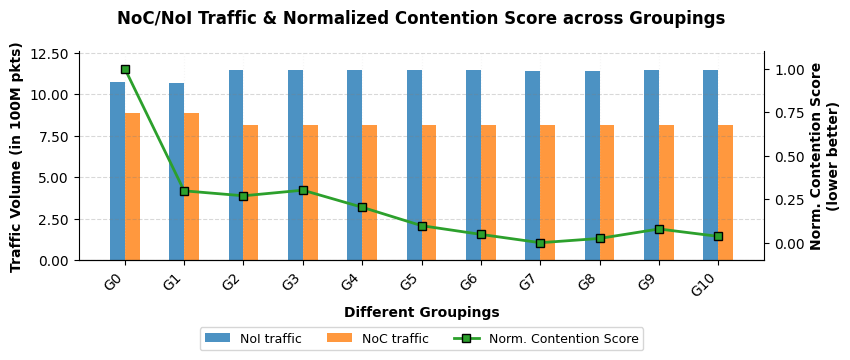


Top 3 Selected Points for LIF_T=6 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G7,8925266,50954499,0.285817,5832,11,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G8,8925266,50954499,0.303353,6048,12,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G10,8937506,50856579,0.311731,8136,27,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 7
18
ERROR: Failed to allocate group 26-26

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-25 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=7. Skipping this multiplier.
ERROR: Failed to allocate group 26-26

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8440754,54830597,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8413794,55046277,0.422093,3672,3,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8975874,50549635,0.372491,3888,4,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8975874,50549635,0.343290,4248,6,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8874894,51357475,0.337204,4824,8,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8874894,51357475,0.354267,5256,9,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8874894,51357475,0.311601,5616,10,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8874894,51357475,0.337372,6120,12,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8874894,51357475,0.328948,6336,13,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8937614,50855715,0.312619,6912,17,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


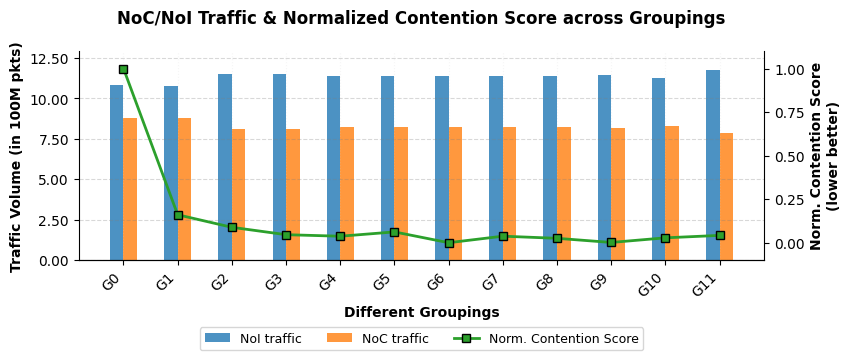


Top 3 Selected Points for LIF_T=7 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G6,8874894,51357475,0.311601,5616,10,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G9,8937614,50855715,0.312619,6912,17,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G8,8874894,51357475,0.328948,6336,13,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 8
20
ERROR: Failed to allocate group 34-34

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-33 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=8. Skipping this multiplier.
ERROR: Failed to allocate group 34-34

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8521682,54112771,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8440302,54763811,0.442230,3672,3,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8895502,51122211,0.335044,4104,4,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8439233,54772376,0.575564,4464,5,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8648983,53094372,0.506279,4680,6,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8610292,53403892,0.367263,4896,7,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8610292,53403892,0.301282,5112,8,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8610292,53403892,0.330492,5256,9,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8771532,52113971,0.365837,5904,12,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8771532,52113971,0.334851,6264,14,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


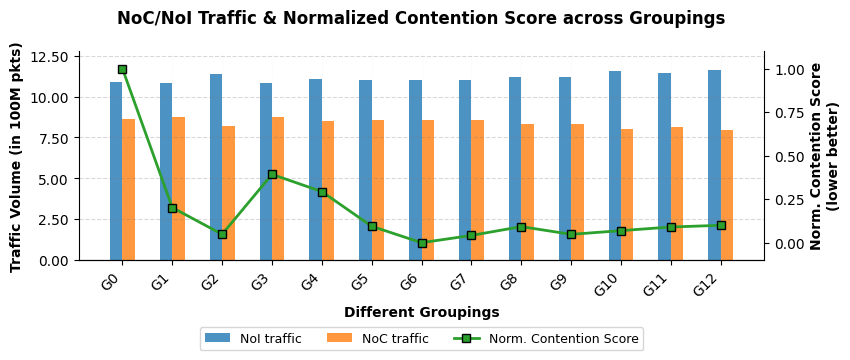


Top 3 Selected Points for LIF_T=8 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G6,8610292,53403892,0.301282,5112,8,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G7,8610292,53403892,0.330492,5256,9,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G9,8771532,52113971,0.334851,6264,14,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 9
22
ERROR: Cannot allocate layers 41-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-40 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=9. Skipping this multiplier.
ERROR: Cannot allocate layers 41-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 8

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8841330,51625987,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8841330,51625987,0.986740,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8757990,52292707,0.470334,3672,3,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8991270,50426467,0.441736,3960,4,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8991270,50426467,0.388414,4032,4,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8991270,50426467,0.367650,4320,5,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8663239,53050737,0.378160,4536,6,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8699670,52759270,0.304775,4896,8,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,9203500,48728627,0.370434,5472,10,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,9224550,48560227,0.478492,5760,11,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


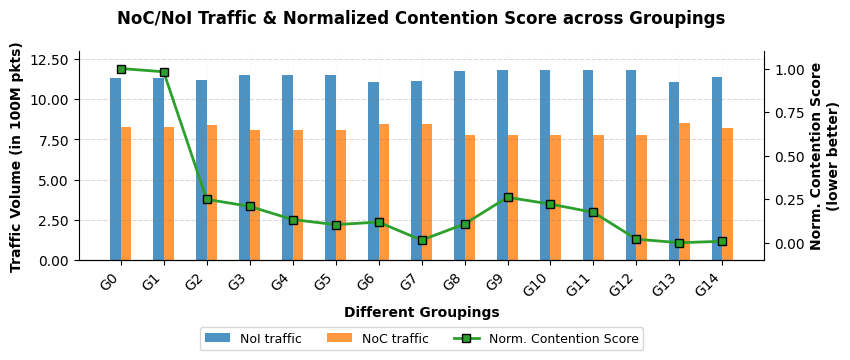


Top 3 Selected Points for LIF_T=9 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G13,8648047,53172255,0.294574,8568,28,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G14,8865310,51434148,0.300290,12816,73,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G7,8699670,52759270,0.304775,4896,8,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 10
26
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-10.0 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-9.595959595959595 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-9.393939393939394 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-9.191919191919192 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for multiplier=-8.98989898989899 at LIF_T=10. Skipping this multiplier.
ERROR: Mapping requires 26 chiplets, mesh has 25
No valid groupings generated for

,Mesh_Size,Case,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,num_chiplets,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ,Groupings,Chiplet_mapping
0,5x5,Global LIF,44.0,NaN,3168.0,44.0,1.0,11.0,44.0,0.000000,11.671770,11.671770,0.372406,44.949618,24.131937,3.851140,12.044176,69.081556,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,5x5,4-Corner Global LIF,11.0,NaN,3168.0,44.0,1.0,14.0,56.0,0.000000,11.028822,11.028822,0.372406,41.830668,24.131937,3.792850,11.401228,65.962605,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [], 'Crossbars_filled_respe..."
2,5x5,Individual LIF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5x5,DISTIL,2.0,G1,3240.0,45.0,2.0,25.0,100.0,0.491727,0.219547,0.711275,0.372406,76.910983,24.131937,6.798893,1.083681,101.042920,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,5x5,DISTIL,2.0,G0,3168.0,44.0,1.0,22.0,88.0,0.491727,0.219341,0.711068,0.372406,73.391803,24.131937,6.493646,1.083474,97.523740,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,5x5,DISTIL,3.0,G3,4968.0,69.0,5.0,25.0,100.0,0.200764,0.222022,0.422786,0.372406,98.535460,24.131937,8.842607,0.795192,122.667397,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,5x5,DISTIL,3.0,G2,4032.0,56.0,3.0,20.0,80.0,0.233278,0.218610,0.451887,0.372406,82.649251,24.131937,7.508373,0.824294,106.781188,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,5x5,DISTIL,3.0,G1,3240.0,45.0,2.0,16.0,64.0,0.610267,0.222179,0.832447,0.372406,66.237179,24.131937,5.729595,1.204853,90.369116,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,5x5,DISTIL,4.0,G2,3888.0,54.0,4.0,14.0,56.0,0.680109,0.221524,0.901633,0.372406,65.723583,24.131937,5.666765,1.274040,89.855521,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,5x5,DISTIL,4.0,G4,4680.0,65.0,8.0,18.0,72.0,0.680110,0.222061,0.902171,0.372406,73.929407,24.131937,6.359758,1.274578,98.061344,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



################################################################################
# PROCESSING MESH SIZE: 6x6
################################################################################


Running for LIF_T = 1
11
ERROR: Failed to allocate group 1-1

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-0 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=1. Skipping t

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,11292112,32019763,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,11292112,32019763,0.983454,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,14007798,10294274,0.874838,4032,3,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,14189943,8837120,0.843159,4752,4,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


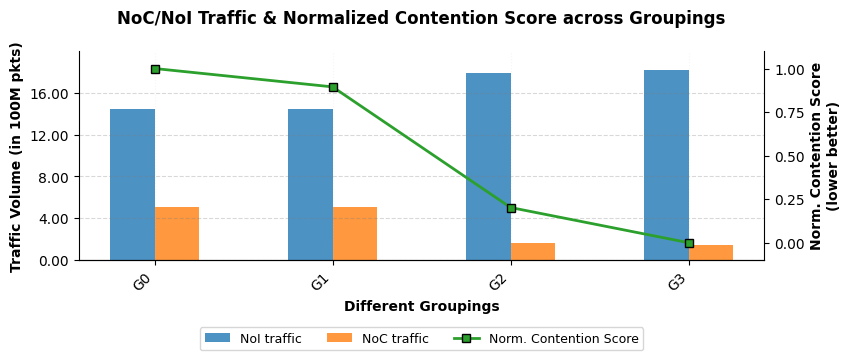


Top 3 Selected Points for LIF_T=2 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G3,14189943,8837120,0.843159,4752,4,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G2,14007798,10294274,0.874838,4032,3,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G1,11292112,32019763,0.983454,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 3
12
ERROR: Failed to allocate group 11-11

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-10 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=3. Skipping this multiplier.
ERROR: Failed to allocate group 11-11

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,10112594,41455882,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,10112594,41455882,0.981061,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,13364403,15441410,0.725745,4464,4,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,13637621,13255680,0.785202,5616,6,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,13983221,10490880,0.758245,6768,9,"[{'start_layer': 1, 'end_layer': 9, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,13983221,10490880,0.782158,6840,9,"[{'start_layer': 1, 'end_layer': 9, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,14257781,8294400,0.870350,7272,10,"[{'start_layer': 1, 'end_layer': 7, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


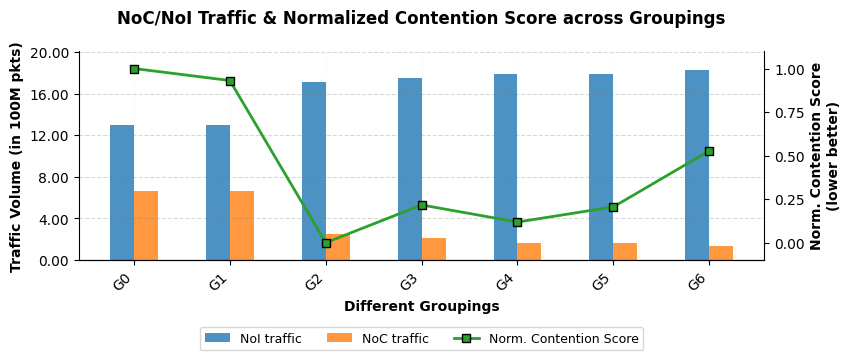


Top 3 Selected Points for LIF_T=3 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G2,13364403,15441410,0.725745,4464,4,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G4,13983221,10490880,0.758245,6768,9,"[{'start_layer': 1, 'end_layer': 9, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G3,13637621,13255680,0.785202,5616,6,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 4
13
ERROR: Failed to allocate group 15-15

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-14 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=4. Skipping this multiplier.
ERROR: Failed to allocate group 15-15

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,9157480,49096798,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,9333267,47690502,0.612699,3672,3,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,9521427,46185222,0.374260,3888,4,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,9521427,46185222,0.323285,4032,5,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,9521427,46185222,0.301544,4464,7,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9521427,46185222,0.303953,4680,8,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9521427,46185222,0.366140,4896,9,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,9521427,46185222,0.312854,6912,24,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


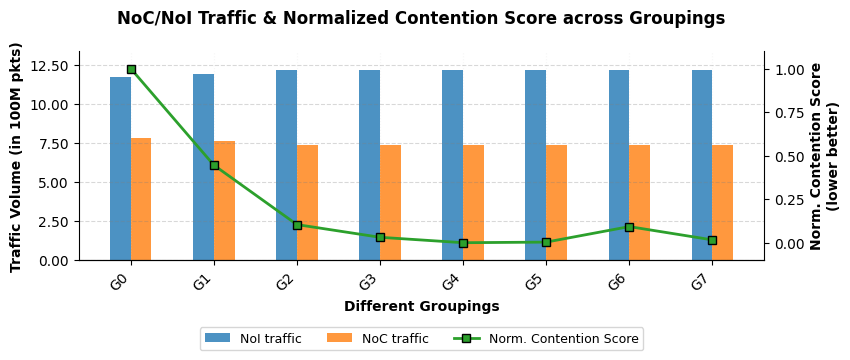


Top 3 Selected Points for LIF_T=4 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G4,9521427,46185222,0.301544,4464,7,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G5,9521427,46185222,0.303953,4680,8,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G7,9521427,46185222,0.312854,6912,24,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 5
14
ERROR: Failed to allocate group 28-28

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-27 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=5. Skipping this multiplier.
ERROR: Failed to allocate group 28-28

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8529592,54119900,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8529592,54119900,0.988746,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8781939,52101126,0.424557,3888,4,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8781939,52101126,0.443952,4104,5,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,9273459,48168965,0.344271,4464,7,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9273459,48168965,0.337841,4680,8,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,9273459,48168965,0.304103,5112,9,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,9273459,48168965,0.320526,5544,11,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,9273459,48168965,0.304651,5832,13,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,9273459,48168965,0.303669,6336,17,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


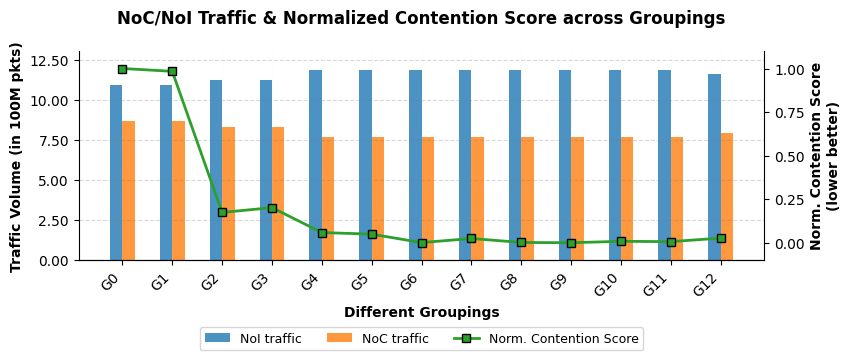


Top 3 Selected Points for LIF_T=5 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G9,9273459,48168965,0.303669,6336,17,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G6,9273459,48168965,0.304103,5112,9,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G8,9273459,48168965,0.304651,5832,13,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 6
16
ERROR: Failed to allocate group 38-38

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-37 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=6. Skipping this multiplier.
ERROR: Failed to allocate group 38-38

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8388626,55247622,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8349426,55561222,0.373769,3672,3,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8937506,50856579,0.370147,3888,4,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8937506,50856579,0.323601,4104,5,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8937506,50856579,0.296565,4680,7,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8937506,50856579,0.330747,4824,8,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8937506,50856579,0.346643,4968,9,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8937506,50856579,0.345532,5112,10,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8937506,50856579,0.301575,5544,12,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8937506,50856579,0.286264,6480,16,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


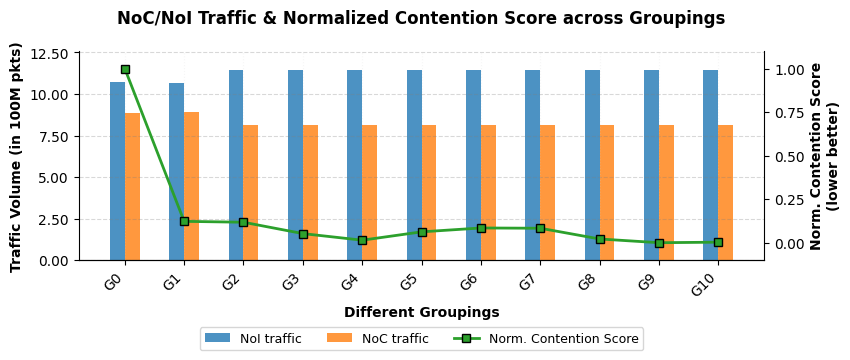


Top 3 Selected Points for LIF_T=6 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G9,8937506,50856579,0.286264,6480,16,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G10,8937506,50856579,0.288451,7416,23,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G4,8937506,50856579,0.296565,4680,7,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 7
18
ERROR: Cannot allocate layers 59-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-58 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=7. Skipping this multiplier.
ERROR: Cannot allocate layers 59-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8440754,54830597,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8413794,55046277,0.338365,3672,3,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8975874,50549635,0.360388,3888,4,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8874894,51357475,0.358544,4320,5,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8874894,51357475,0.310800,4536,6,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8874894,51357475,0.287868,4896,8,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8874894,51357475,0.367336,5256,9,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8874894,51357475,0.346333,5544,11,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8937614,50855715,0.352408,6408,15,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8937614,50855715,0.296742,8424,28,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


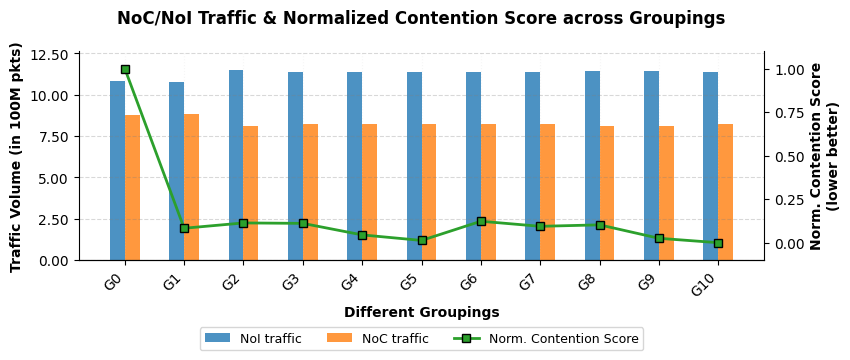


Top 3 Selected Points for LIF_T=7 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G10,8867054,51420195,0.278456,13248,81,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G5,8874894,51357475,0.287868,4896,8,"[{'start_layer': 1, 'end_layer': 31, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G9,8937614,50855715,0.296742,8424,28,"[{'start_layer': 1, 'end_layer': 30, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 8
20
ERROR: Failed to allocate group 80-80

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-79 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=8. Skipping this multiplier.
ERROR: Failed to allocate group 80-80

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-79 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=8.

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8521682,54112771,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8502562,54265731,0.362121,3672,3,"[{'start_layer': 1, 'end_layer': 33, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8988642,50377091,0.323738,4032,4,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8988642,50377091,0.334463,4320,5,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8988642,50377091,0.354677,4680,6,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8887692,51184691,0.384212,4896,7,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8887692,51184691,0.410960,5256,8,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8887692,51184691,0.334008,5472,9,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8887692,51184691,0.340899,5832,11,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8887692,51184691,0.332967,6048,12,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


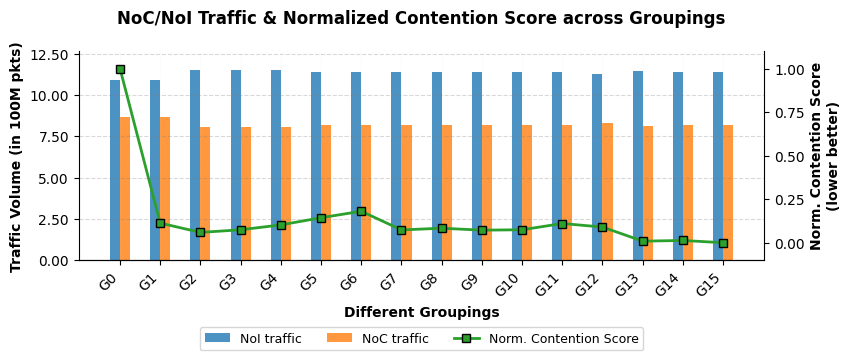


Top 3 Selected Points for LIF_T=8 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G15,8915592,50961491,0.281179,12528,67,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G13,8961172,50596851,0.287589,7992,22,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G14,8880302,51243811,0.290428,8712,29,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 9
22
ERROR: Cannot allocate layers 104-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-103 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-10.0 at LIF_T=9. Skipping this multiplier.
ERROR: Cannot allocate layers 104-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Only covered layers 1-103 out of 126
Discarding incomplete grouping and returning empty list.

No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=9. Skipping this multiplier.
ERROR: Cannot allocate layers 104-126 - no chiplets available

GROUPING FAILED - NOT ALL LAYERS COVERED
Missing layers: [10

,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8841330,51625987,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8841330,51625987,0.984825,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8173159,56971377,0.423173,4176,5,"[{'start_layer': 1, 'end_layer': 29, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8406439,55105137,0.375353,4536,6,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8442870,54813670,0.263859,4752,7,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,9032450,50097027,0.356071,5112,9,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8674200,52963030,0.284196,5400,10,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8931000,50908630,0.362321,5760,11,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8931000,50908630,0.379410,5976,12,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8975560,50552148,0.344614,6984,18,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


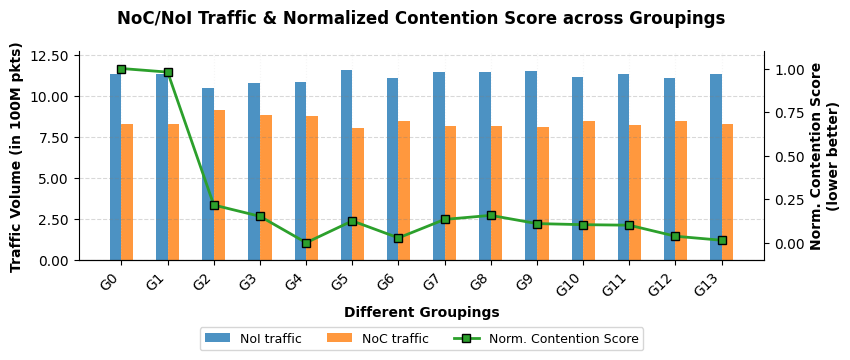


Top 3 Selected Points for LIF_T=9 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G4,8442870,54813670,0.263859,4752,7,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G13,8837840,51653908,0.274239,10368,48,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G6,8674200,52963030,0.284196,5400,10,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 10
26

Full Summary Table for LIF_T=10:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,8930578,50912003,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,8848228,51570803,0.497012,3600,2,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8765898,52229443,0.301185,3672,3,"[{'start_layer': 1, 'end_layer': 39, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8844298,51602243,0.382489,3960,4,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8362548,55456243,0.387421,4176,5,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8362548,55456243,0.312084,4536,6,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8777668,52135283,0.309796,4824,7,"[{'start_layer': 1, 'end_layer': 27, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8262578,56256006,0.298356,5184,9,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8101828,57542006,0.265704,5400,10,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8347348,55577845,0.272327,5616,11,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


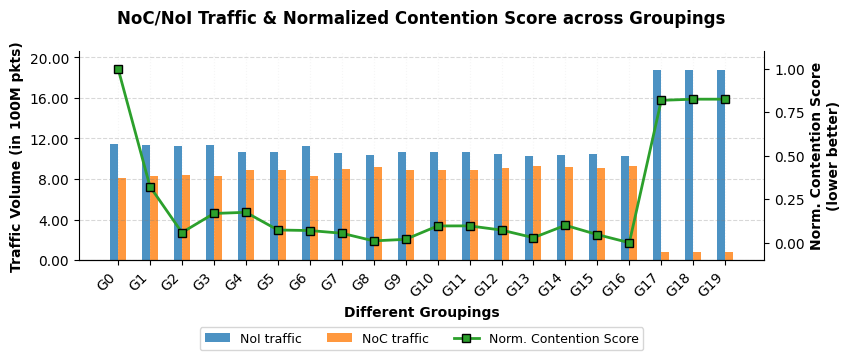


Top 3 Selected Points for LIF_T=10 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G16,8061618,57863687,0.257943,12312,65,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G8,8101828,57542006,0.265704,5400,10,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G9,8347348,55577845,0.272327,5616,11,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 11
31

Full Summary Table for LIF_T=11:


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G0,9067218,49818883,1.000000,3168,1,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G1,9067218,49818883,0.997178,3240,2,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G2,8444338,54801925,0.229712,4608,6,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,G3,8328178,55731205,0.224595,4824,7,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,G4,8043458,58008965,0.203247,5328,11,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,G5,8021398,58185445,0.201709,5400,12,"[{'start_layer': 1, 'end_layer': 37, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,G6,8100308,57554165,0.210315,5544,14,"[{'start_layer': 1, 'end_layer': 35, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,G7,8172308,56978165,0.275811,5832,15,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,G8,8360468,55472885,0.228636,6120,16,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,G9,8235028,56476405,0.210795,6480,18,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."


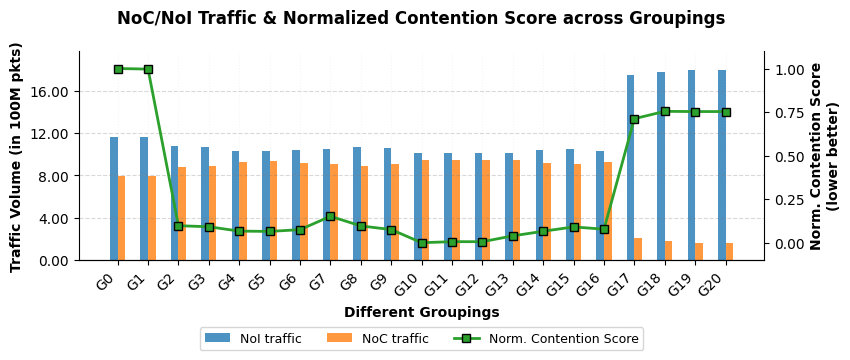


Top 3 Selected Points for LIF_T=11 (via top_k_minima):


,group_ID,NoI (pkts),NoC (pkts),Expected_delay(ms),LIF_MEM(KB),Num Groups,Groupings,Chiplet_mapping
0,G10,7891948,59221049,0.146397,6768,19,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,G12,7882138,59299529,0.151342,6912,21,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
2,G11,7915948,59029049,0.151438,6840,20,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Running for LIF_T = 12
39
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-10.0 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-9.797979797979798 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-9.595959595959595 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-9.393939393939394 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-9.191919191919192 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for multiplier=-8.98989898989899 at LIF_T=12. Skipping this multiplier.
ERROR: Mapping requires 39 chiplets, mesh has 36
No valid groupings generated for

,Mesh_Size,Case,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,num_chiplets,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ,Groupings,Chiplet_mapping
0,6x6,Global LIF,44,NaN,3168,44,1,11,44,0.000000,11.342987,11.342987,0.372406,62.002016,24.131937,5.466110,11.715394,86.133954,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,6x6,4-Corner Global LIF,11,NaN,3168,44,1,14,56,0.000000,11.028822,11.028822,0.372406,40.896416,24.131937,3.708140,11.401228,65.028353,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [], 'Crossbars_filled_respe..."
2,6x6,Individual LIF,10,None,24984,347,126,36,144,0.094878,10.581178,10.676055,0.372406,119.741268,24.131937,11.215872,11.048462,143.873205,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
3,6x6,Individual LIF,11,None,24984,347,126,36,144,0.182054,10.561703,10.743757,0.372406,119.502777,24.131937,11.122997,11.116163,143.634714,"[{'start_layer': 1, 'end_layer': 1, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,6x6,DISTIL,2,G3,4752,66,4,36,144,0.136769,0.222781,0.359551,0.372406,125.688800,24.131937,11.306293,0.731957,149.820738,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
5,6x6,DISTIL,2,G2,4032,56,3,36,144,0.158445,0.222280,0.380725,0.372406,123.157037,24.131937,11.081593,0.753132,147.288974,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
6,6x6,DISTIL,2,G1,3240,45,2,33,132,0.491728,0.220239,0.711967,0.372406,95.369679,24.131937,8.405310,1.084374,119.501617,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
7,6x6,DISTIL,3,G2,4464,62,4,33,132,0.233279,0.225434,0.458713,0.372406,110.276758,24.131937,9.721209,0.831119,134.408696,"[{'start_layer': 1, 'end_layer': 13, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
8,6x6,DISTIL,3,G4,6768,94,9,36,144,0.156381,0.222802,0.379183,0.372406,121.728742,24.131937,10.929776,0.751590,145.860679,"[{'start_layer': 1, 'end_layer': 9, 'lif_tiles...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
9,6x6,DISTIL,3,G3,5616,78,6,36,144,0.200765,0.225068,0.425833,0.372406,126.307926,24.131937,11.184221,0.798240,150.439863,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



CREATING MASTER COMBINED DATAFRAME FOR ALL MESH SIZES


		Master Combined Results (All Mesh Sizes)


,Mesh_Size,Case,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,num_chiplets,Total_area_sq_mm,NoC_latency_ms,NoI_latency_ms,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ,Groupings,Chiplet_mapping
0,4x4,Global LIF,44.0,NaN,3168.0,44.0,1.0,11.0,44.0,0.000000,11.342987,11.342987,0.372406,54.923992,24.131937,4.842110,11.715394,79.055929,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
1,4x4,4-Corner Global LIF,11.0,NaN,3168.0,44.0,1.0,14.0,56.0,0.000000,10.957821,10.957821,0.372406,38.765703,24.131937,3.537720,11.330227,62.897640,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [], 'Crossbars_filled_respe..."
2,4x4,Individual LIF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4x4,DISTIL,3.0,G1,3240.0,45.0,2.0,16.0,64.0,0.610267,0.221212,0.831479,0.372406,57.722451,24.131937,5.013745,1.203885,81.854388,"[{'start_layer': 1, 'end_layer': 124, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
4,4x4,DISTIL,3.0,G0,3168.0,44.0,1.0,15.0,60.0,0.610267,0.221212,0.831479,0.372406,56.725832,24.131937,4.927179,1.203885,80.857769,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,6x6,DISTIL,10.0,G8,5400.0,75.0,10.0,26.0,104.0,0.833656,0.220618,1.054274,0.372406,90.081785,24.131937,7.694726,1.426680,114.213723,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
70,6x6,DISTIL,10.0,G9,5616.0,78.0,11.0,26.0,104.0,0.808367,0.221013,1.029380,0.372406,90.531995,24.131937,7.737025,1.401786,114.663932,"[{'start_layer': 1, 'end_layer': 25, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
71,6x6,DISTIL,11.0,G10,6768.0,94.0,19.0,31.0,124.0,0.877921,0.219520,1.097441,0.372406,95.188400,24.131937,8.137763,1.469847,119.320338,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."
72,6x6,DISTIL,11.0,G12,6912.0,96.0,21.0,31.0,124.0,0.872301,0.219288,1.091589,0.372406,95.571629,24.131937,8.182451,1.463996,119.703567,"[{'start_layer': 1, 'end_layer': 23, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,..."



Master combined results exported to: master_combined_lif_results_all_mesh_sizes_densenet121.csv

ALL MESH SIZE SWEEPS COMPLETE


In [ ]:
#@title Generate all data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from snn_mapper import SNNMapper
import copy

# Update BookSim simulator parameters
update_param_booksim('Chiplet_level_config', 'channel_width', NoC_buswidth)
update_param_booksim('System_level_config', 'channel_width', NoI_buswidth)
update_param_booksim('techfile_chiplet.txt', 'wire_length', NoC_wire_length)
update_param_booksim('techfile_system.txt', 'wire_length', NoI_wire_length)

# Calculate cycle times for NoC and NoI
NoC_cycle_time_ns = calc_cycle_time(NoC_Freq, NoC_wire_length * 1e3, NoC_wire_delay_per_mm_ns)
NoI_cycle_time_ns = calc_cycle_time(NoI_Freq, NoI_wire_length * 1e3, NoI_wire_delay_per_mm_ns)

# ============================================================================
# MESH SIZE SWEEP LOOP
# ============================================================================
all_combined_results = {}  # Dictionary to store combined results for each mesh size

for mesh_size in mesh_sizes:
    mesh_rows = mesh_size
    mesh_cols = mesh_size

    print(f"\n{'#'*80}")
    print(f"# PROCESSING MESH SIZE: {mesh_rows}x{mesh_cols}")
    print(f"{'#'*80}\n")

    # ============================================================================
    # CODE CELL 1: sweep through LIF_tiles and display everything
    # ============================================================================
    data = {"LIF_TILES": [], "Mem": [], "Expected_delay": []}
    all_summary_dfs, all_top_n_dfs = {}, {}
    all_M_sys_dfs, all_chiplet_dfs_lists = {}, {}
    selected_groupings = {}
    chiplet_configs_df = {}

    for LIF_T in LIF_T_list:
        print(f"\n{'='*60}\nRunning for LIF_T = {LIF_T}\n{'='*60}")

        mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T-SRAM_T, X=xbar_size, P=100,
                           Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                           allow_break_columns=True, include_chiplets=False)
        mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()
        mapper.layer_output_sizes = dict(zip(range(1, len(mapper.OFMS) + 1), mapper.OFMS))
        mapper.chiplet_data = mapper._generate_chiplet_mapping()
        print(len(mapper.chiplet_data))
        SUM_LIF_MEM_UNGROUPED = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum() * SRAM_KB_per_tile

        # ---- sweep threshold multipliers → candidate groupings
        R = {'multiplier': [], 'groups': [], 'cost': [], 'tiles': [], 'grouping': []}
        for mult in threshold_multipliers:
            gs = find_optimal_groupings_mesh_aware(
                len(mapper.IFMS), mesh_rows, mesh_cols, threshold_multiplier=mult, placement_strategy='exclusive',
                inter_cost=50, debug=False, individual=False)

            if not gs:
                print(f"No valid groupings generated for multiplier={mult} at LIF_T={LIF_T}. Skipping this multiplier.")
                continue

            R['grouping'].append(gs)
            R['multiplier'].append(mult)
            R['groups'].append(len(gs))
            R['cost'].append(sum(g.get('cost', 0) for g in gs))
            R['tiles'].append(sum(g['lif_tiles'] for g in gs))

        if not R['grouping']:
            print(f"\n WARNING: No valid groupings generated for LIF_T={LIF_T} across all threshold multipliers.")
            print(f"Skipping all analysis (traffic, plotting) for LIF_T={LIF_T}.\n")
            continue

        # ---- sort by (tiles, cost), then keep first per unique tiles
        tiles = np.asarray(R['tiles'], float)
        costs = np.asarray(R['cost'], float)
        groups = np.asarray(R['groups'], int)
        mults = np.asarray(R['multiplier'], float)
        groupings = np.asarray(R['grouping'], object)

        order = np.lexsort((costs, tiles))  # primary=tiles, secondary=cost
        t, c, g, m, grp = tiles[order], costs[order], groups[order], mults[order], groupings[order]
        keep = np.r_[True, t[1:] != t[:-1]]
        t, c, g, m, grp = t[keep], c[keep], g[keep], m[keep], grp[keep]

        unique_groupings = list(grp)
        unique_tiles = t.astype(int).tolist()
        unique_costs = c.tolist()
        unique_num_groups = g.astype(int).tolist()

        # ---- Find individual groupings
        individual_groupings = find_optimal_groupings_mesh_aware(
            len(mapper.IFMS), mesh_rows, mesh_cols, threshold_multiplier=None, placement_strategy='exclusive',
            inter_cost=50, debug=False, individual=True)

        if individual_groupings:
            unique_groupings.append(individual_groupings)
            unique_tiles.append(sum(g['lif_tiles'] for g in individual_groupings))
            unique_costs.append(sum(g.get('cost', 0) for g in individual_groupings))
            unique_num_groups.append(len(individual_groupings))

        # ---- build chiplet configs & traffic
        all_chiplet_configs = [
            add_lif_tiles(mapper.chiplet_data, each_grouping, NT, LIF_T, NPE, mesh_rows, mesh_cols)
            for each_grouping in unique_groupings
        ]

        traffic_data = [
            calculate_traffic(gcfg, cfg, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                              mesh_rows=mesh_rows, mesh_cols=mesh_cols)
            for gcfg, cfg in zip(unique_groupings, all_chiplet_configs)
        ]

        # unpack
        inter_totals, intra_totals = map(np.array, zip(*[(td[0], td[1]) for td in traffic_data]))
        sys_dfs = [td[2] for td in traffic_data]
        chiplet_dfs_lists = [td[3] for td in traffic_data]

        labels_arr = np.array([f"G{i}" for i in range(len(unique_groupings))])

        chiplet_configs_df[LIF_T] = pd.DataFrame({
            'group_ID': labels_arr,
            'chiplet_config': all_chiplet_configs,
            'Groupings': unique_groupings
        })

        # store matrices for this LIF_T
        all_M_sys_dfs[LIF_T] = dict(zip(labels_arr, sys_dfs))
        all_chiplet_dfs_lists[LIF_T] = dict(zip(labels_arr, chiplet_dfs_lists))

        # ---- Expected "delay" proxy: normalized Yan score (0..1) in label order
        out = yan_overlap_scores_normalized(all_M_sys_dfs, lif_t_idx=LIF_T, sample_cap=None, mode="max",
                                            all_M_chiplet_dfs=all_chiplet_dfs_lists)
        expected_delay_norm = np.array([out["norm"][gid] for gid in labels_arr], dtype=float)

        summary_df = pd.DataFrame({
            "group_ID": labels_arr,
            "NoI (pkts)": inter_totals,
            "NoC (pkts)": intra_totals,
            "Expected_delay(ms)": expected_delay_norm,
            "LIF_MEM(KB)": np.array(unique_tiles) * SRAM_KB_per_tile,
            "Num Groups": unique_num_groups,
            "Groupings": unique_groupings,
            'Chiplet_mapping': all_chiplet_configs
        })
        all_summary_dfs[LIF_T] = summary_df

        print(f"\nFull Summary Table for LIF_T={LIF_T}:")
        display(summary_df.drop(columns=to_drop))
        plot_grouping_traffic_delay(summary_df, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth)

        # ---- select top-k using top_k_minima (no pareto_plot)
        selected_ids = top_k_minima(
            summary_df,
            k=top_n,
            metric="Expected_delay(ms)",
            order_by="Num Groups",
            allow_plateaus=True,
            mode="hybrid"
        )
        top_n_df = (
            summary_df.loc[summary_df["group_ID"].isin(selected_ids)]
            .sort_values(by=["Expected_delay(ms)", "Num Groups"])
            .reset_index(drop=True)
        )
        all_top_n_dfs[LIF_T] = top_n_df

        print(f"\nTop {len(top_n_df)} Selected Points for LIF_T={LIF_T} (via top_k_minima):")
        display(top_n_df.drop(columns=to_drop))

    # ============================================================================
    # CODE CELL 2: run booksim and collect results
    # ============================================================================
    print('\n' + "="*80)
    print("Running Booksim on all DISTIL cases")
    print("="*80 + '\n')
    results = []

    # Calculate Computation Latency and energy
    Comp_Latency = sum(mapper.TOPS) * Timestep / (1e12 * TOPS * 8)  # in s
    Comp_energy = sum(mapper.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12  # in J

    # Define mesh layouts
    NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
    noc_rows = int(np.sqrt(NT))
    NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]

    for lif_t in LIF_T_list:
        if lif_t not in all_top_n_dfs:
            continue
        group_ids_to_check = list(all_top_n_dfs[lif_t]['group_ID'].values)
        if len(group_ids_to_check):
            for i in range(len(group_ids_to_check)):
                print(f"Processing lif_t={lif_t}, group_id={group_ids_to_check[i]}")
                top_NoC_matrices = []
                M_sys_matrix = all_M_sys_dfs[lif_t][group_ids_to_check[i]]
                chiplet_matrices = all_chiplet_dfs_lists[lif_t][group_ids_to_check[i]]

                for each_chiplet_matrix in chiplet_matrices:
                    each_chiplet_matrix_top_99, _ = split_top_rest(each_chiplet_matrix, percent=top_NoC_percent)
                    top_NoC_matrices.append(each_chiplet_matrix_top_99)
                NoI_matrix_top_99, _ = split_top_rest(M_sys_matrix, percent=top_NoI_percent)

                # Scale traffic matrices
                chiplet_scaled_dfs, chiplet_scaling_factors, \
                system_scaled_df, system_scaling_factor = scale_traffic_matrices(
                    system_matrix=NoI_matrix_top_99, chiplet_matrices=top_NoC_matrices, minimum_traffic=min_traffic_packets)

                communication_matrix = system_scaled_df.values

                # Run BookSim for NoI (system-wide)
                NoI_latency_raw, NoI_power_raw = run_booksim_NoI(communication_matrix, NoI_mesh_layout)

                # Run BookSim for NoC (per-chiplet)
                if optimize_tile_placement:
                    NoC_mesh_layouts = []
                    for each_chiplet_matrix in chiplet_matrices:
                        if each_chiplet_matrix.sum().sum() == 0:
                            NoC_mesh_layouts.append(NoC_mesh_layout)
                        else:
                            out_min = optimize_swap_only(noc_traffic=each_chiplet_matrix, initial_layout=NoC_mesh_layout,
                                                         max_iters=200, K=8, stop_at_min=True, enforce_true_local_min=True,
                                                         rng_seed=0, verbose=False)
                            grid = print_grid(out_min["P"], side=4, one_based=False, print_grid=False)
                            NoC_mesh_layouts.append(grid)
                else:
                    NoC_mesh_layouts = [NoC_mesh_layout] * len(chiplet_scaled_dfs)

                NoC_latencies_raw, NoC_powers_raw = run_booksim_NoC(chiplet_scaled_dfs, NoC_mesh_layouts)

                NoC_latencies_scaled = np.array(NoC_latencies_raw) * np.array(chiplet_scaling_factors)
                NoI_latency_scaled = NoI_latency_raw * system_scaling_factor

                # Retrieve 'LIF_MEM(KB)' and 'Groupings' from all_top_n_dfs
                current_row = all_top_n_dfs[lif_t][all_top_n_dfs[lif_t]['group_ID'] == group_ids_to_check[i]]
                lif_mem_kb = current_row['LIF_MEM(KB)'].values[0]
                groupings = current_row['Groupings'].values[0]

                chiplet_mapping = chiplet_configs_df[lif_t][chiplet_configs_df[lif_t]['group_ID'] == group_ids_to_check[i]]['chiplet_config'].values[0]

                comm_energy = (np.array(NoC_powers_raw).sum() + NoI_power_raw) * ((NoC_cycle_time_ns * NoC_latencies_scaled.sum() + NoI_cycle_time_ns * NoI_latency_scaled) / 1e6)

                results.append({
                    'lif_t': lif_t,
                    'group_id': group_ids_to_check[i],
                    'LIF_MEM(KB)': lif_mem_kb,
                    'LIF_MEM_Tiles': np.ceil(lif_mem_kb / SRAM_KB_per_tile).astype(int),
                    "num_groups": len(groupings),
                    'num_chiplets': len(chiplet_mapping),
                    'Total_area_sq_mm': len(chiplet_mapping) * (Chiplet_dim ** 2),
                    'NoC_latency_ms': NoC_cycle_time_ns * NoC_latencies_scaled.sum() / 1e6,
                    'NoI_latency_ms': NoC_cycle_time_ns * NoI_latency_scaled / 1e6,
                    'Total_comm_latency_ms': (NoC_cycle_time_ns * NoC_latencies_scaled.sum() + NoC_cycle_time_ns * NoI_latency_scaled) / 1e6,
                    'Comp_Latency_ms': Comp_Latency * 1e3,
                    'Comm_energy_mJ': comm_energy,
                    'Comp_energy_mJ': Comp_energy * 1e3,
                    'Comm_power_W': (np.array(NoC_powers_raw).sum() + NoI_power_raw),
                    'End_to_end_latency_ms': Comp_Latency * 1e3 + (NoC_cycle_time_ns * NoC_latencies_scaled.sum() + NoC_cycle_time_ns * NoI_latency_scaled) / 1e6,
                    'End_to_end_energy_mJ': comm_energy + Comp_energy * 1e3,
                    'Groupings': groupings,
                    'Chiplet_mapping': chiplet_mapping
                })

    print("All processing complete.")
    DISTIL_results = pd.DataFrame(results)

    # ============================================================================
    # CODE CELL 3: Sweep through all LIF_T cases for Individual LIF
    # ============================================================================
    print('\n' + "="*80)
    print("Running Booksim on Individual LIF case")
    print("="*80 + '\n')
    individual_results = []

    for LIF_T_case in LIF_T_list:
        if LIF_T_case not in all_summary_dfs:
            print(f'No data available for LIF_T={LIF_T_case}. Skipping.')
            continue

        print(f"\nProcessing Individual LIF case for LIF_T={LIF_T_case}")

        mapper = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT-LIF_T_case-SRAM_T, X=xbar_size, P=100,
                           Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                           allow_break_columns=True, include_chiplets=False)
        mapper.tunable_params, mapper.xbars, mapper.IFMS, mapper.OFMS, mapper.TOPS, mapper.MEMS = mapper._calc_tunable_params()

        try:
            individual_grp = all_summary_dfs[LIF_T_case].iloc[-1]['Groupings']
            individual_chiplet_mapping = chiplet_configs_df[LIF_T_case].iloc[-1]['chiplet_config']
        except (IndexError, KeyError):
            continue

        if len(individual_grp) < len(mapper.weights):
            individual_available = False
            print(f'Individual LIF not possible for LIF_T={LIF_T_case}, increase LIF_T/Chiplet mesh size')
        else:
            individual_available = True

        if individual_available:
            Comp_Latency = sum(mapper.TOPS) * Timestep / (1e12 * TOPS * 8)
            Comp_energy = sum(mapper.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12

            _, _, individual_system_df, individual_chiplet_dfs = calculate_traffic(
                individual_grp, individual_chiplet_mapping, NoC_buswidth=NoC_buswidth,
                NoI_buswidth=NoI_buswidth, mesh_rows=mesh_rows, mesh_cols=mesh_cols
            )

            individual_LIF_needed_tiles = np.ceil(np.array(mapper.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).sum()

            NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]
            noc_rows = int(np.sqrt(NT))
            NoC_mesh_layout = [[(r * noc_rows + c) for c in range(noc_rows)] for r in range(noc_rows)]

            top_NoC_matrices = []
            for each_chiplet_matrix in individual_chiplet_dfs:
                each_chiplet_matrix_top_99, _ = split_top_rest(each_chiplet_matrix, percent=top_NoC_percent)
                top_NoC_matrices.append(each_chiplet_matrix_top_99)
            NoI_matrix_top_99, _ = split_top_rest(individual_system_df, percent=top_NoI_percent)

            chiplet_dfs_top_99_scaled, chiplet_dfs_top_99_scaling_factors, system_df_top_99_scaled, system_df_top_99_scaling_factor = scale_traffic_matrices(
                system_matrix=NoI_matrix_top_99, chiplet_matrices=top_NoC_matrices, minimum_traffic=min_traffic_packets
            )

            individual_NoI_latency_raw, individual_NoI_power_raw = run_booksim_NoI(system_df_top_99_scaled.values, NoI_mesh_layout)

            if optimize_tile_placement:
                NoC_mesh_layouts = []
                for each_chiplet_matrix in individual_chiplet_dfs:
                    if each_chiplet_matrix.sum().sum() == 0:
                        NoC_mesh_layouts.append(NoC_mesh_layout)
                    else:
                        out_min = optimize_swap_only(noc_traffic=each_chiplet_matrix, initial_layout=NoC_mesh_layout,
                                                     max_iters=200, K=8, stop_at_min=True, enforce_true_local_min=True,
                                                     rng_seed=0, verbose=False)
                        grid = print_grid(out_min["P"], side=4, one_based=False, print_grid=False)
                        NoC_mesh_layouts.append(grid)
            else:
                NoC_mesh_layouts = [NoC_mesh_layout] * len(individual_chiplet_mapping)

            individual_NoC_latencies_raw, individual_NoC_powers_raw = run_booksim_NoC(chiplet_dfs_top_99_scaled, NoC_mesh_layouts)
            individual_NoC_latencies_scaled = np.array(individual_NoC_latencies_raw) * np.array(chiplet_dfs_top_99_scaling_factors)

            individual_NoI_latency_ms = individual_NoI_latency_raw * system_df_top_99_scaling_factor * NoI_cycle_time_ns / 1e6
            individual_NoC_latency_ms = individual_NoC_latencies_scaled.sum() * NoC_cycle_time_ns / 1e6
            individual_LIF_needed = individual_LIF_needed_tiles * SRAM_KB_per_tile

            comm_energy = (np.array(individual_NoC_powers_raw).sum() + individual_NoI_power_raw) * ((NoC_cycle_time_ns * individual_NoC_latencies_scaled.sum() + NoI_cycle_time_ns * individual_NoI_latency_raw * system_df_top_99_scaling_factor) / 1e6),

            individual_results.append({
                'lif_t': LIF_T_case,
                'group_id': None,
                'LIF_MEM(KB)': individual_LIF_needed,
                'LIF_MEM_Tiles': individual_LIF_needed_tiles,
                "num_groups": len(individual_grp),
                'num_chiplets': len(individual_chiplet_mapping),
                'Total_area_sq_mm': len(individual_chiplet_mapping) * (Chiplet_dim ** 2),
                'NoC_latency_ms': individual_NoC_latency_ms,
                'NoI_latency_ms': individual_NoI_latency_ms,
                'Total_comm_latency_ms': individual_NoI_latency_ms + individual_NoC_latency_ms,
                'Comp_Latency_ms': Comp_Latency * 1e3,
                'Comm_energy_mJ': comm_energy[0],
                'Comp_energy_mJ': Comp_energy * 1e3,
                'Comm_power_W': (np.array(individual_NoC_powers_raw).sum() + individual_NoI_power_raw),
                'End_to_end_latency_ms': Comp_Latency * 1e3 + individual_NoI_latency_ms + individual_NoC_latency_ms,
                'End_to_end_energy_mJ': comm_energy[0] + Comp_energy * 1e3,
                'Groupings': individual_grp,
                'Chiplet_mapping': individual_chiplet_mapping
            })

            print(f"  - Successfully computed Individual LIF for LIF_T={LIF_T_case}")

    if individual_results:
        individual_result_df = pd.DataFrame(individual_results)
    else:
        print("\nNo Individual LIF cases were available across all LIF_T.")
        individual_result_df = pd.DataFrame()

    # ============================================================================
    # CODE CELL 4: Global LIF Module Case
    # ============================================================================
    print('\n' + "="*80)
    print("Running Booksim on GLobal LIF case")
    print("="*80 + '\n')
    mapper_global = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT, X=xbar_size, P=100,
                              Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                              allow_break_columns=True, include_chiplets=False)
    mapper_global.tunable_params, mapper_global.xbars, mapper_global.IFMS, mapper_global.OFMS, mapper_global.TOPS, mapper_global.MEMS = mapper_global._calc_tunable_params()
    mapper_global.layer_output_sizes = dict(zip(range(1, len(mapper_global.OFMS) + 1), mapper_global.OFMS))
    mapper_global.chiplet_data = mapper_global._generate_chiplet_mapping()

    LIF_needed = np.ceil(np.array(mapper_global.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()

    LIF_chiplet = {
        'Layers_filled': [],
        'Crossbars_filled_respective_layer': [],
        'Crossbars_remaining_respective_layer': [],
        'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(LIF_needed)}},
        'Empty_crossbars': NT * NPE
    }

    EMPTY = {
        'Layers_filled': [],
        'Crossbars_filled_respective_layer': [],
        'Crossbars_remaining_respective_layer': [],
        'Layer_tile_distribution': {},
        'Empty_crossbars': NT * NPE
    }

    global_grp = [{
        'start_layer': 1,
        'end_layer': len(mapper_global.weights),
        'lif_tiles': LIF_needed,
        'lif_distribution': [(len(mapper_global.chiplet_data), LIF_needed)],
        'cost': 0.0
    }]

    cc = copy.deepcopy(mapper_global.chiplet_data)
    cc += [LIF_chiplet]

    Comp_Latency = sum(mapper_global.TOPS) * Timestep / (1e12 * TOPS * 8)
    Comp_energy = sum(mapper_global.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12

    _, _, global_system_df, global_chiplet_dfs = calculate_traffic(global_grp, cc, NoC_buswidth=NoC_buswidth,
                                                                     NoI_buswidth=NoI_buswidth,
                                                                     mesh_rows=mesh_rows, mesh_cols=mesh_cols)
    system_df_top_99, _ = split_top_rest(global_system_df, percent=0.999)
    NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]

    _, _, system_df_top_99_scaled, system_df_top_99_scaling_factor = scale_traffic_matrices(
        system_matrix=system_df_top_99, chiplet_matrices=global_chiplet_dfs,
        minimum_traffic=10)

    global_NoI_latency_raw, global_NoI_power_raw = run_booksim_NoI(system_df_top_99_scaled.values, NoI_mesh_layout, n=len(cc)-1)

    global_NoI_latency_ms = global_NoI_latency_raw * system_df_top_99_scaling_factor * NoI_cycle_time_ns / 1e6
    global_LIF_needed = LIF_needed * SRAM_KB_per_tile

    global_result = pd.DataFrame({
        'lif_t': [LIF_needed],
        'group_id': [np.nan],
        'LIF_MEM(KB)': [global_LIF_needed],
        'LIF_MEM_Tiles': [np.ceil(global_LIF_needed / SRAM_KB_per_tile).astype(int)],
        "num_groups": [1],
        'num_chiplets': [len(mapper_global.chiplet_data) + 1],
        'Total_area_sq_mm': [(len(mapper_global.chiplet_data) + 1) * (Chiplet_dim ** 2)],
        'NoC_latency_ms': [0],
        'NoI_latency_ms': [global_NoI_latency_ms],
        'Total_comm_latency_ms': [global_NoI_latency_ms],
        'Comp_Latency_ms': [Comp_Latency * 1e3],
        'Comm_energy_mJ': [(global_NoI_power_raw) * (global_NoI_latency_ms)],
        'Comp_energy_mJ': [Comp_energy * 1e3],
        'Comm_power_W': [global_NoI_power_raw],
        'End_to_end_latency_ms': [Comp_Latency * 1e3 + global_NoI_latency_ms],
        'End_to_end_energy_mJ': [(global_NoI_power_raw) * (global_NoI_latency_ms) + Comp_energy * 1e3],
        'Groupings': [global_grp],
        'Chiplet_mapping': [cc]
    })

    # _ = visualize_groups(global_grp, cc, mesh_rows, mesh_cols, LIF_T=LIF_needed, max_lines=2,
    #                      figsize=(8, 6), fig_fontsize=4, legend_fontsize=9)

    # ============================================================================
    # CODE CELL 5: 4 corner Global LIF Module Case
    # ============================================================================
    print('\n' + "="*80)
    print("Running Booksim on 4-corner LIF case")
    print("="*80 + '\n')
    try:
      mapper_global = SNNMapper(weights=network, layer_groups=[], NPE=NPE, NT=NT, X=xbar_size, P=100,
                                Vmem_res=Vmem_res, Timestep=Timestep, NoC_buswidth=NoC_buswidth, NoI_buswidth=NoI_buswidth,
                                allow_break_columns=True, include_chiplets=False)
      mapper_global.tunable_params, mapper_global.xbars, mapper_global.IFMS, mapper_global.OFMS, mapper_global.TOPS, mapper_global.MEMS = mapper_global._calc_tunable_params()
      mapper_global.layer_output_sizes = dict(zip(range(1, len(mapper_global.OFMS) + 1), mapper_global.OFMS))
      mapper_global.chiplet_data = mapper_global._generate_chiplet_mapping()

      LIF_needed = np.ceil(np.array(mapper_global.MEMS) / (SRAM_KB_per_tile * 1024)).astype(int).max()
      tiles_per_lif = np.ceil(LIF_needed / 4).astype(int)

      # Check if 4-corner configuration is possible
      min_required_positions = len(mapper_global.chiplet_data) + 4
      total_positions = mesh_rows * mesh_cols

      four_corner_available = (total_positions >= min_required_positions)

      if not four_corner_available:
          print(f'4-Corner Global LIF not possible: need {min_required_positions} positions but only {total_positions} available in {mesh_rows}x{mesh_cols} mesh')
          print('Filling 4-Corner Global LIF results with NaN values.')

          # Create placeholder DataFrame with NaN values
          if not global_result.empty:
              num_rows = len(global_result)
              four_corner_global_result = pd.DataFrame(np.nan, index=range(num_rows), columns=global_result.columns)
          else:
              four_corner_global_result = pd.DataFrame()
      else:
          LIF_chiplet = {
              'Layers_filled': [],
              'Crossbars_filled_respective_layer': [],
              'Crossbars_remaining_respective_layer': [],
              'Layer_tile_distribution': {'LIF0': {i: NPE for i in range(tiles_per_lif)}},
              'Empty_crossbars': NT * NPE
          }

          EMPTY = {
              'Layers_filled': [],
              'Crossbars_filled_respective_layer': [],
              'Crossbars_remaining_respective_layer': [],
              'Layer_tile_distribution': {},
              'Empty_crossbars': NT * NPE
          }

          cc, global_grp = build_four_corner_chiplet_array(
              mesh_rows=mesh_rows,
              mesh_cols=mesh_cols,
              compute_chiplets=mapper_global.chiplet_data,
              LIF_chiplet=LIF_chiplet,
              EMPTY=EMPTY,
              tiles_per_lif=tiles_per_lif,
              weights=mapper_global.weights
          )

          Comp_Latency = sum(mapper_global.TOPS) * Timestep / (1e12 * TOPS * 8)
          Comp_energy = sum(mapper_global.TOPS) * Timestep * ENERGY_PER_MAC_pj / 1e12

          _, _, global_system_df, global_chiplet_dfs = calculate_traffic(global_grp, cc, NoC_buswidth=NoC_buswidth,
                                                                          NoI_buswidth=NoI_buswidth,
                                                                          mesh_rows=mesh_rows, mesh_cols=mesh_cols)
          system_df_top_99, _ = split_top_rest(global_system_df, percent=top_NoI_percent)
          NoI_mesh_layout = [[(r * mesh_cols + c) for c in range(mesh_cols)] for r in range(mesh_rows)]

          _, _, system_df_top_99_scaled, system_df_top_99_scaling_factor = scale_traffic_matrices(
              system_matrix=system_df_top_99, chiplet_matrices=global_chiplet_dfs,
              minimum_traffic=10)

          global_NoI_latency_raw, global_NoI_power_raw = run_booksim_NoI(system_df_top_99_scaled.values, NoI_mesh_layout, n=len(cc)-1)

          four_corner_global_NoI_latency_ms = global_NoI_latency_raw * system_df_top_99_scaling_factor * NoI_cycle_time_ns / 1e6
          four_corner_global_LIF_needed = LIF_needed * SRAM_KB_per_tile

          four_corner_global_result = pd.DataFrame({
              'lif_t': [tiles_per_lif],
              'group_id': [np.nan],
              'LIF_MEM(KB)': [four_corner_global_LIF_needed],
              'LIF_MEM_Tiles': [np.ceil(four_corner_global_LIF_needed / SRAM_KB_per_tile).astype(int)],
              "num_groups": [1],
              'num_chiplets': [len(mapper_global.chiplet_data) + 4],
              'Total_area_sq_mm': [(len(mapper_global.chiplet_data) + 4) * (Chiplet_dim ** 2)],
              'NoC_latency_ms': [0],
              'NoI_latency_ms': [four_corner_global_NoI_latency_ms],
              'Total_comm_latency_ms': [four_corner_global_NoI_latency_ms],
              'Comp_Latency_ms': [Comp_Latency * 1e3],
              'Comm_energy_mJ': [(global_NoI_power_raw) * (four_corner_global_NoI_latency_ms)],
              'Comp_energy_mJ': [Comp_energy * 1e3],
              'Comm_power_W': [global_NoI_power_raw],
              'End_to_end_latency_ms': [Comp_Latency * 1e3 + four_corner_global_NoI_latency_ms],
              'End_to_end_energy_mJ': [(global_NoI_power_raw) * (four_corner_global_NoI_latency_ms) + Comp_energy * 1e3],
              'Groupings': [global_grp],
              'Chiplet_mapping': [cc]
          })

          print(f"  - Successfully computed 4-Corner Global LIF for mesh {mesh_rows}x{mesh_cols}")
          # _ = visualize_groups(global_grp, cc, mesh_rows, mesh_cols, LIF_T=LIF_needed, max_lines=2,
          #                      figsize=(8, 6), fig_fontsize=4, legend_fontsize=9)
    except Exception as e:
      print(f"4-Corner Global LIF failed with error: {e}")
      print("Filling 4-Corner Global LIF results with NaN values.")
      four_corner_global_result=pd.DataFrame()
    # ============================================================================
    # CODE CELL 6: Create a combined table and export to csv
    # ============================================================================
    global_result_clean = global_result.drop(columns=to_drop, errors='ignore')
    DISTIL_results_clean = DISTIL_results.drop(columns=to_drop, errors='ignore')


    # Handle 4-Corner Global LIF
    if not four_corner_global_result.empty and four_corner_available:
        four_corner_global_result_clean = four_corner_global_result.drop(columns=to_drop, errors='ignore')
    else:
        if not global_result_clean.empty:
            num_rows = len(global_result_clean)
            four_corner_global_result_clean = pd.DataFrame(np.nan, index=range(num_rows), columns=global_result_clean.columns)
        else:
            four_corner_global_result_clean = pd.DataFrame()
        print('4-Corner Global LIF not available; including placeholder rows with NaN values in combined DF.')

    # Handle Individual LIF
    if not individual_result_df.empty and individual_available:
        individual_result_df_clean = individual_result_df.drop(columns=to_drop, errors='ignore')
    else:
        if not global_result_clean.empty:
            num_rows = len(global_result_clean)
            individual_result_df_clean = pd.DataFrame(np.nan, index=range(num_rows), columns=global_result_clean.columns)
        else:
            individual_result_df_clean = pd.DataFrame()
        print('Individual LIF not available; including placeholder rows with NaN values in combined DF.')

    global_result_clean['Case'] = 'Global LIF'
    four_corner_global_result_clean['Case'] = '4-Corner Global LIF'
    individual_result_df_clean['Case'] = 'Individual LIF'
    DISTIL_results_clean['Case'] = 'DISTIL'

    combined_dfs = [global_result_clean, four_corner_global_result_clean, individual_result_df_clean, DISTIL_results_clean]
    combined_df = pd.concat(combined_dfs, ignore_index=True)

    if 'Case' in combined_df.columns:
        other_cols = [col for col in combined_df.columns if col != 'Case']
        combined_df = combined_df[['Case'] + other_cols]

    # Add mesh size column
    combined_df.insert(0, 'Mesh_Size', f'{mesh_rows}x{mesh_cols}')

    print('\n' + "="*50 + f"\n\t\tCombined Results Summary for Mesh {mesh_rows}x{mesh_cols}\n" + "="*50)
    print(f'Total LIF Memory for all Layers:{SUM_LIF_MEM_UNGROUPED} KB')
    display(combined_df)

    # csv_filename = f'combined_lif_results_mesh_{mesh_rows}x{mesh_cols}_{MODEL_NAME}.csv'
    # combined_df.to_csv(csv_filename, index=False)
    # print(f'\nCombined results for mesh {mesh_rows}x{mesh_cols} exported to: {csv_filename}')

    # Store combined results for this mesh size
    all_combined_results[f'{mesh_rows}x{mesh_cols}'] = combined_df
# ============================================================================
# FINAL: Combine all mesh size results into one master DataFrame
# ============================================================================
print('\n' + "="*80)
print("CREATING MASTER COMBINED DATAFRAME FOR ALL MESH SIZES")
print("="*80 + '\n')

master_combined_df = pd.concat(all_combined_results.values(), ignore_index=True)

print('\n' + "="*50 + "\n\t\tMaster Combined Results (All Mesh Sizes)\n" + "="*50)
display(master_combined_df)

master_csv_filename = f'master_combined_lif_results_all_mesh_sizes_{MODEL_NAME}.csv'
master_combined_df.to_csv(master_csv_filename, index=False)
print(f'\nMaster combined results exported to: {master_csv_filename}')

print("\n" + "="*80)
print("ALL MESH SIZE SWEEPS COMPLETE")
print("="*80)

In [ ]:
master_combined_df.to_csv(f'/content/drive/MyDrive/DISTIL/{master_csv_filename}', index=False)

In [ ]:
best_distil_cases_per_mesh_and_lift = master_combined_df[master_combined_df['Case'] == 'DISTIL'].loc[master_combined_df[master_combined_df['Case'] == 'DISTIL'].groupby(['Mesh_Size', 'lif_t'])['End_to_end_latency_ms'].idxmin()]
overall_best_distil_per_mesh = best_distil_cases_per_mesh_and_lift.loc[best_distil_cases_per_mesh_and_lift.groupby('Mesh_Size')['End_to_end_latency_ms'].idxmin()]
overall_best_distil_per_mesh['EDAP'] = overall_best_distil_per_mesh['End_to_end_latency_ms'] * overall_best_distil_per_mesh['End_to_end_energy_mJ'] * overall_best_distil_per_mesh['Total_area_sq_mm']
best_overall_edap = overall_best_distil_per_mesh.loc[overall_best_distil_per_mesh['EDAP'].idxmin()]

print("Case with the least EDAP:")
display(overall_best_distil_per_mesh)

Case with the least EDAP:


,Mesh_Size,Case,lif_t,group_id,LIF_MEM(KB),LIF_MEM_Tiles,num_groups,num_chiplets,Total_area_sq_mm,NoC_latency_ms,...,Total_comm_latency_ms,Comp_Latency_ms,Comm_energy_mJ,Comp_energy_mJ,Comm_power_W,End_to_end_latency_ms,End_to_end_energy_mJ,Groupings,Chiplet_mapping,EDAP
4,4x4,DISTIL,3.0,G0,3168.0,44.0,1.0,15.0,60.0,0.610267,...,0.831479,0.372406,56.725832,24.131937,4.927179,1.203885,80.857769,"[{'start_layer': 1, 'end_layer': 126, 'lif_til...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,...",5840.608573
19,5x5,DISTIL,3.0,G3,4968.0,69.0,5.0,25.0,100.0,0.200764,...,0.422786,0.372406,98.535460,24.131937,8.842607,0.795192,122.667397,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,...",9754.414582
44,6x6,DISTIL,2.0,G3,4752.0,66.0,4.0,36.0,144.0,0.136769,...,0.359551,0.372406,125.688800,24.131937,11.306293,0.731957,149.820738,"[{'start_layer': 1, 'end_layer': 11, 'lif_tile...","[{'Layers_filled': [1, 2, 3, 4, 5, 6, 7, 8, 9,...",15791.381804


In [ ]:
SUM_LIF_MEM_UNGROUPED

np.int64(24984)